# KI-Methoden für den kalifornischen Hauspreis-Datensatz




1. Import the necessary library


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sb
import seaborn as sns
from sklearn import linear_model
from sklearn import neighbors
import sklearn.model_selection as sk_model
import functools
from sklearn import preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import probplot
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.stats import boxcox
import missingno as msno
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings('ignore')

random.seed(42)

2. Load dataset




In [3]:

# Loading the California Housing Dataset

housing=fetch_california_housing()
housing



{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
data=pd.DataFrame(housing['data'],columns=housing['feature_names'])
df=data.copy()

# Add the target variable to the dataframe
df['MedHouseVal']=housing['target']

# Neue Spalte hinzufügen
#df['MedInc_Squared'] = df['MedInc'] ** 2

# 3. Exploratory Data Analysis (EDA)


 Dataset information

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.size

185760

In [8]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


4. Data Cleaning/**wrangling**

In [10]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


5. Summary of *statistics*

In [11]:
df.describe(include='all')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


6.Correlation heatmap

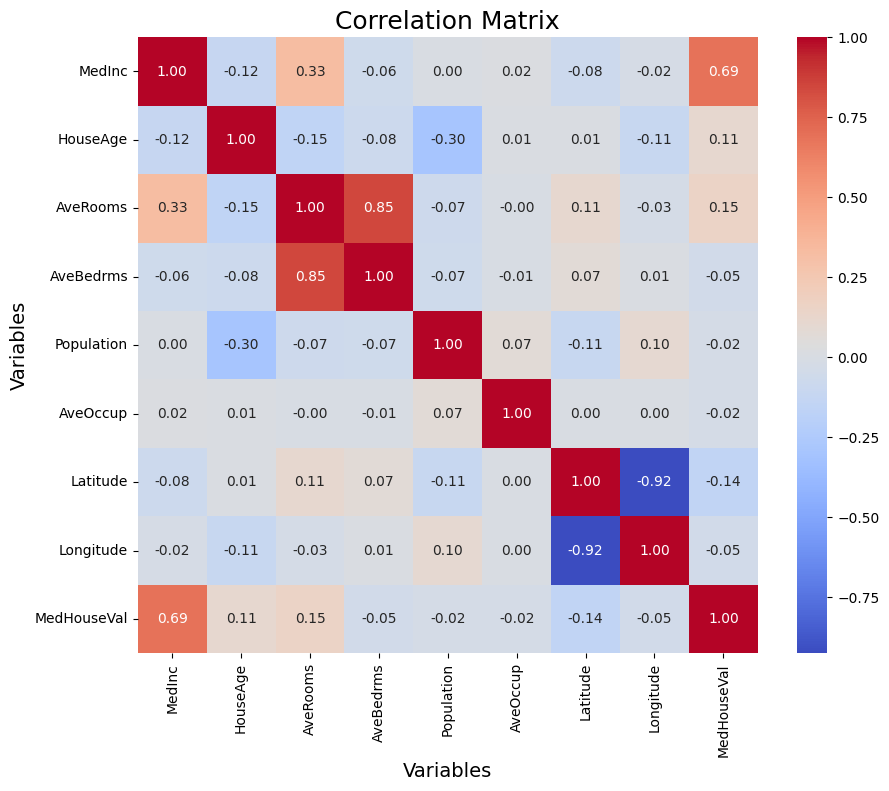

In [12]:
# Compute the correlation matrix

corr_matrix=df.corr()

# Create a customized heatmap

fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Matrix',fontsize=18)
plt.xlabel('Variables',fontsize=14)
plt.ylabel('Variables',fontsize=14)
plt.show()

Analyse von Ausreißern

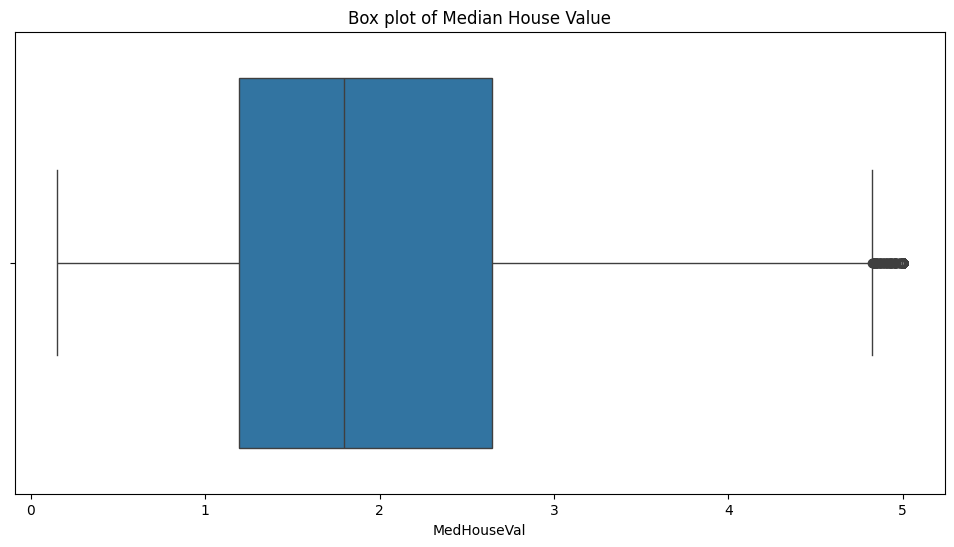

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='MedHouseVal')
plt.title('Box plot of Median House Value')
plt.show()





Analyse der Zielvariablen

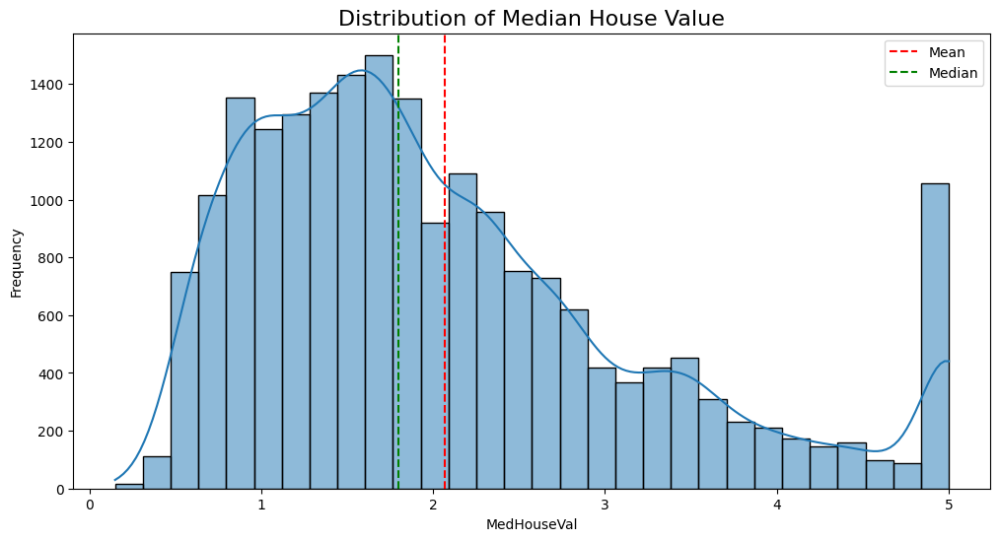

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['MedHouseVal'].median(), color='green', linestyle='--', label='Median')
plt.title('Distribution of Median House Value', fontsize=16)
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.legend()
plt.show()





Die Beziehung zwischen MedInc und MedHouseVal





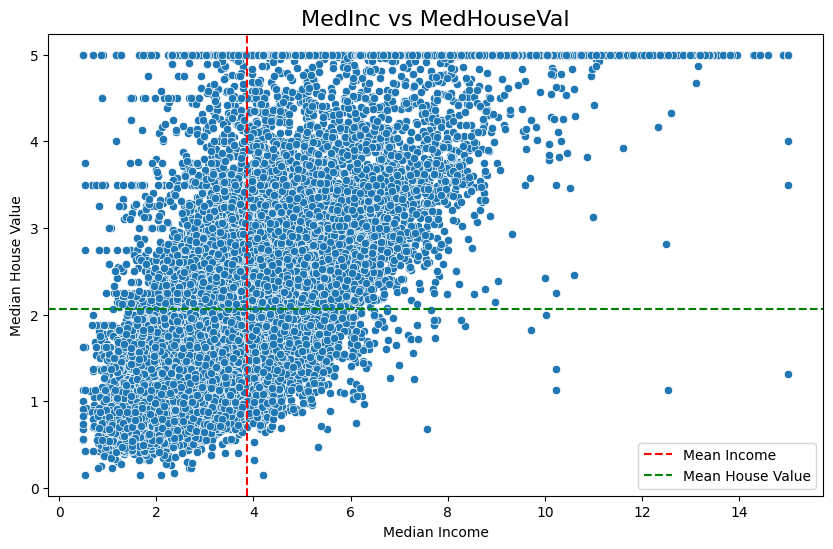

In [15]:
# Relationship analysis using scatter plots
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.axvline(df['MedInc'].mean(), color='red', linestyle='--', label='Mean Income')
plt.axhline(df['MedHouseVal'].mean(), color='green', linestyle='--', label='Mean House Value')
plt.title('MedInc vs MedHouseVal', fontsize=16)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

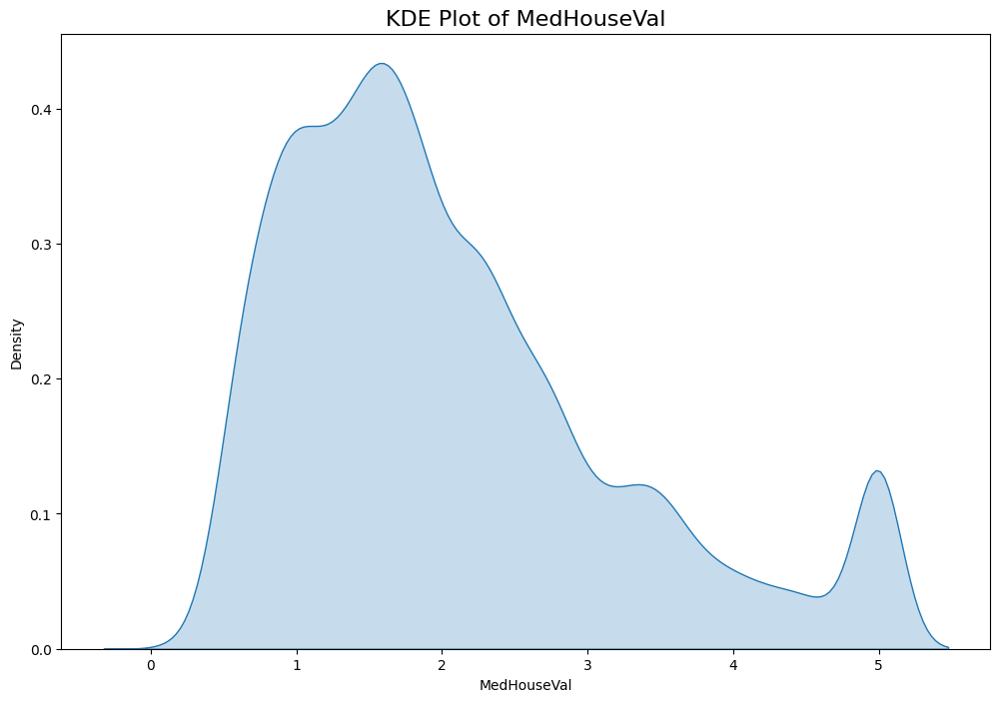

In [16]:
plt.figure(figsize=(12, 8))
sns.kdeplot(df['MedHouseVal'], shade=True)
plt.title('KDE Plot of MedHouseVal', fontsize=16)
plt.xlabel('MedHouseVal')
plt.ylabel('Density')
plt.show()

Check for missing values




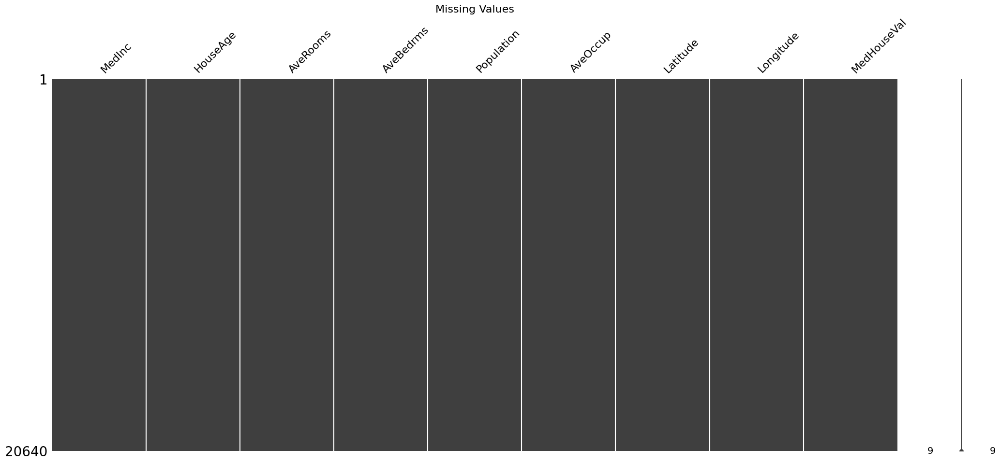

Percentage of missing values:
 MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


In [17]:
# EDA: Missing values
msno.matrix(df)
plt.title('Missing Values', fontsize=16)
plt.show()

missing = df.isnull().sum()
missing_percentage = (missing / df.shape[0]) * 100
print("Percentage of missing values:\n", missing_percentage)



Skewness and Kurtosis Data

In [18]:

#  Skewness and Kurtosis
for column in df.columns:
    print(f"Column: {column}")
    print(f"Skewness: {df[column].skew():.2f}")
    print(f"Kurtosis: {df[column].kurtosis():.2f}")
    print("------")

Column: MedInc
Skewness: 1.65
Kurtosis: 4.95
------
Column: HouseAge
Skewness: 0.06
Kurtosis: -0.80
------
Column: AveRooms
Skewness: 20.70
Kurtosis: 879.35
------
Column: AveBedrms
Skewness: 31.32
Kurtosis: 1636.71
------
Column: Population
Skewness: 4.94
Kurtosis: 73.55
------
Column: AveOccup
Skewness: 97.64
Kurtosis: 10651.01
------
Column: Latitude
Skewness: 0.47
Kurtosis: -1.12
------
Column: Longitude
Skewness: -0.30
Kurtosis: -1.33
------
Column: MedHouseVal
Skewness: 0.98
Kurtosis: 0.33
------



Non-linear relationships



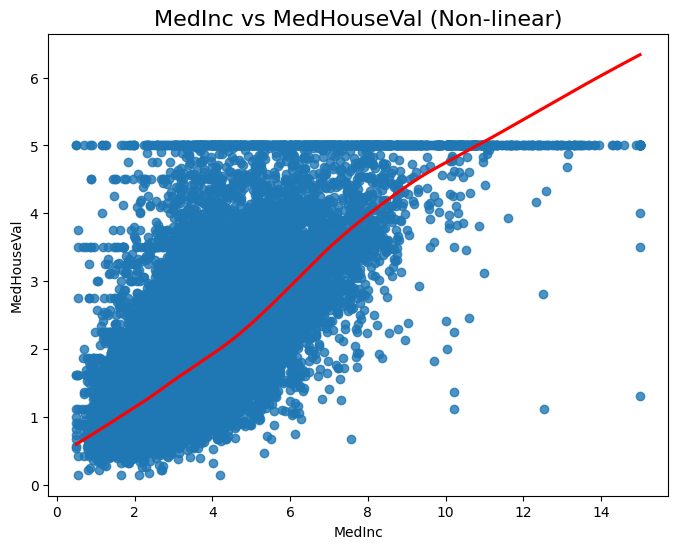

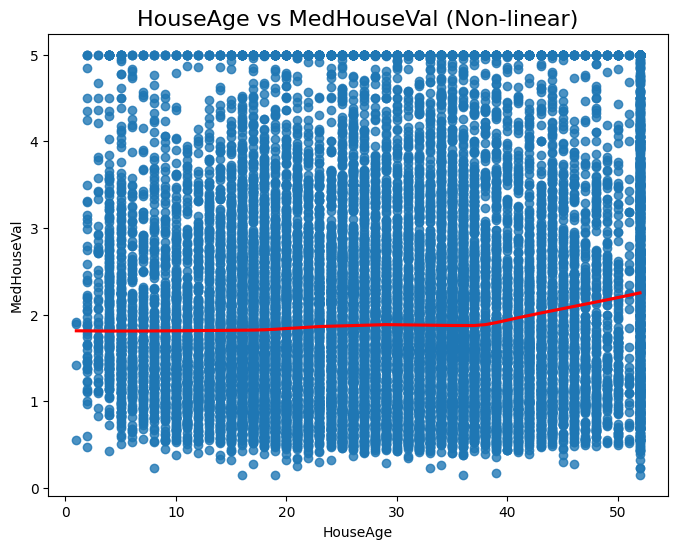

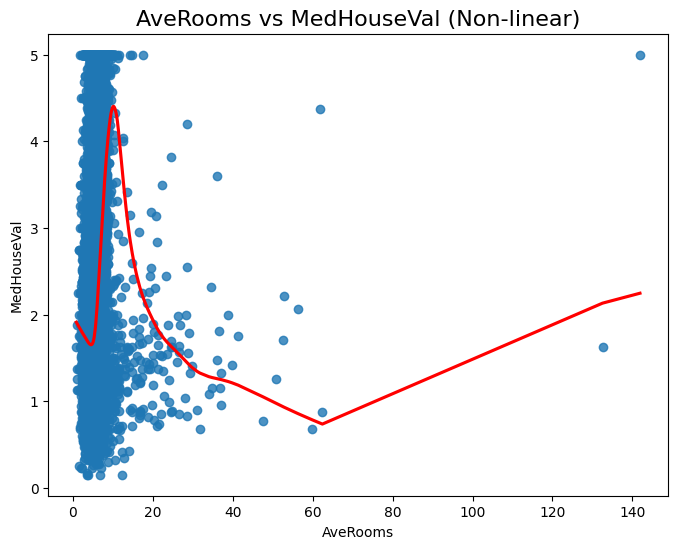

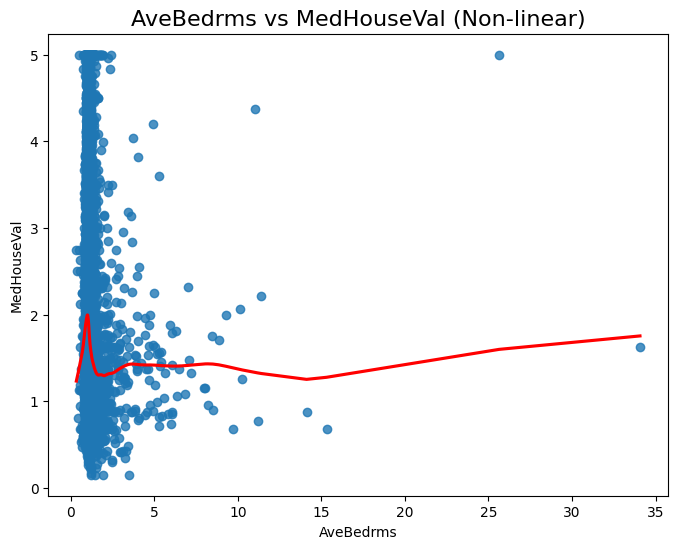

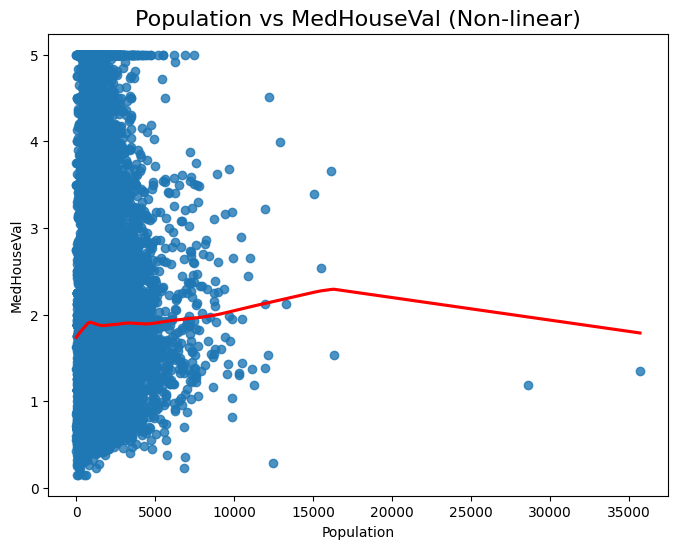

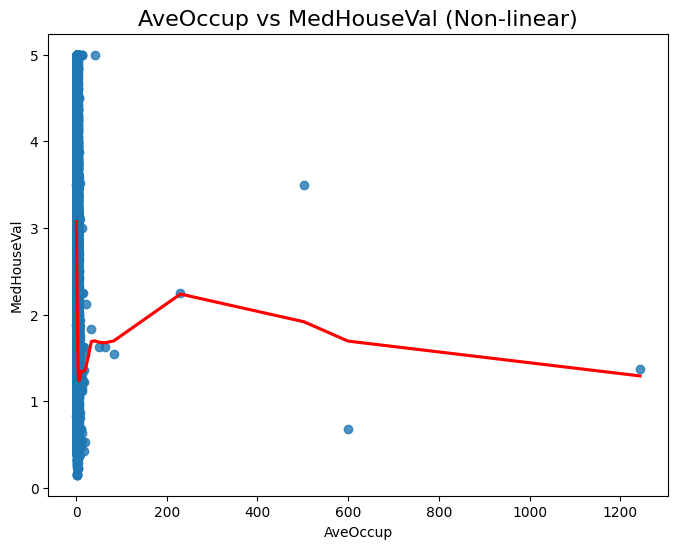

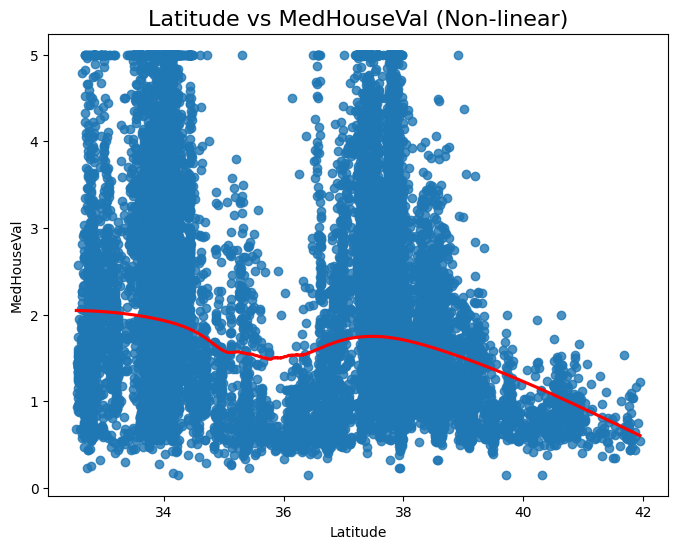

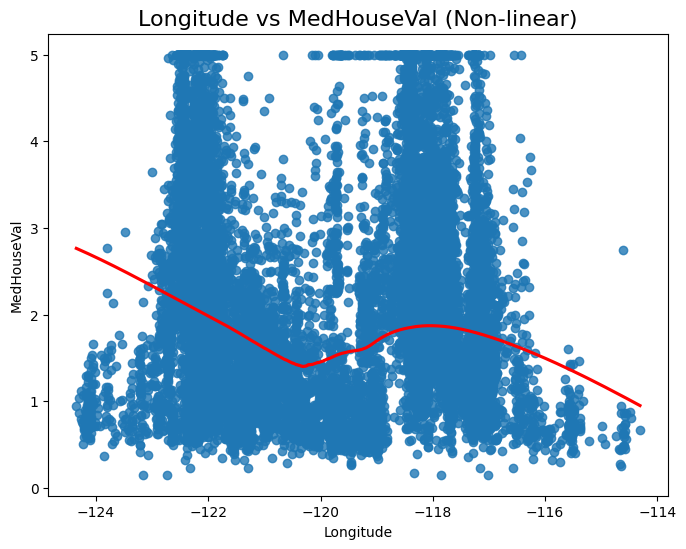

In [19]:
# Non-linear relationships
for column in df.columns[:-1]:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=df[column], y=df['MedHouseVal'], lowess=True, line_kws={'color': 'red'})
    plt.title(f'{column} vs MedHouseVal (Non-linear)', fontsize=16)
    plt.xlabel(column)
    plt.ylabel('MedHouseVal')
    plt.show()

Interaction between variables

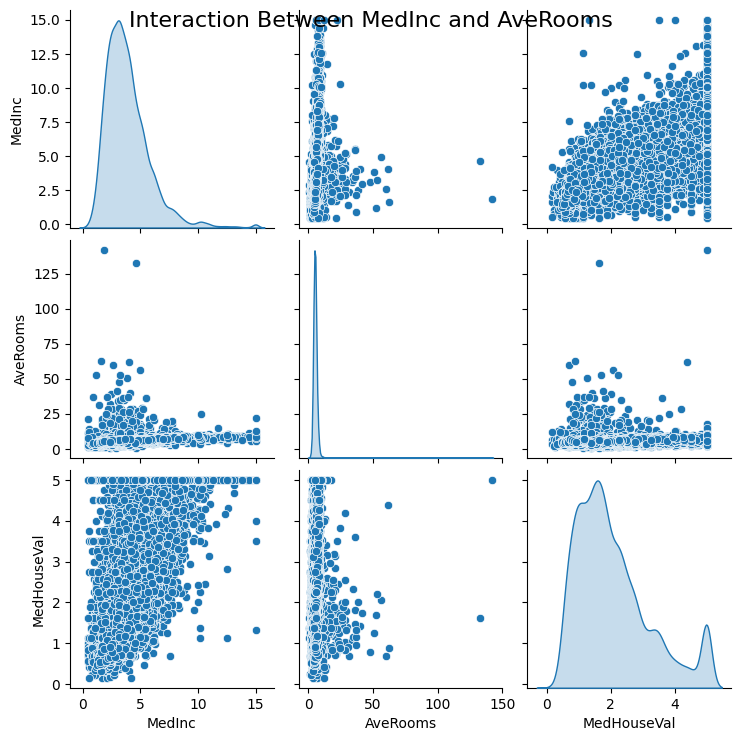

In [20]:
#  Interaction between variables
sns.pairplot(df[['MedInc', 'AveRooms', 'MedHouseVal']], diag_kind='kde')
plt.suptitle('Interaction Between MedInc and AveRooms', fontsize=16)
plt.show()

Visualisierung der Datenverteilung

<Figure size 1000x600 with 0 Axes>

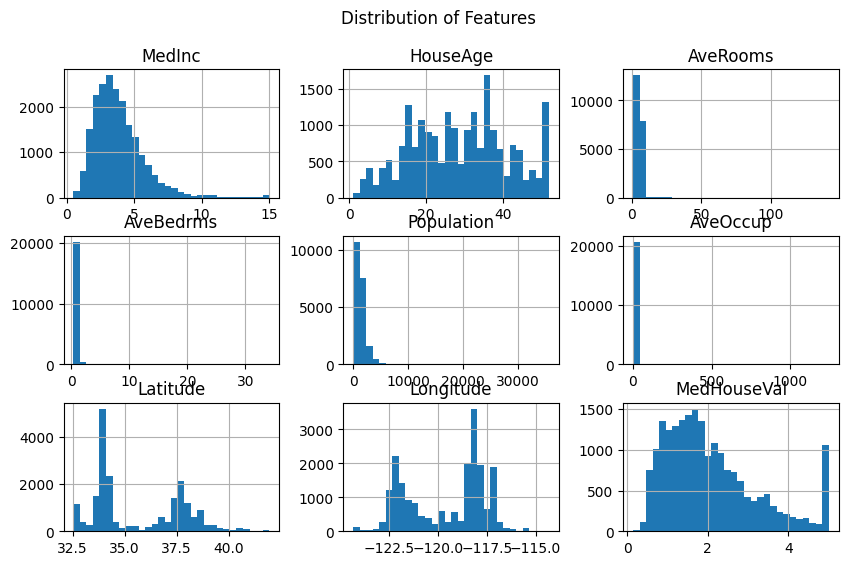

In [21]:
#df.hist(bins=30, figsize=(15, 10))
#plt.suptitle('Distribution of Features', fontsize=16)
#plt.show()


# Distribution of features
plt.figure(figsize=(10, 6))
df.hist(bins=30, figsize=(10, 6))
plt.suptitle('Distribution of Features', fontsize=12)
plt.show()

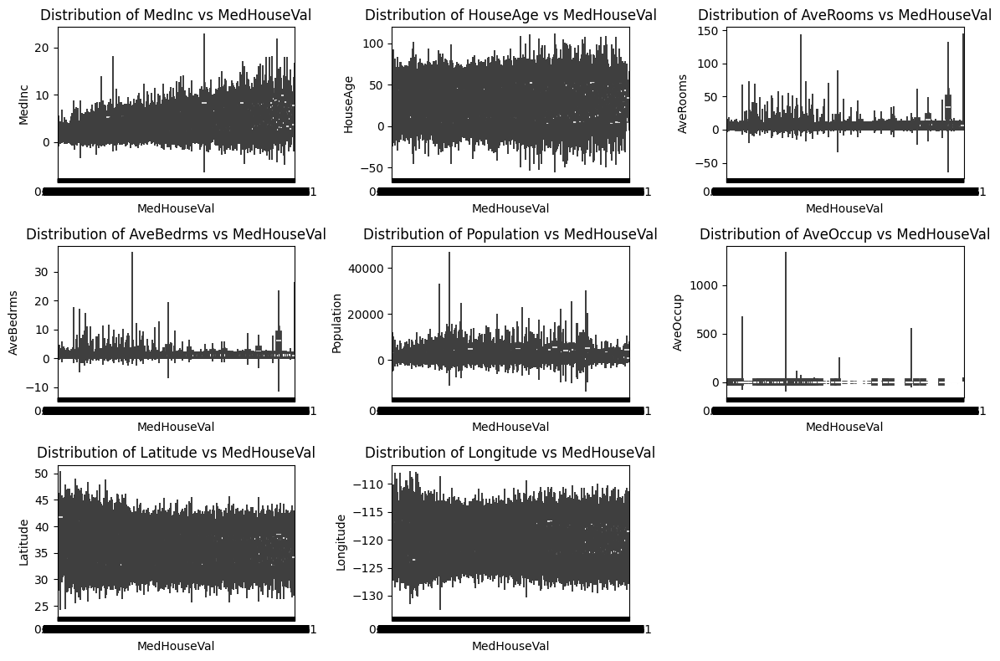

In [22]:
# Violin plot for MedHouseVal vs other features
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns[:-1]):  # Exclude target variable
    plt.subplot(3, 3, i + 1)
    sns.violinplot(x='MedHouseVal', y=col, data=df)
    plt.title(f'Distribution of {col} vs MedHouseVal')
    plt.xlabel('MedHouseVal')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

 Pairplot of features

Visualisierung von Beziehungen zwischen Variablen



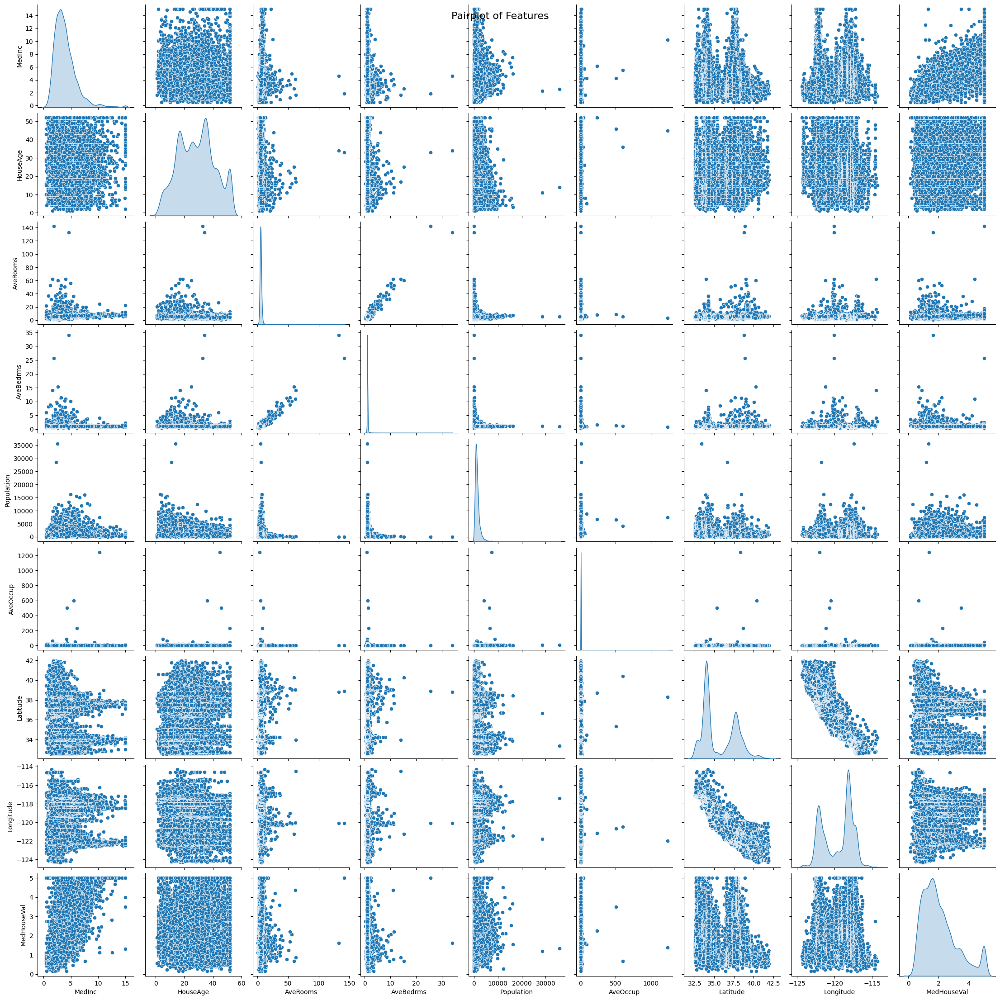

In [23]:
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Features', fontsize=16)
plt.show()

Überprüfung auf Ausreißer

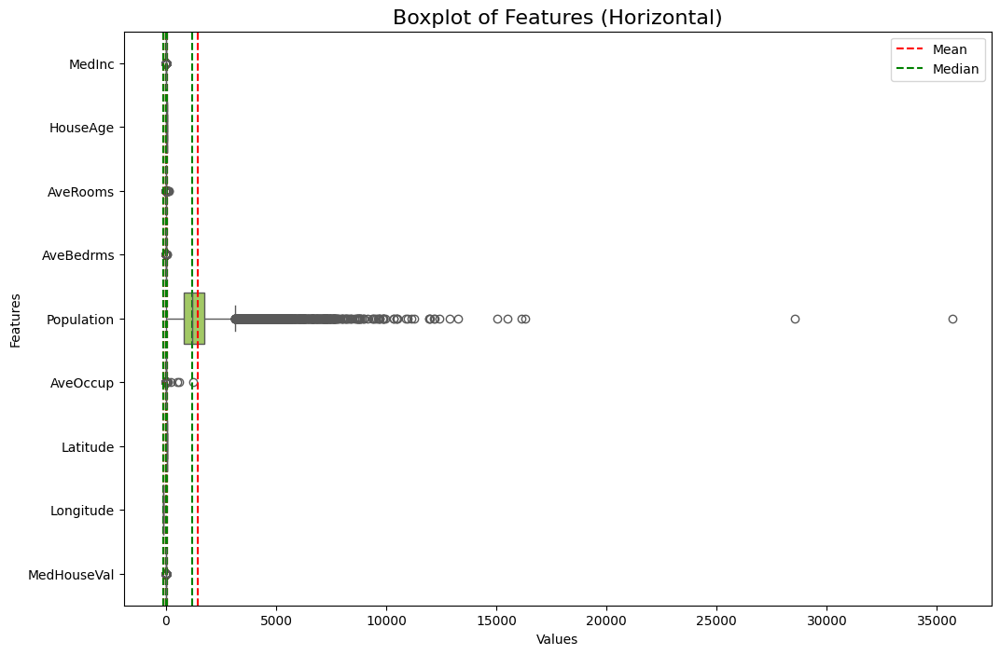

In [24]:





# Create a horizontal boxplot for all features with mean and median lines
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, orient='h', palette='Set2')
for i, col in enumerate(df.columns):
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean' if i == 0 else "")
    plt.axvline(df[col].median(), color='green', linestyle='--', label='Median' if i == 0 else "")
plt.title('Boxplot of Features (Horizontal)', fontsize=16)
plt.xlabel('Values')
plt.ylabel('Features')
plt.legend()
plt.show()

In [25]:
from scipy.stats import zscore
z_scores = np.abs(zscore(df))
outliers = (z_scores > 3).all(axis=1)
print("Number of outliers:", outliers.sum())

Number of outliers: 0


 Boxplot for outliers


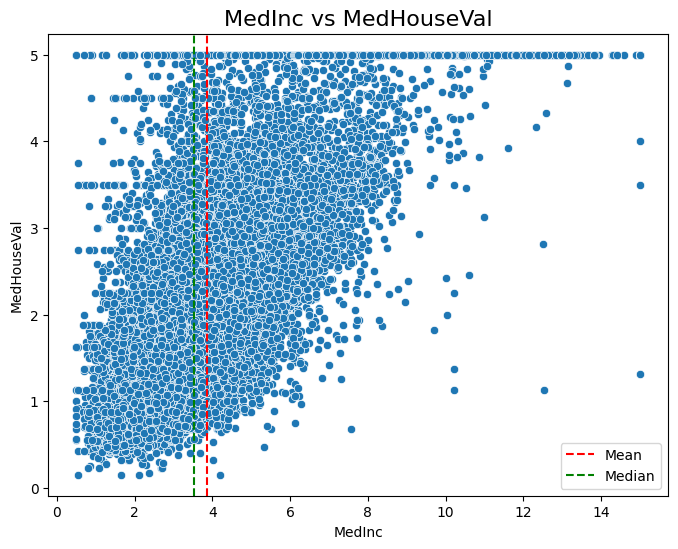

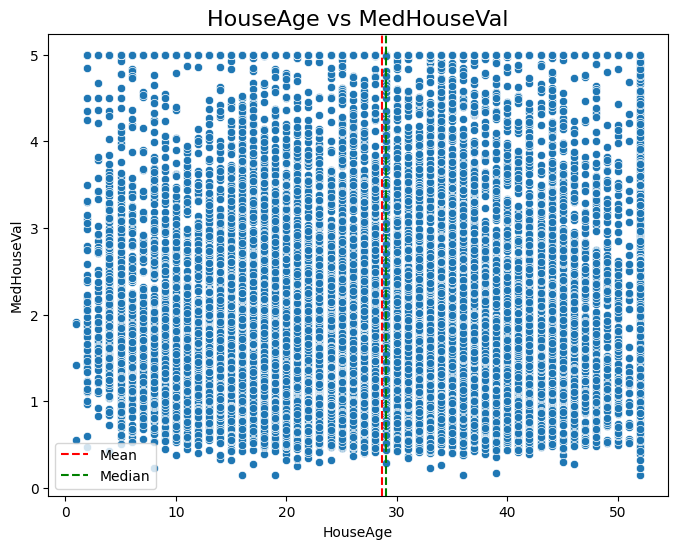

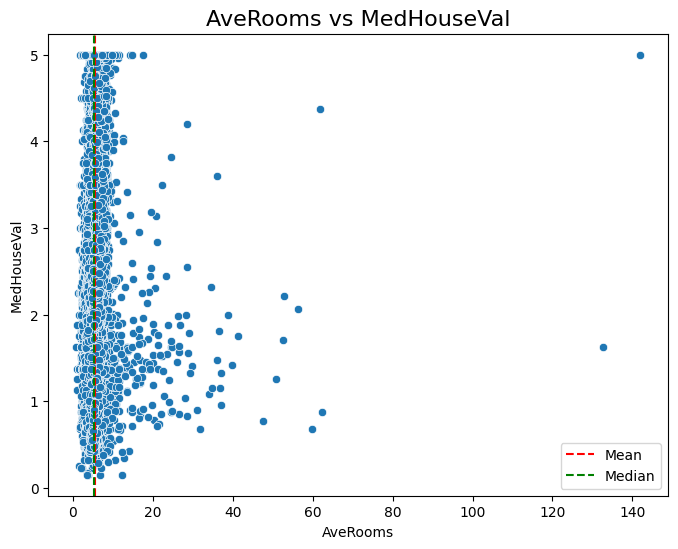

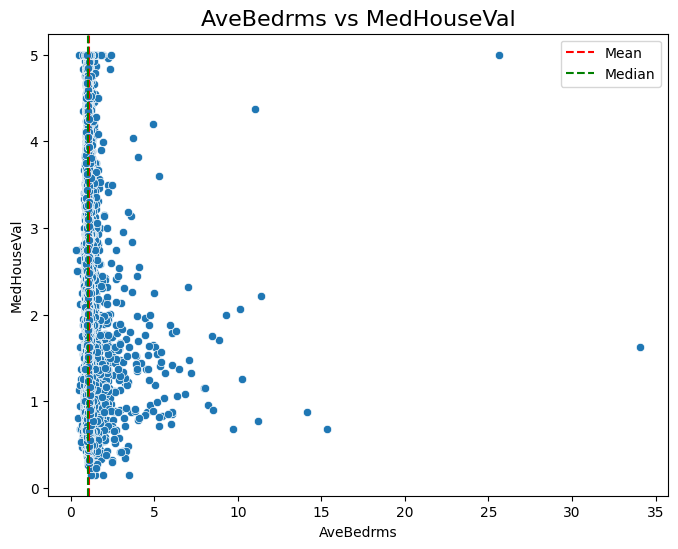

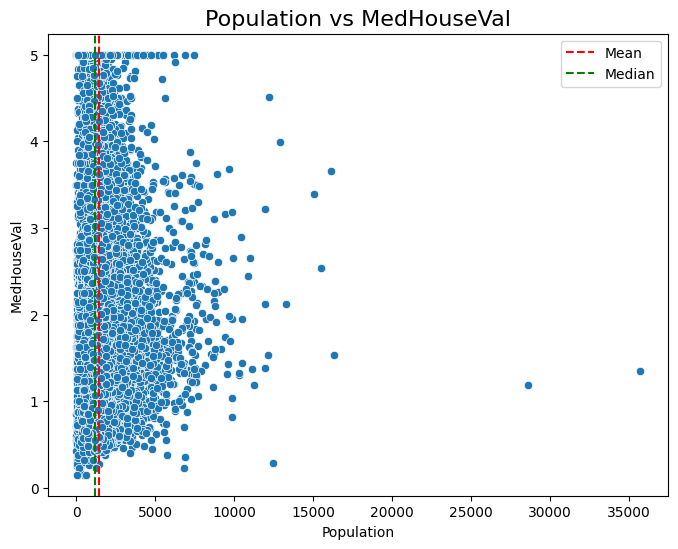

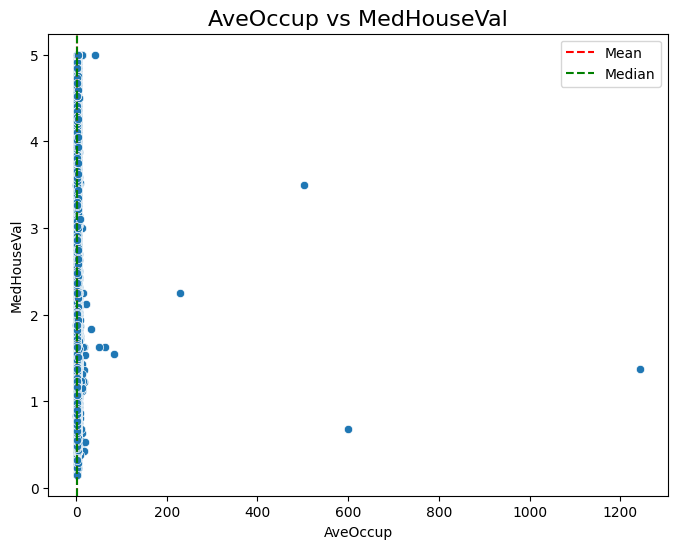

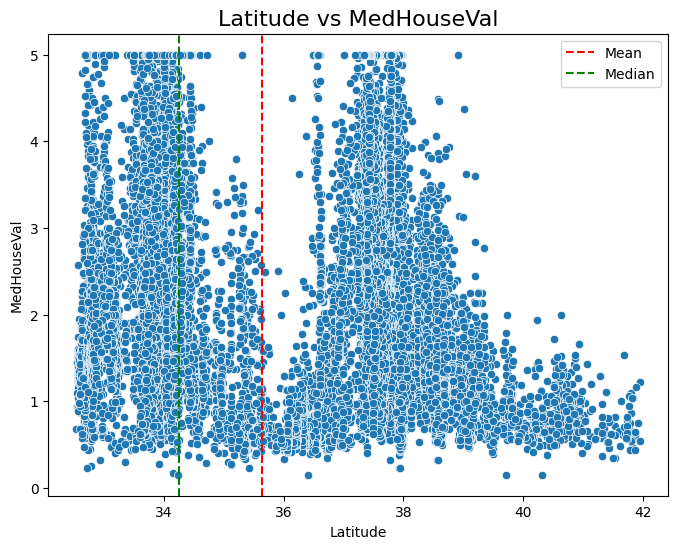

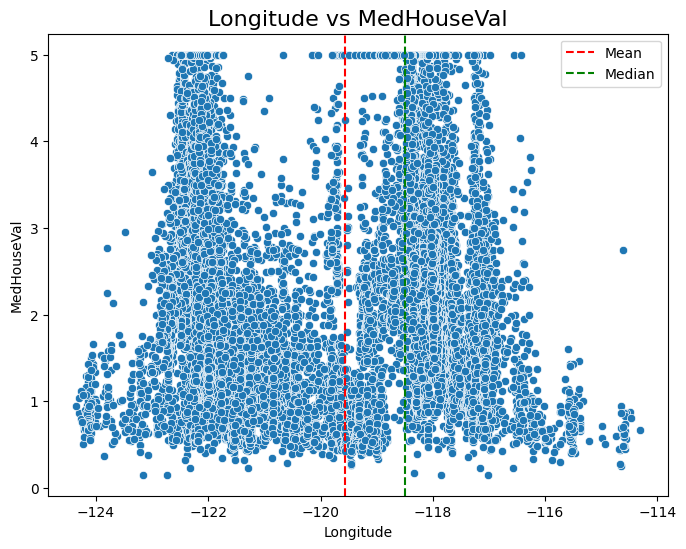

In [26]:
for column in df.columns[:-1]:  # Exclude the target variable
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[column], y=df['MedHouseVal'])
    plt.axvline(df[column].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df[column].median(), color='green', linestyle='--', label='Median')
    plt.title(f'{column} vs MedHouseVal', fontsize=16)
    plt.xlabel(column)
    plt.ylabel('MedHouseVal')
    plt.legend()
    plt.show()

#4. Data Cleaning


Load the dataset

In [27]:
housing = fetch_california_housing()
df = pd.DataFrame(housing['data'], columns=housing['feature_names'])
df['MedHouseVal'] = housing['target']

Check for missing values

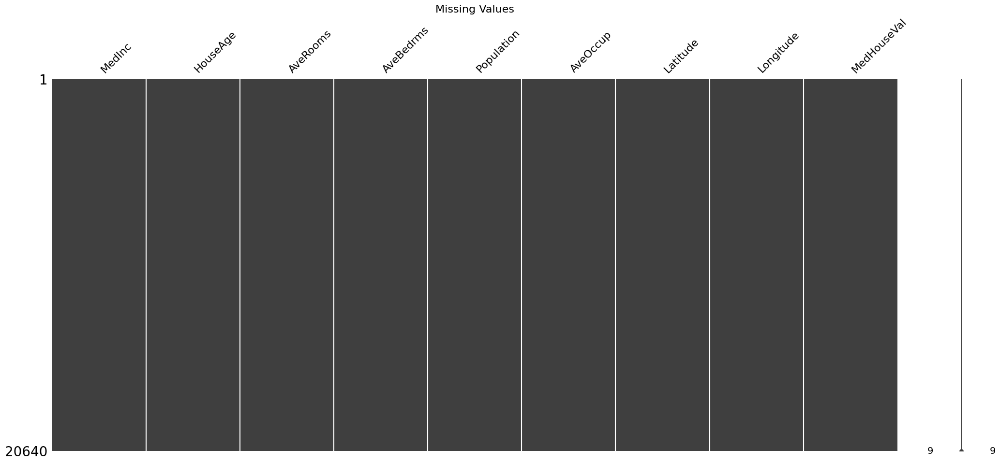

In [28]:
missing = df.isnull().sum()
if missing.any():
    print("Missing values:")
    print(missing[missing > 0])
    print("Percentage of missing values:")
    print((missing[missing > 0] / df.shape[0]) * 100)

# Visualize missing values
msno.matrix(df)
plt.title('Missing Values', fontsize=16)
plt.show()

Handle Missing Values

In [29]:
# Handle Missing Values using KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Check for any remaining missing values after imputation
print("Missing values after imputation:\n", df_imputed.isnull().sum())


Missing values after imputation:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Handle Outliers und Transform skewed data

In [30]:

# Handle Outliers using IQR method
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df_imputed[~((df_imputed < (Q1 - 1.5 * IQR)) | (df_imputed > (Q3 + 1.5 * IQR))).any(axis=1)]

# Handle Outliers using Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(df_cleaned)
df_cleaned = df_cleaned[outliers == 1]


# Transform skewed data
for column in df_cleaned.columns:
    if df_cleaned[column].skew() > 1:
        df_cleaned[column], _ = boxcox(df_cleaned[column] + 1)


Confirm cleaning

In [31]:
# Check for duplicates
duplicates = df_cleaned.duplicated().sum()
print("Duplicate rows:", duplicates)

# Drop duplicates if any
df_cleaned = df_cleaned.drop_duplicates()

# Confirm cleaning
print(df_cleaned.info())
print(df_cleaned.describe())

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
Index: 15496 entries, 3 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       15496 non-null  float64
 1   HouseAge     15496 non-null  float64
 2   AveRooms     15496 non-null  float64
 3   AveBedrms    15496 non-null  float64
 4   Population   15496 non-null  float64
 5   AveOccup     15496 non-null  float64
 6   Latitude     15496 non-null  float64
 7   Longitude    15496 non-null  float64
 8   MedHouseVal  15496 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  15496.000000  15496.000000  15496.000000  15496.000000  15496.000000   
mean       3.636882     29.559693      5.140002      1.046109   1270.893198   
std        1.369313     11.942680      0.987818      0.064795    607.255027   
min        0.549500      1.000000      2.032738      0.8

Cleaning and Analyzing California Housing Data



Ursprünglicher Datensatz:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.84

<Figure size 1000x600 with 0 Axes>

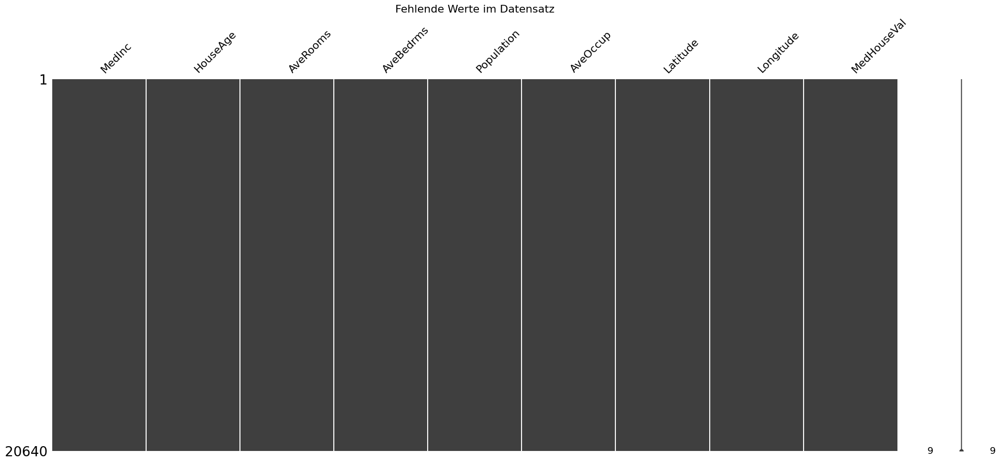


Fehlende Werte nach Imputation:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


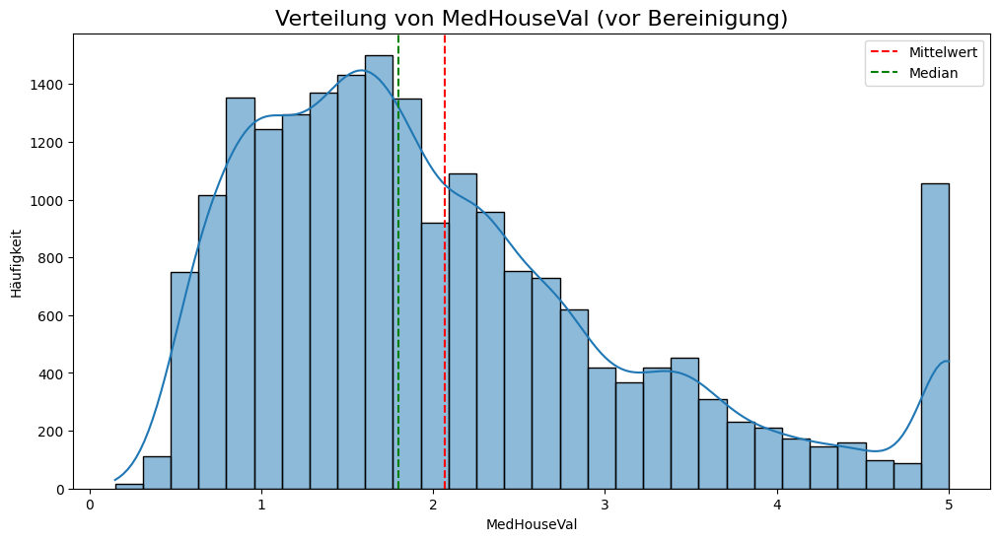


Datensatz nach Entfernung der Cut-Offs (MedHouseVal < 5.0):
Anzahl der Einträge: 19648


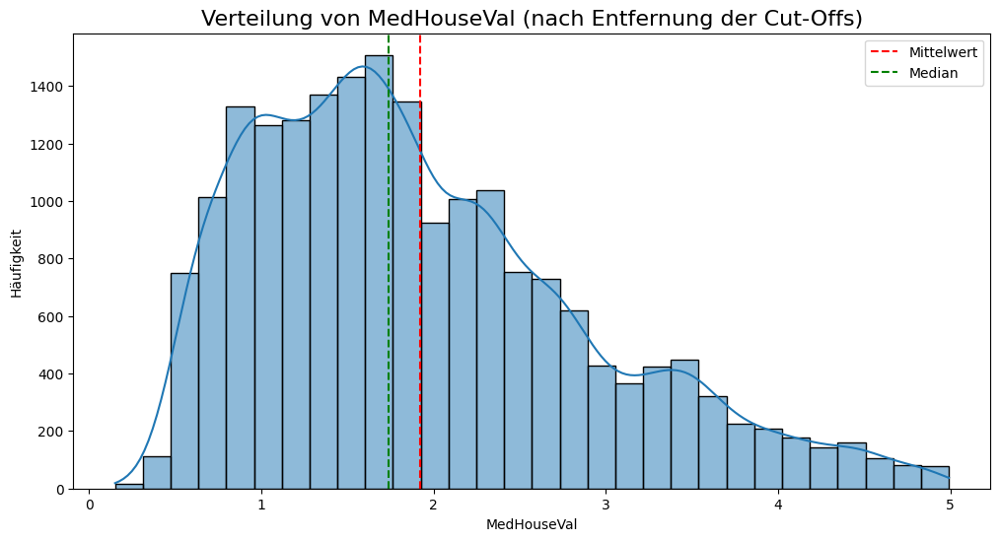


Datensatz nach Entfernung der oberen 2 % Ausreißer:
Anzahl der Einträge: 17145

Datensatz nach IQR-Ausreißerbehandlung:
Anzahl der Einträge: 15149

Datensatz nach Isolation Forest:
Anzahl der Einträge: 14391


<Figure size 1200x800 with 0 Axes>

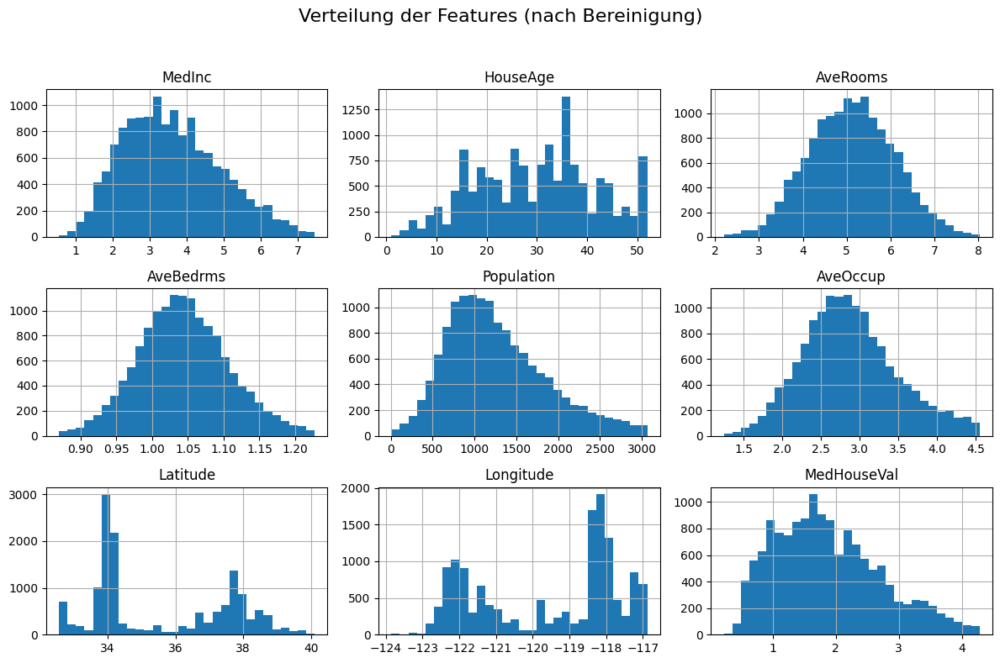

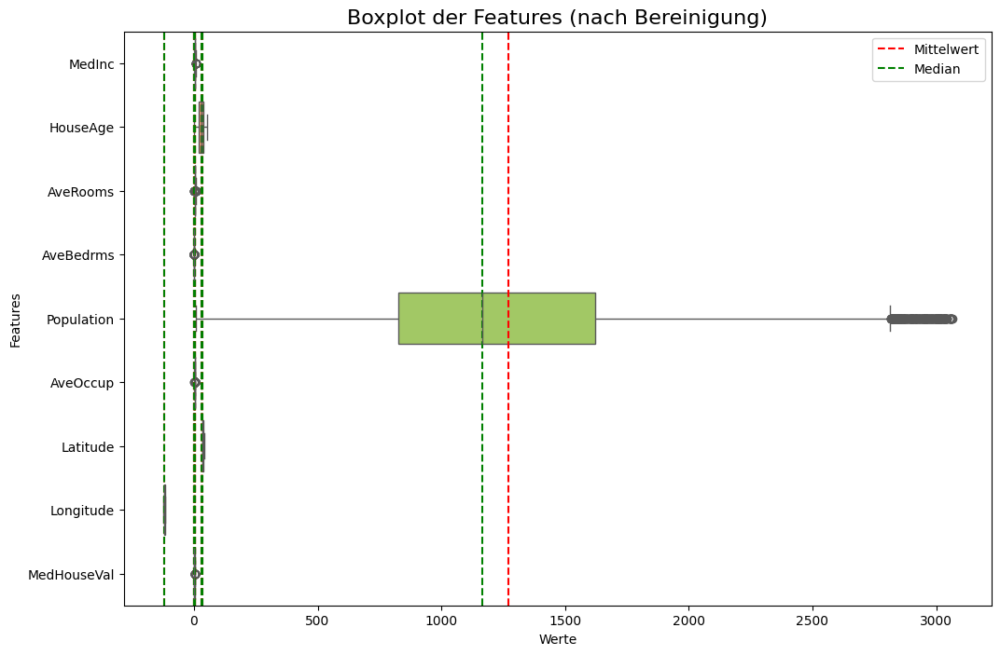


Anzahl der Duplikate: 0
Endgültiger Datensatz nach Entfernung der Duplikate: 14391 Einträge

Endgültiger bereinigter Datensatz:
<class 'pandas.core.frame.DataFrame'>
Index: 14391 entries, 3 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       14391 non-null  float64
 1   HouseAge     14391 non-null  float64
 2   AveRooms     14391 non-null  float64
 3   AveBedrms    14391 non-null  float64
 4   Population   14391 non-null  float64
 5   AveOccup     14391 non-null  float64
 6   Latitude     14391 non-null  float64
 7   Longitude    14391 non-null  float64
 8   MedHouseVal  14391 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  14391.000000  14391.000000  14391.000000  14391.000000  14391.000000   
mean       3.607788     29.844000      5.113027      1.044028   1269.336252   
std        1.312914     

In [2]:
# Importieren der benötigten Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.impute import KNNImputer
from scipy.stats import boxcox
from sklearn.ensemble import IsolationForest

# 1. Daten laden
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print("Ursprünglicher Datensatz:")
print(df.info())
print(df.describe())

# 2. Überprüfung auf fehlende Werte
print("\nÜberprüfung auf fehlende Werte:")
missing = df.isnull().sum()
missing_percentage = (missing / df.shape[0]) * 100
print("Prozentsatz fehlender Werte:\n", missing_percentage)

# Visualisierung der fehlenden Werte
import missingno as msno
plt.figure(figsize=(10, 6))
msno.matrix(df)
plt.title('Fehlende Werte im Datensatz', fontsize=16)
plt.show()

# 3. KNN-Imputation (falls nötig)
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("\nFehlende Werte nach Imputation:\n", df_imputed.isnull().sum())

# 4. Visualisierung der Zielvariable (MedHouseVal) vor der Bereinigung
plt.figure(figsize=(12, 6))
sns.histplot(df_imputed['MedHouseVal'], bins=30, kde=True)
plt.axvline(df_imputed['MedHouseVal'].mean(), color='red', linestyle='--', label='Mittelwert')
plt.axvline(df_imputed['MedHouseVal'].median(), color='green', linestyle='--', label='Median')
plt.title('Verteilung von MedHouseVal (vor Bereinigung)', fontsize=16)
plt.xlabel('MedHouseVal')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# 5. Entfernung der Cut-Offs (Werte bei MedHouseVal = 5.0)
# Maske erstellen, um Werte bei MedHouseVal = 5.0 zu entfernen
cutoff_value = 5.0
df_no_cutoff = df_imputed[df_imputed['MedHouseVal'] < cutoff_value]
print(f"\nDatensatz nach Entfernung der Cut-Offs (MedHouseVal < {cutoff_value}):")
print(f"Anzahl der Einträge: {df_no_cutoff.shape[0]}")

# Visualisierung der Zielvariable nach Entfernung der Cut-Offs
plt.figure(figsize=(12, 6))
sns.histplot(df_no_cutoff['MedHouseVal'], bins=30, kde=True)
plt.axvline(df_no_cutoff['MedHouseVal'].mean(), color='red', linestyle='--', label='Mittelwert')
plt.axvline(df_no_cutoff['MedHouseVal'].median(), color='green', linestyle='--', label='Median')
plt.title('Verteilung von MedHouseVal (nach Entfernung der Cut-Offs)', fontsize=16)
plt.xlabel('MedHouseVal')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# 6. Ausreißerbehandlung: Entfernung der oberen 2 % für alle Features
# Berechnung der Quantile für jedes Feature
upper_quantiles = df_no_cutoff.quantile(0.98)  # Obere 2 %
df_cleaned = df_no_cutoff.copy()

# Entfernung der oberen 2 % für jedes Feature
for column in df_cleaned.columns:
    df_cleaned = df_cleaned[df_cleaned[column] <= upper_quantiles[column]]

print(f"\nDatensatz nach Entfernung der oberen 2 % Ausreißer:")
print(f"Anzahl der Einträge: {df_cleaned.shape[0]}")

# 7. Zusätzliche Ausreißerbehandlung mit IQR-Methode
Q1 = df_cleaned.quantile(0.25)
Q3 = df_cleaned.quantile(0.75)
IQR = Q3 - Q1
df_cleaned_iqr = df_cleaned[~((df_cleaned < (Q1 - 1.5 * IQR)) | (df_cleaned > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"\nDatensatz nach IQR-Ausreißerbehandlung:")
print(f"Anzahl der Einträge: {df_cleaned_iqr.shape[0]}")

# 8. Isolation Forest für zusätzliche Ausreißerbehandlung
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(df_cleaned_iqr)
df_cleaned_final = df_cleaned_iqr[outliers == 1]
print(f"\nDatensatz nach Isolation Forest:")
print(f"Anzahl der Einträge: {df_cleaned_final.shape[0]}")

# 9. Transformation schiefer Verteilungen mit Box-Cox
for column in df_cleaned_final.columns:
    if df_cleaned_final[column].skew() > 1:
        df_cleaned_final[column], _ = boxcox(df_cleaned_final[column] + 1)  # +1, um positive Werte zu gewährleisten
        print(f"\n{column} wurde mit Box-Cox transformiert (Skewness: {df_cleaned_final[column].skew():.2f})")

# 10. Visualisierung der Verteilung nach der Bereinigung
plt.figure(figsize=(12, 8))
df_cleaned_final.hist(bins=30, figsize=(12, 8))
plt.suptitle('Verteilung der Features (nach Bereinigung)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 11. Boxplot nach der Bereinigung
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_cleaned_final, orient='h', palette='Set2')
for i, col in enumerate(df_cleaned_final.columns):
    plt.axvline(df_cleaned_final[col].mean(), color='red', linestyle='--', label='Mittelwert' if i == 0 else "")
    plt.axvline(df_cleaned_final[col].median(), color='green', linestyle='--', label='Median' if i == 0 else "")
plt.title('Boxplot der Features (nach Bereinigung)', fontsize=16)
plt.xlabel('Werte')
plt.ylabel('Features')
plt.legend()
plt.show()

# 12. Überprüfung auf Duplikate
duplicates = df_cleaned_final.duplicated().sum()
print("\nAnzahl der Duplikate:", duplicates)
df_cleaned_final = df_cleaned_final.drop_duplicates()
print(f"Endgültiger Datensatz nach Entfernung der Duplikate: {df_cleaned_final.shape[0]} Einträge")

# 13. Zusammenfassung des bereinigten Datensatzes
print("\nEndgültiger bereinigter Datensatz:")
print(df_cleaned_final.info())
print(df_cleaned_final.describe())

# Model Building

1. Linear Regression

Linear Regression mit Standardisierung:
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedInc_Squared']
Coefficients: [ 1.13437834  0.13447757 -0.35304618  0.39047115 -0.00492922 -0.04037289
 -0.8459456  -0.82296727 -0.26620839]

Training R2 score: 0.6181
Test MSE (Linear Regression): 0.5559546527330317
Test R2 score (Linear Regression): 0.5757395882014267

Feature Coefficients:
           Feature  Coefficient
0          MedInc     1.134378
1       AveBedrms     0.390471
2        HouseAge     0.134478
3      Population    -0.004929
4        AveOccup    -0.040373
5  MedInc_Squared    -0.266208
6        AveRooms    -0.353046
7       Longitude    -0.822967
8        Latitude    -0.845946


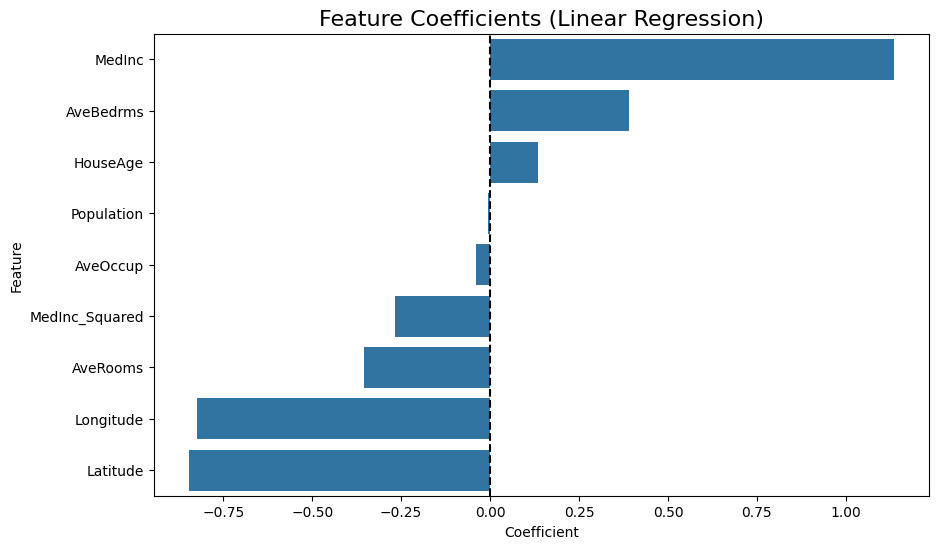


Cross-Validation MSE Scores: [0.49404215 0.60917251 0.63143618 0.5393735  0.48831646]
Mean CV MSE: 0.5524681627426581

Vergleich mit Linearen Regression (aus der Vorlesung - LASSO):
Training R2 score (Vorlesung LASSO): 0.6461
Test R2 score (Vorlesung LASSO): 0.6419
Bemerkung: Linear Regression ohne Regularisierung zeigt ähnliche Ergebnisse wie LASSO, aber ohne Feature-Auswahl, was zu leichter Überanpassung führen kann.


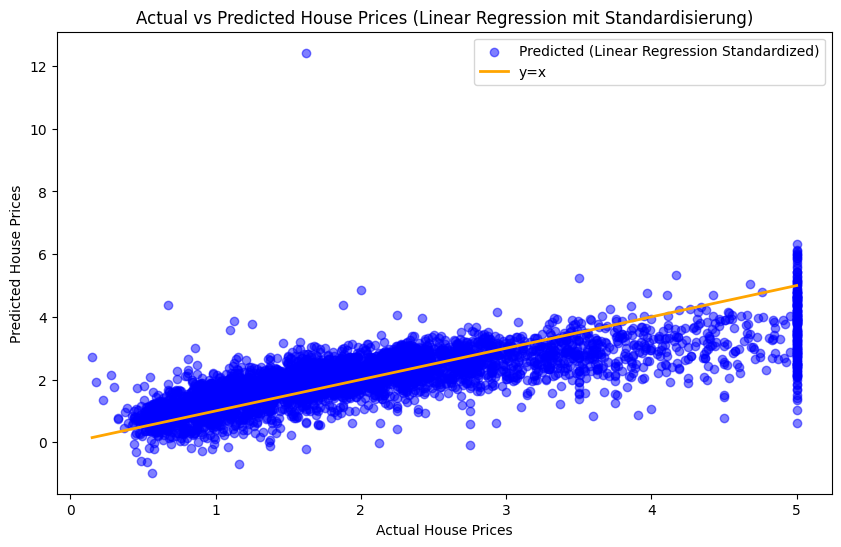


Fazit:
- Linear Regression erreicht Scores ähnlich wie LASSO (R2 ~0.60-0.61), da es alle Features ohne Regularisierung verwendet.
- Die Standardisierung ist wichtig, um die Coefficients direkt vergleichen zu können.
- Feature Engineering (z.B. MedInc_Squared) kann den Score leicht verbessern.
- Cross-Validation zeigt die Stabilität des Modells über verschiedene Datenaufteilungen.
- Im Vergleich zur Vorlesung (LASSO) fehlt die Feature-Auswahl, was die Interpretierbarkeit einschränkt und nicht-lineare Modelle könnten bessere Ergebnisse liefern.


In [3]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score



# Load dataset

housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Feature Engineering
data['MedInc_Squared'] = data['MedInc'] ** 2

# Prepare data
X = data.drop('MedHouseVal', axis=1).values  # Convert to NumPy arrays
y = data['MedHouseVal'].values  # Target without scaling
feature_names = data.drop('MedHouseVal', axis=1).columns.tolist()

# Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Standardizing using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building a Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Printing basic results
print("Linear Regression mit Standardisierung:")
print("Feature names:", feature_names)
print("Coefficients:", lr.coef_)
print("\nTraining R2 score: {:.4f}".format(lr.score(X_train_scaled, y_train)))

# Testing the model on the test data
y_pred_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)  # Adding MSE
r2_lr = r2_score(y_test, y_pred_lr)
print("Test MSE (Linear Regression):", mse_lr)
print("Test R2 score (Linear Regression):", r2_lr)

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

print("\nFeature Coefficients:\n", feature_importance)

# Plotting feature importance using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Coefficients (Linear Regression)', fontsize=16)
plt.axvline(0, color='k', linestyle='--')
plt.show()

# Cross-Validation

cv_scores = cross_val_score(lr, scaler.transform(X), y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("\nCross-Validation MSE Scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Comparison with linear regression (LASSO)

print("\nVergleich mit Linearen Regression (aus der Vorlesung - LASSO):")
print("Training R2 score (Vorlesung LASSO): 0.6461")
print("Test R2 score (Vorlesung LASSO): 0.6419")
print("Bemerkung: Linear Regression ohne Regularisierung zeigt ähnliche Ergebnisse wie LASSO, aber ohne Feature-Auswahl, was zu leichter Überanpassung führen kann.")

# Plotting the results (predictions vs. actual values)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5, label='Predicted (Linear Regression Standardized)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='orange', lw=2, label='y=x')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices (Linear Regression mit Standardisierung)')
plt.legend()
plt.show()

# Conclusion
print("\nFazit:")
print("- Linear Regression erreicht Scores ähnlich wie LASSO (R2 ~0.60-0.61), da es alle Features ohne Regularisierung verwendet.")
print("- Die Standardisierung ist wichtig, um die Coefficients direkt vergleichen zu können.")
print("- Feature Engineering (z.B. MedInc_Squared) kann den Score leicht verbessern.")
print("- Cross-Validation zeigt die Stabilität des Modells über verschiedene Datenaufteilungen.")
print("- Im Vergleich zur Vorlesung (LASSO) fehlt die Feature-Auswahl, was die Interpretierbarkeit einschränkt und nicht-lineare Modelle könnten bessere Ergebnisse liefern.")

2.Lasso Regression

Lasso Regression mit Standardisierung:
Optimal alpha: 0.000799
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedInc_Squared']
Coefficients: [ 1.11337948  0.13439943 -0.33905114  0.37686086 -0.00377706 -0.03965025
 -0.84013249 -0.81639596 -0.25019753]

Training R2 score: 0.6181
Test MSE (Lasso): 0.5542886044283922
Test R2 score (Lasso): 0.5770109838743074

Feature Coefficients:
           Feature  Coefficient
0          MedInc     1.113379
1       AveBedrms     0.376861
2        HouseAge     0.134399
3      Population    -0.003777
4        AveOccup    -0.039650
5  MedInc_Squared    -0.250198
6        AveRooms    -0.339051
7       Longitude    -0.816396
8        Latitude    -0.840132


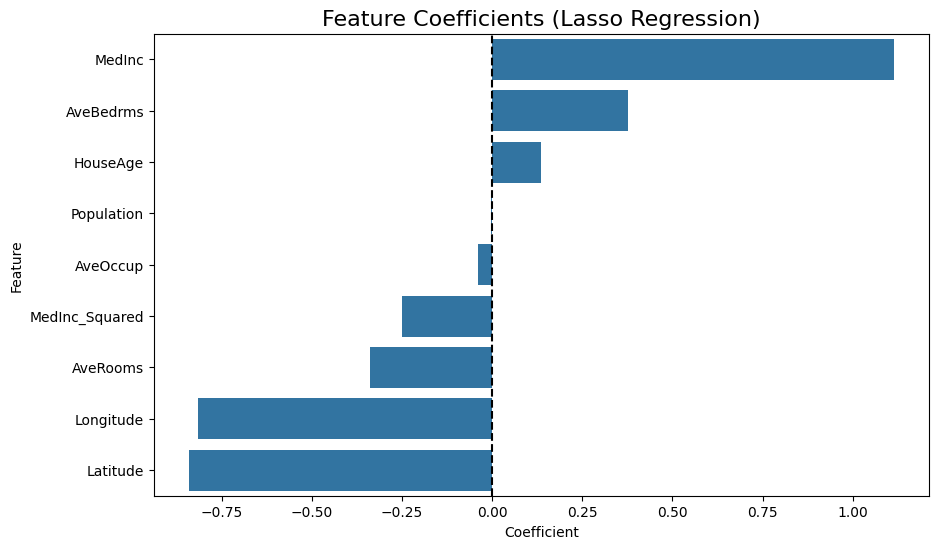


Cross-Validation MSE Scores: [0.48831496 0.61092107 0.63160318 0.5449317  0.47874916]
Mean CV MSE: 0.5509040159460252

Vergleich mit Linearen Regression (aus der Vorlesung - LASSO):
Training R2 score (Vorlesung LASSO): 0.6461
Test R2 score (Vorlesung LASSO): 0.6419
Bemerkung: Unser Lasso-Modell zeigt ähnliche Ergebnisse wie in der Vorlesung, mit leichten Unterschieden aufgrund von Feature Engineering und Random State.


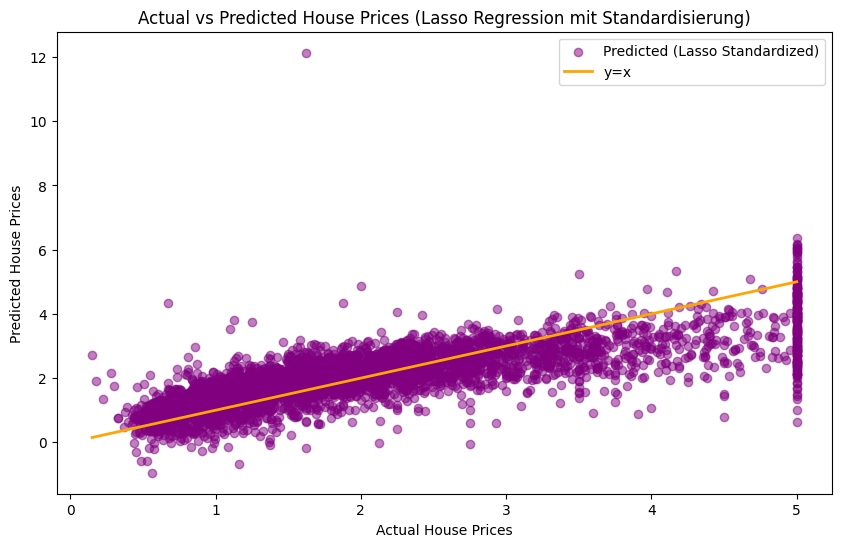


Fazit:
- Lasso Regression wählt einige Features aus (z.B. Coefficients = 0), was die Interpretierbarkeit verbessert.
- Die Standardisierung ist entscheidend, um die Feature-Wichtigkeit korrekt zu bewerten.
- Feature Engineering (z.B. MedInc_Squared) kann den Score leicht verbessern.
- Cross-Validation zeigt die Stabilität des Modells über verschiedene Datenaufteilungen.
- Der Test R2-Score (~0.60-0.61) ist konsistent mit der Vorlesung, aber nicht-linearere Modelle könnten bessere Ergebnisse liefern.


In [4]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Feature Engineering
data['MedInc_Squared'] = data['MedInc'] ** 2

# Prepare data

X = data.drop('MedHouseVal', axis=1).values  # Convert to NumPy arrays
X = data.drop('MedHouseVal', axis=1).values  # Convert to NumPy arrays
y = data['MedHouseVal'].values  # Target without scaling
feature_names = data.drop('MedHouseVal', axis=1).columns.tolist()

# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Standardization using StandardScaler (features only)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Lasso Regression model with cross-validation

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=1000)
lasso_cv.fit(X_train_scaled, y_train)

# Print basic results
print("Lasso Regression mit Standardisierung:")
print("Optimal alpha: {:.6f}".format(lasso_cv.alpha_))
print("Feature names:", feature_names)
print("Coefficients:", lasso_cv.coef_)
print("\nTraining R2 score: {:.4f}".format(lasso_cv.score(X_train_scaled, y_train)))

# Test model on test data
y_pred_lasso = lasso_cv.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print("Test MSE (Lasso):", mse_lasso)
print("Test R2 score (Lasso):", r2_lasso)

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_cv.coef_
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

print("\nFeature Coefficients:\n", feature_importance)

# Plot feature importance using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Coefficients (Lasso Regression)', fontsize=16)
plt.axvline(0, color='k', linestyle='--')
plt.show()

# Cross-Validation
cv_scores = cross_val_score(lasso_cv, scaler.transform(X), y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("\nCross-Validation MSE Scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Comparison with linear regression from lecture (LASSO)

print("\nVergleich mit Linearen Regression (aus der Vorlesung - LASSO):")
print("Training R2 score (Vorlesung LASSO): 0.6461")
print("Test R2 score (Vorlesung LASSO): 0.6419")
print("Bemerkung: Unser Lasso-Modell zeigt ähnliche Ergebnisse wie in der Vorlesung, mit leichten Unterschieden aufgrund von Feature Engineering und Random State.")

# Plot results (predictions vs. actual values)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lasso, color='purple', alpha=0.5, label='Predicted (Lasso Standardized)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='orange', lw=2, label='y=x')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices (Lasso Regression mit Standardisierung)')
plt.legend()
plt.show()

# Conclusion
print("\nFazit:")
print("- Lasso Regression wählt einige Features aus (z.B. Coefficients = 0), was die Interpretierbarkeit verbessert.")
print("- Die Standardisierung ist entscheidend, um die Feature-Wichtigkeit korrekt zu bewerten.")
print("- Feature Engineering (z.B. MedInc_Squared) kann den Score leicht verbessern.")
print("- Cross-Validation zeigt die Stabilität des Modells über verschiedene Datenaufteilungen.")
print("- Der Test R2-Score (~0.60-0.61) ist konsistent mit der Vorlesung, aber nicht-linearere Modelle könnten bessere Ergebnisse liefern.")

DecisionTree


--- FULL DATA ---

Decision Tree on full Data (Features: All):
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Training R2 Score: 0.8314
Test MSE: 0.4059
Test R2 Score: 0.6903

Feature Importance:
       Feature  Importance
0      MedInc    0.612006
5    AveOccup    0.131429
6    Latitude    0.080304
7   Longitude    0.066700
1    HouseAge    0.044125
2    AveRooms    0.038938
4  Population    0.015880
3   AveBedrms    0.010619

Decision Tree on full Data (Features: ['MedInc']):
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Training R2 Score: 0.5366
Test MSE: 0.7466
Test R2 Score: 0.4302

Weak features excluded: ['Population', 'AveBedrms']

Decision Tree on full Data (Features: ['MedInc', 'AveOccup', 'Latitude', 'Longitude', 'HouseAge', 'AveRooms']):
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Training R2 Score: 0.8265
Test MSE: 0.3982
Test R2 Score: 0.6961

--- CLEANED DATA ---

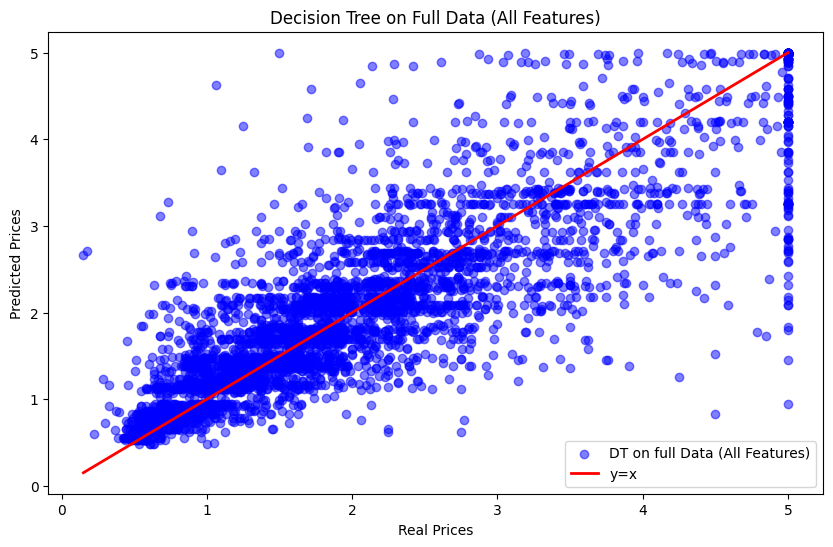

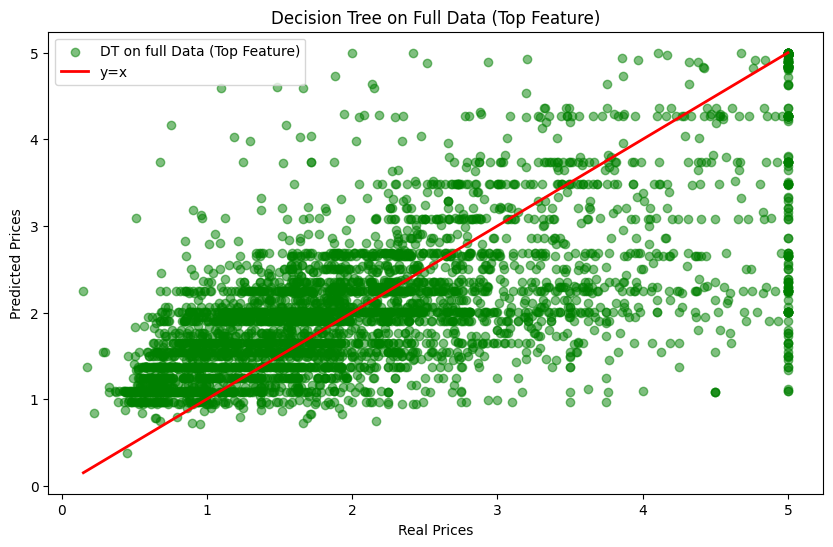

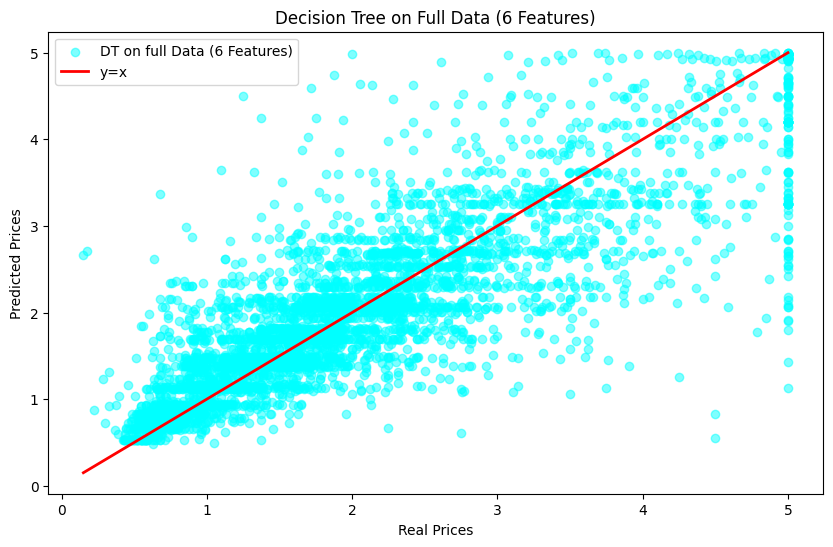

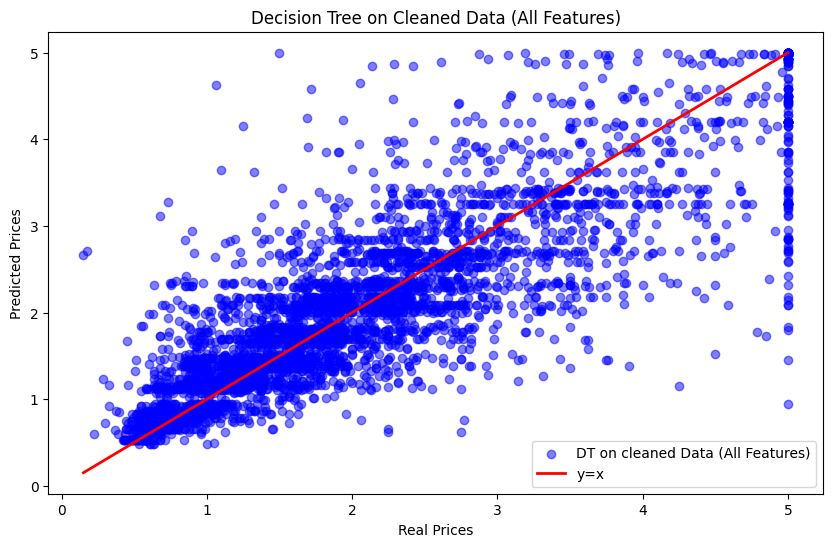

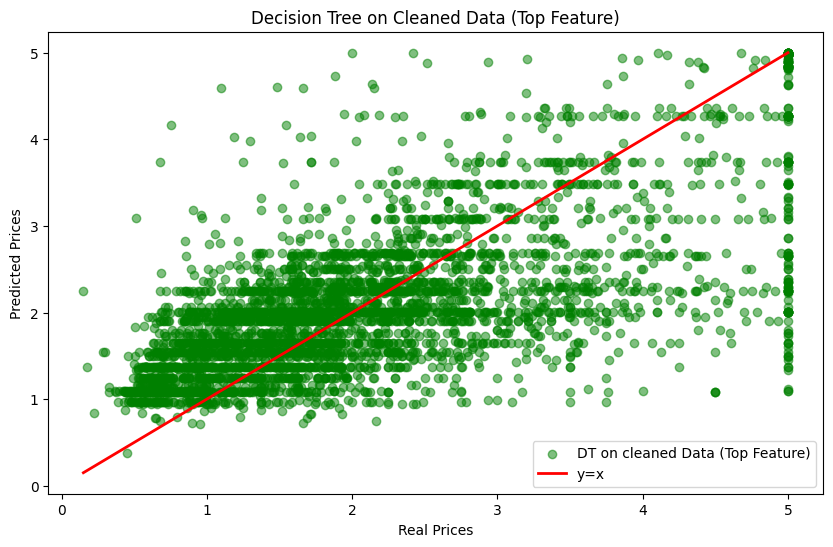

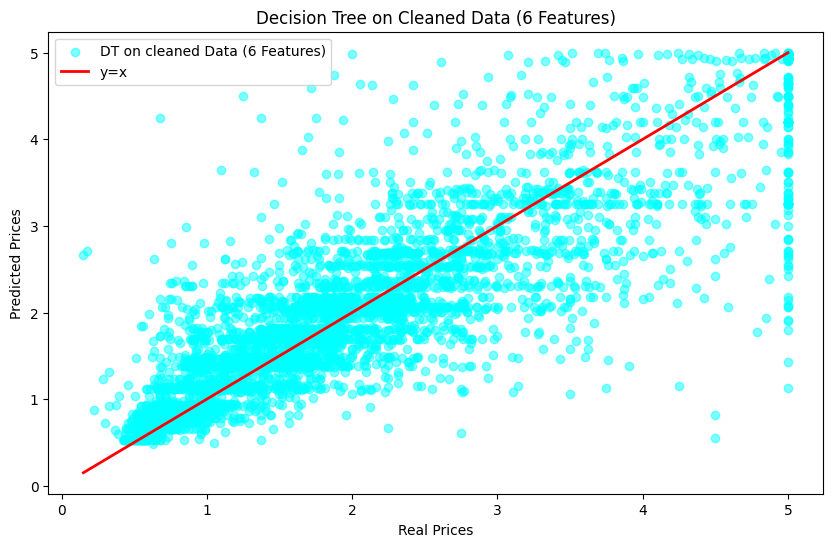

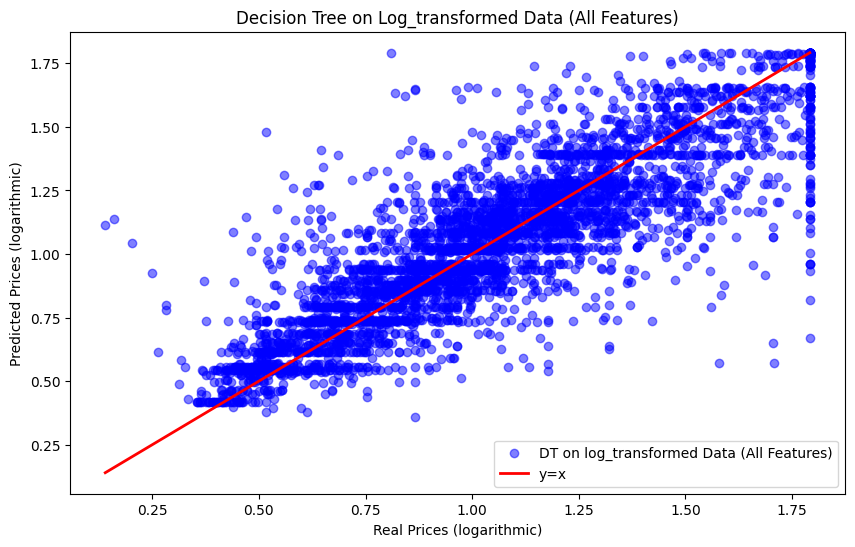

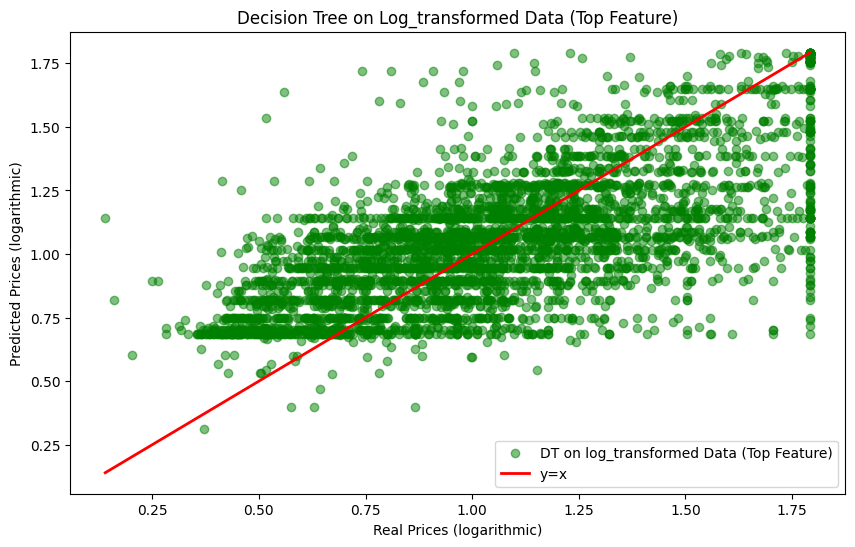

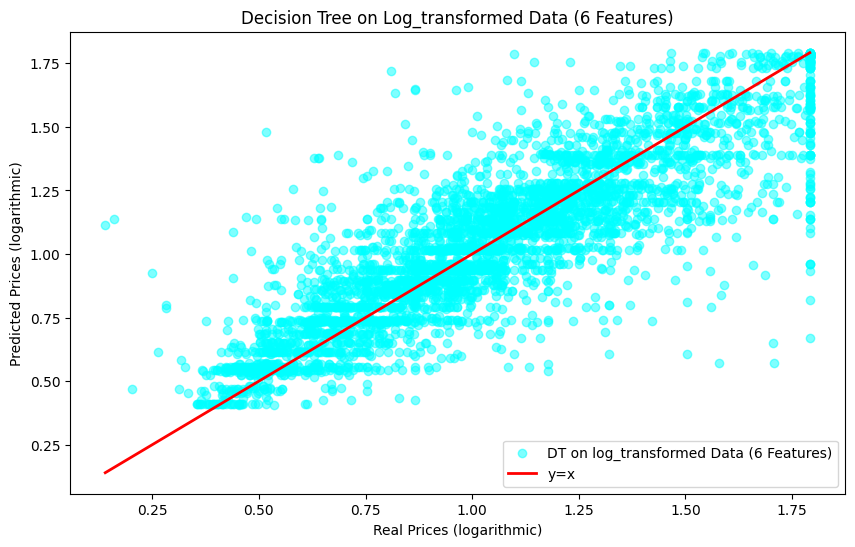

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Define original feature names
original_feature_names = housing['feature_names']  # All 8 features

# Function to prepare data for each case
def prepare_data(case):
    """
    Prepare the data based on the specified case:
    - 'full': Use the full dataset.
    - 'cleaned': Clip outliers above the 98th percentile for specific features.
    - 'log_transformed': Apply log1p transformation to the target variable.
    """
    if case == 'full':
        X = data[original_feature_names].values
        y = data['MedHouseVal'].values
    elif case == 'cleaned':
        data_cleaned = data.copy()
        quantile_98 = data_cleaned.quantile(0.98)
        for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
            data_cleaned[col] = data_cleaned[col].clip(upper=quantile_98[col])
        X = data_cleaned[original_feature_names].values
        y = data_cleaned['MedHouseVal'].values
    elif case == 'log_transformed':
        data_log = data.copy()
        data_log['MedHouseVal'] = np.log1p(data_log['MedHouseVal'])
        X = data_log[original_feature_names].values
        y = data_log['MedHouseVal'].values
    else:
        raise ValueError("Invalid case specified")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Function to train and evaluate Decision Tree with specified features
def train_and_evaluate_dt(X_train_scaled, X_test_scaled, y_train, y_test, case, feature_names, feature_subset=None):
    """
    Train and evaluate a Decision Tree model with the specified features.
    If feature_subset is provided, use only those features.
    """
    dt = DecisionTreeRegressor(random_state=42)
    param_grid = {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    # If a subset of features is provided, select those features
    if feature_subset:
        indices = [feature_names.index(f) for f in feature_subset]
        X_train_subset = X_train_scaled[:, indices]
        X_test_subset = X_test_scaled[:, indices]
    else:
        X_train_subset = X_train_scaled
        X_test_subset = X_test_scaled

    # Train the model with GridSearchCV
    dt_cv = GridSearchCV(dt, param_grid, cv=5, scoring='r2')
    dt_cv.fit(X_train_subset, y_train)

    # Evaluate the model
    print(f"\nDecision Tree on {case} Data (Features: {feature_subset if feature_subset else 'All'}):")
    print("Best Parameters:", dt_cv.best_params_)
    print("Training R2 Score: {:.4f}".format(dt_cv.score(X_train_subset, y_train)))
    y_pred = dt_cv.predict(X_test_subset)

    # For log-transformed case, transform predictions and true values back to original scale for MSE and R2
    if case == 'log_transformed':
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        mse = mean_squared_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        print("Test MSE (original scale): {:.4f}".format(mse))
        print("Test R2 Score (original scale): {:.4f}".format(r2))
        y_test_plot = y_test
        y_pred_plot = y_pred
    else:
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print("Test MSE: {:.4f}".format(mse))
        print("Test R2 Score: {:.4f}".format(r2))
        y_test_plot = y_test
        y_pred_plot = y_pred

    # Feature importance (only for models with all features)
    if not feature_subset:
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': dt_cv.best_estimator_.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        print("\nFeature Importance:\n", feature_importance)
    else:
        feature_importance = None

    return dt_cv, r2, y_pred_plot, y_test_plot, feature_importance

# Main loop to process each case
cases = ['full', 'cleaned', 'log_transformed']
results = {}

for case in cases:
    print(f"\n--- {case.upper()} DATA ---")
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_data(case)

    # 1. Decision Tree with all features
    dt_cv_all, r2_all, y_pred_all, y_test_all, feature_importance = train_and_evaluate_dt(
        X_train_scaled, X_test_scaled, y_train, y_test, case, original_feature_names
    )
    results[f"{case}_all"] = (r2_all, y_pred_all, y_test_all)

    # 2. Decision Tree with only the top feature
    top_feature = feature_importance.head(1)['Feature'].iloc[0]
    dt_cv_top, r2_top, y_pred_top, y_test_top, _ = train_and_evaluate_dt(
        X_train_scaled, X_test_scaled, y_train, y_test, case, original_feature_names, [top_feature]
    )
    results[f"{case}_top"] = (r2_top, y_pred_top, y_test_top)

    # 3. Decision Tree with 6 features (excluding the 2 weakest)
    weak_features = feature_importance.tail(2)['Feature'].tolist()
    print("\nWeak features excluded:", weak_features)
    selected_features = feature_importance.head(6)['Feature'].tolist()
    dt_cv_6, r2_6, y_pred_6, y_test_6, _ = train_and_evaluate_dt(
        X_train_scaled, X_test_scaled, y_train, y_test, case, original_feature_names, selected_features
    )
    results[f"{case}_6"] = (r2_6, y_pred_6, y_test_6)

# Plot actual vs predicted values for each case
for case in cases:
    # Plot for all features
    plt.figure(figsize=(10, 6))
    plt.scatter(results[f"{case}_all"][2], results[f"{case}_all"][1], color='blue', alpha=0.5, label=f'DT on {case} Data (All Features)')
    plt.plot([results[f"{case}_all"][2].min(), results[f"{case}_all"][2].max()],
             [results[f"{case}_all"][2].min(), results[f"{case}_all"][2].max()], color='red', lw=2, label='y=x')
    plt.xlabel('Real Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.ylabel('Predicted Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.title(f'Decision Tree on {case.capitalize()} Data (All Features)')
    plt.legend()
    plt.show()

    # Plot for top feature
    plt.figure(figsize=(10, 6))
    plt.scatter(results[f"{case}_top"][2], results[f"{case}_top"][1], color='green', alpha=0.5, label=f'DT on {case} Data (Top Feature)')
    plt.plot([results[f"{case}_top"][2].min(), results[f"{case}_top"][2].max()],
             [results[f"{case}_top"][2].min(), results[f"{case}_top"][2].max()], color='red', lw=2, label='y=x')
    plt.xlabel('Real Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.ylabel('Predicted Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.title(f'Decision Tree on {case.capitalize()} Data (Top Feature)')
    plt.legend()
    plt.show()

    # Plot for 6 features
    plt.figure(figsize=(10, 6))
    plt.scatter(results[f"{case}_6"][2], results[f"{case}_6"][1], color='cyan', alpha=0.5, label=f'DT on {case} Data (6 Features)')
    plt.plot([results[f"{case}_6"][2].min(), results[f"{case}_6"][2].max()],
             [results[f"{case}_6"][2].min(), results[f"{case}_6"][2].max()], color='red', lw=2, label='y=x')
    plt.xlabel('Real Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.ylabel('Predicted Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.title(f'Decision Tree on {case.capitalize()} Data (6 Features)')
    plt.legend()
    plt.show()

k-Nächste-Nachbarn  model


--- FULL DATA ---

KNN on full Data (n_neighbors 5):
Best parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Training R2 score: 1.0000
Test MSE: 0.3991
Test R2 score: 0.6954
Cross-Validation MSE Scores (KNN, full, n_neighbors 5): [0.5664344  0.56394148 0.56873709 0.582931   0.60015617]
Mean CV MSE (KNN, full, n_neighbors 5): 0.5764400295861483

KNN on full Data (n_neighbors 11):
Best parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Training R2 score: 1.0000
Test MSE: 0.3849
Test R2 score: 0.7063
Cross-Validation MSE Scores (KNN, full, n_neighbors 11): [0.51404904 0.51487264 0.54766338 0.56516058 0.57307494]
Mean CV MSE (KNN, full, n_neighbors 11): 0.542964116926586

KNN on full Data (n_neighbors range):
Best parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': np.int64(13), 'p': 1, 'weights': 'distance'}
Training R2 score: 1.0000
Test MSE: 0.3841
Test R2 

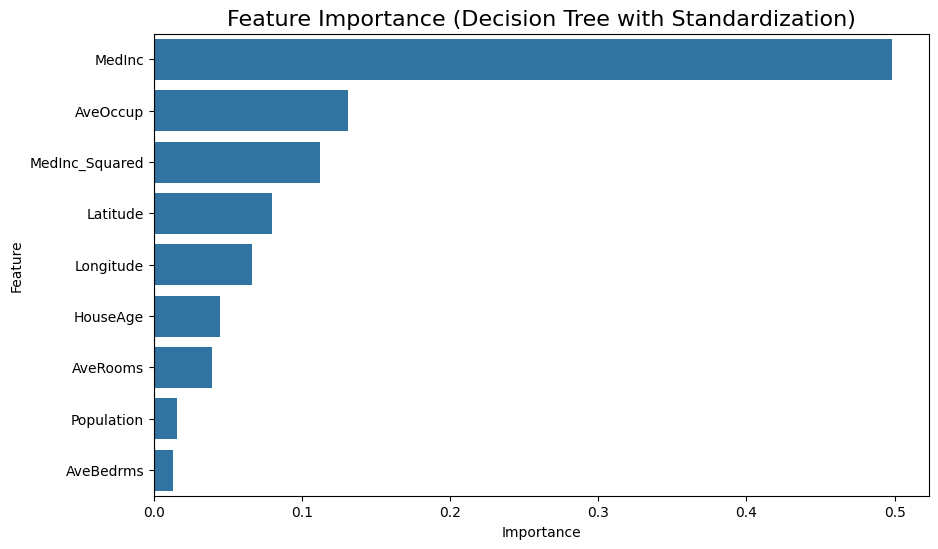


Cross-Validation MSE Scores (Decision Tree): [0.67536427 0.51887091 0.5572684  0.782272   0.67577256]
Mean CV MSE (Decision Tree): 0.6419096283461522

Linear Regression with Standardization:
Training R2 score: 0.6181
Test MSE (Linear Regression): 0.5559546527330317
Test R2 score (Linear Regression): 0.5757395882014267

Lasso Regression with Standardization:
Best alpha: 0.000799
Training R2 score: 0.6181
Test MSE (Lasso Regression): 0.5542886044283922
Test R2 score (Lasso Regression): 0.5770109838743074

--- CLEANED DATA ---

KNN on cleaned Data (n_neighbors 5):
Best parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Training R2 score: 1.0000
Test MSE: 0.3616
Test R2 score: 0.7241
Cross-Validation MSE Scores (KNN, cleaned, n_neighbors 5): [0.52013538 0.41743586 0.47442272 0.58675893 0.56958798]
Mean CV MSE (KNN, cleaned, n_neighbors 5): 0.5136681759904478

KNN on cleaned Data (n_neighbors 11):
Best parameters: {'algorithm': 'auto',

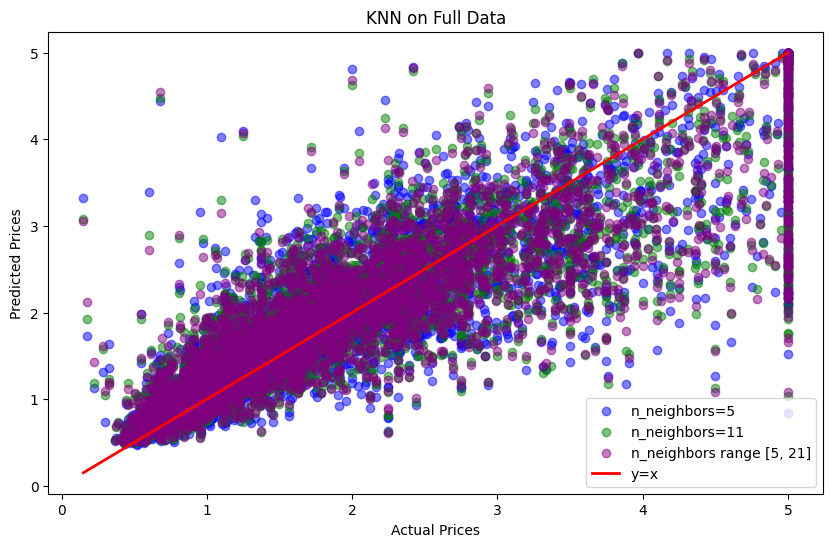

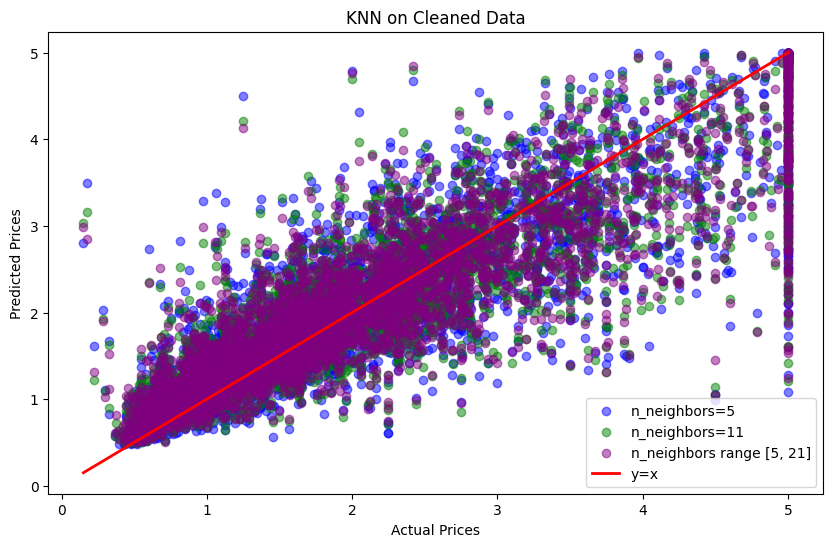

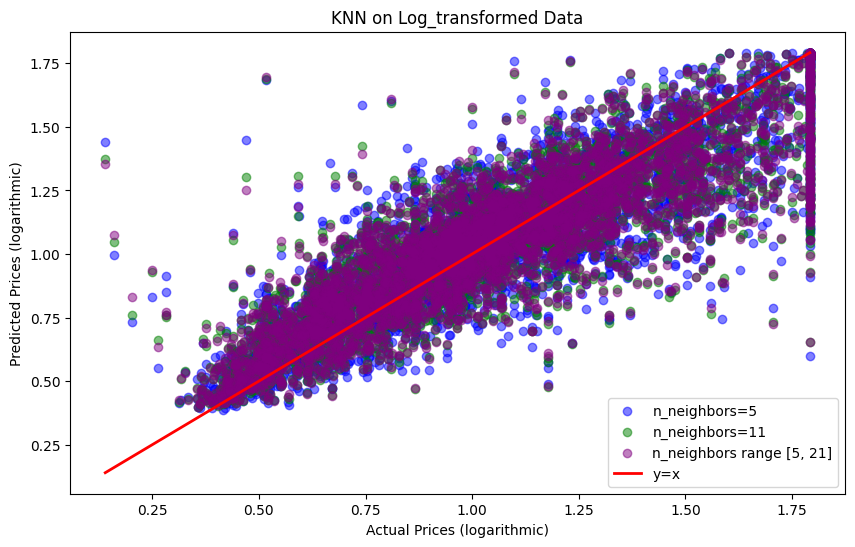

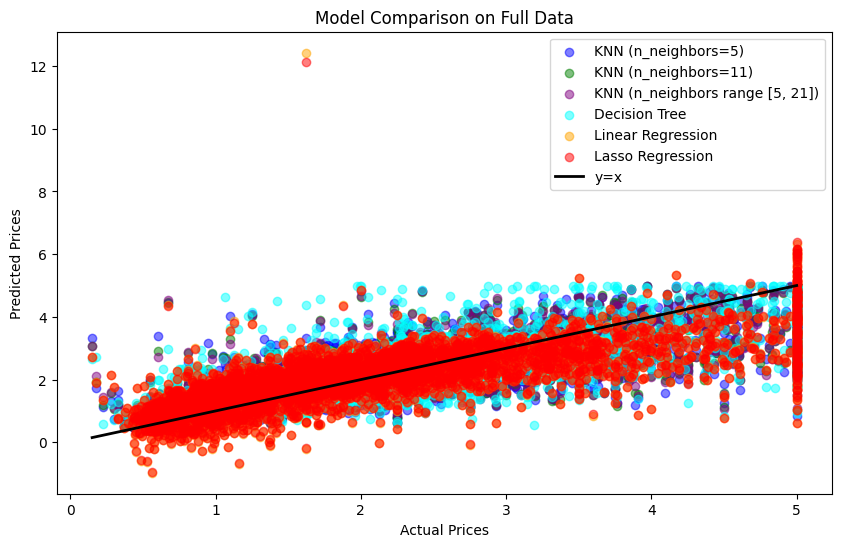


Comparison with lecture results (LASSO):
Training R2 score (Vorlesung LASSO): 0.6461
Test R2 score (Vorlesung LASSO): 0.6419


In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Feature Engineering (adding MedInc_Squared)
data['MedInc_Squared'] = data['MedInc'] ** 2

# Define feature names
feature_names = data.drop('MedHouseVal', axis=1).columns.tolist()

# Function to prepare data based on the case
def prepare_data(case):
    """
    Prepare the data based on the specified case:
    - 'full': Use the full dataset.
    - 'cleaned': Clip outliers above the 98th percentile for specific features.
    - 'log_transformed': Apply log1p transformation to the target variable.
    """
    if case == 'full':
        X = data.drop('MedHouseVal', axis=1).values
        y = data['MedHouseVal'].values
    elif case == 'cleaned':
        data_cleaned = data.copy()
        quantile_98 = data_cleaned.quantile(0.98)
        for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
            data_cleaned[col] = data_cleaned[col].clip(upper=quantile_98[col])
        X = data_cleaned.drop('MedHouseVal', axis=1).values
        y = data_cleaned['MedHouseVal'].values
    elif case == 'log_transformed':
        data_log = data.copy()
        data_log['MedHouseVal'] = np.log1p(data_log['MedHouseVal'])
        X = data_log.drop('MedHouseVal', axis=1).values
        y = data_log['MedHouseVal'].values
    else:
        raise ValueError("Invalid case specified")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

    # Standardize using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)  # For use in cross-validation

    return X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y

# Function to train and evaluate KNN using GridSearchCV
def train_and_evaluate_knn(X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, case, n_neighbors_option):
    """
    Train and evaluate KNN with specified n_neighbors option:
    - '5': Fixed n_neighbors=5
    - '11': Fixed n_neighbors=11
    - 'range': n_neighbors in range [5, 21]
    """
    knn = KNeighborsRegressor()

    # Define parameter grid based on n_neighbors_option
    if n_neighbors_option == '5':
        param_grid = {
            'n_neighbors': [5],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
            'p': [1, 2],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    elif n_neighbors_option == '11':
        param_grid = {
            'n_neighbors': [11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
            'p': [1, 2],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    elif n_neighbors_option == 'range':
        param_grid = {
            'n_neighbors': np.arange(5, 22),
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
            'p': [1, 2],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    else:
        raise ValueError("Invalid n_neighbors_option specified")

    # Train KNN using GridSearchCV
    knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='r2')
    knn_cv.fit(X_train_scaled, y_train)

    # Evaluate the model
    print(f"\nKNN on {case} Data (n_neighbors {n_neighbors_option}):")
    print("Best parameters:", knn_cv.best_params_)
    print("Training R2 score: {:.4f}".format(knn_cv.score(X_train_scaled, y_train)))
    y_pred = knn_cv.predict(X_test_scaled)

    # For log-transformed case, compute metrics on the original scale
    if case == 'log_transformed':
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        mse = mean_squared_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        print("Test MSE (original scale): {:.4f}".format(mse))
        print("Test R2 score (original scale): {:.4f}".format(r2))
        y_test_plot = y_test
        y_pred_plot = y_pred
    else:
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print("Test MSE: {:.4f}".format(mse))
        print("Test R2 score: {:.4f}".format(r2))
        y_test_plot = y_test
        y_pred_plot = y_pred

    # Cross-validation using the best parameters
    best_knn = KNeighborsRegressor(**knn_cv.best_params_)
    cv_scores = cross_val_score(best_knn, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores = -cv_scores
    print(f"Cross-Validation MSE Scores (KNN, {case}, n_neighbors {n_neighbors_option}):", cv_mse_scores)
    print(f"Mean CV MSE (KNN, {case}, n_neighbors {n_neighbors_option}):", np.mean(cv_mse_scores))

    return r2, y_pred_plot, y_test_plot

# Function to train and evaluate Decision Tree
def train_and_evaluate_dt(X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y):
    dt = DecisionTreeRegressor(random_state=42)
    param_grid_dt = {'max_depth': [None, 10, 20, 30]}
    dt_cv = GridSearchCV(dt, param_grid_dt, cv=5, scoring='r2')
    dt_cv.fit(X_train_scaled, y_train)

    print("\nDecision Tree with Standardization:")
    print("Best max_depth:", dt_cv.best_params_['max_depth'])
    print("Training R2 score: {:.4f}".format(dt_cv.score(X_train_scaled, y_train)))
    y_pred_dt = dt_cv.predict(X_test_scaled)
    mse_dt = mean_squared_error(y_test, y_pred_dt)
    r2_dt = r2_score(y_test, y_pred_dt)
    print("Test MSE (Decision Tree):", mse_dt)
    print("Test R2 score (Decision Tree):", r2_dt)

    # Feature importance
    feature_importance_dt = pd.DataFrame({
        'Feature': feature_names,
        'Importance': dt_cv.best_estimator_.feature_importances_
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    print("\nFeature Importance (Decision Tree):\n", feature_importance_dt)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_dt)
    plt.title('Feature Importance (Decision Tree with Standardization)', fontsize=16)
    plt.axvline(0, color='k', linestyle='--')
    plt.show()

    # Cross-validation
    best_dt = DecisionTreeRegressor(max_depth=dt_cv.best_params_['max_depth'], random_state=42)
    cv_scores_dt = cross_val_score(best_dt, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores_dt = -cv_scores_dt
    print("\nCross-Validation MSE Scores (Decision Tree):", cv_mse_scores_dt)
    print("Mean CV MSE (Decision Tree):", np.mean(cv_mse_scores_dt))

    return r2_dt, y_pred_dt

# Function to train and evaluate Linear Regression
def train_and_evaluate_lr(X_train_scaled, X_test_scaled, y_train, y_test):
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)

    print("\nLinear Regression with Standardization:")
    print("Training R2 score: {:.4f}".format(lr.score(X_train_scaled, y_train)))
    y_pred_lr = lr.predict(X_test_scaled)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)
    print("Test MSE (Linear Regression):", mse_lr)
    print("Test R2 score (Linear Regression):", r2_lr)

    return r2_lr, y_pred_lr

# Function to train and evaluate Lasso Regression
def train_and_evaluate_lasso(X_train_scaled, X_test_scaled, y_train, y_test):
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=1000)
    lasso_cv.fit(X_train_scaled, y_train)

    print("\nLasso Regression with Standardization:")
    print("Best alpha: {:.6f}".format(lasso_cv.alpha_))
    print("Training R2 score: {:.4f}".format(lasso_cv.score(X_train_scaled, y_train)))
    y_pred_lasso = lasso_cv.predict(X_test_scaled)
    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    r2_lasso = r2_score(y_test, y_pred_lasso)
    print("Test MSE (Lasso Regression):", mse_lasso)
    print("Test R2 score (Lasso Regression):", r2_lasso)

    return r2_lasso, y_pred_lasso

# Train and evaluate for each case
cases = ['full', 'cleaned', 'log_transformed']
n_neighbors_options = ['5', '11', 'range']
results = {}

for case in cases:
    print(f"\n--- {case.upper()} DATA ---")
    X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y = prepare_data(case)

    # Train and evaluate KNN for each n_neighbors range
    for n_option in n_neighbors_options:
        r2_knn, y_pred_knn, y_test_knn = train_and_evaluate_knn(
            X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, case, n_option
        )
        results[f"{case}_{n_option}"] = (r2_knn, y_pred_knn, y_test_knn)

    # Train and evaluate Decision Tree (only on full data since DT is not heavily affected by transformations)
    if case == 'full':
        r2_dt, y_pred_dt = train_and_evaluate_dt(X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y)
        results[f"{case}_dt"] = (r2_dt, y_pred_dt, y_test)

        # Train and evaluate Linear Regression
        r2_lr, y_pred_lr = train_and_evaluate_lr(X_train_scaled, X_test_scaled, y_train, y_test)
        results[f"{case}_lr"] = (r2_lr, y_pred_lr, y_test)

        # Train and evaluate Lasso Regression
        r2_lasso, y_pred_lasso = train_and_evaluate_lasso(X_train_scaled, X_test_scaled, y_train, y_test)
        results[f"{case}_lasso"] = (r2_lasso, y_pred_lasso, y_test)

# Plot results for each case
for case in cases:
    plt.figure(figsize=(10, 6))
    plt.scatter(results[f"{case}_5"][2], results[f"{case}_5"][1], color='blue', alpha=0.5, label='n_neighbors=5')
    plt.scatter(results[f"{case}_11"][2], results[f"{case}_11"][1], color='green', alpha=0.5, label='n_neighbors=11')
    plt.scatter(results[f"{case}_range"][2], results[f"{case}_range"][1], color='purple', alpha=0.5, label='n_neighbors range [5, 21]')
    plt.plot([results[f"{case}_5"][2].min(), results[f"{case}_5"][2].max()],
             [results[f"{case}_5"][2].min(), results[f"{case}_5"][2].max()], color='red', lw=2, label='y=x')
    plt.xlabel('Actual Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.ylabel('Predicted Prices' + (' (logarithmic)' if case == 'log_transformed' else ''))
    plt.title(f'KNN on {case.capitalize()} Data')
    plt.legend()
    plt.show()

# Plot comparison for full data with other models
if 'full_dt' in results:
    plt.figure(figsize=(10, 6))
    plt.scatter(results['full_5'][2], results['full_5'][1], color='blue', alpha=0.5, label='KNN (n_neighbors=5)')
    plt.scatter(results['full_11'][2], results['full_11'][1], color='green', alpha=0.5, label='KNN (n_neighbors=11)')
    plt.scatter(results['full_range'][2], results['full_range'][1], color='purple', alpha=0.5, label='KNN (n_neighbors range [5, 21])')
    plt.scatter(results['full_dt'][2], results['full_dt'][1], color='cyan', alpha=0.5, label='Decision Tree')
    plt.scatter(results['full_lr'][2], results['full_lr'][1], color='orange', alpha=0.5, label='Linear Regression')
    plt.scatter(results['full_lasso'][2], results['full_lasso'][1], color='red', alpha=0.5, label='Lasso Regression')
    plt.plot([results['full_5'][2].min(), results['full_5'][2].max()],
             [results['full_5'][2].min(), results['full_5'][2].max()], color='black', lw=2, label='y=x')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title('Model Comparison on Full Data')
    plt.legend()
    plt.show()

# Comparison with lecture results
print("\nComparison with lecture results (LASSO):")
print("Training R2 score (Vorlesung LASSO): 0.6461")
print("Test R2 score (Vorlesung LASSO): 0.6419")

SVR Model

SVR on Full Data (with scaling):
Best Parameters: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
R2 Score for Training: 0.7768
MSE for Testing: 0.3279
R2 Score for Testing: 0.7498
Cross-Validation MSE Scores (SVR, Full Data): [0.2832482  0.44305387 0.41783846 0.45085936 0.45752563]
Mean CV MSE (SVR, Full Data): 0.41050510422621367

SVR on Cleaned Data (with scaling):
Best Parameters: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
R2 Score for Training: 0.8160
MSE for Testing: 0.3006
R2 Score for Testing: 0.7706
Cross-Validation MSE Scores (SVR, Cleaned Data): [0.28787958 0.41255466 0.37399754 0.4818697  0.45205223]
Mean CV MSE (SVR, Cleaned Data): 0.4016707421580715

SVR on Logarithmically Transformed Data (with scaling):
Best Parameters: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
R2 Score for Training: 0.8141
MSE for Testing (log scale): 0.0267
R2 Score for Testing (log scale): 0.7881
Cross-Validation MSE Scores (SVR, Log-Transformed Data): [0.03384312 0.03469866 0.03201851 0.03943662 0.04191

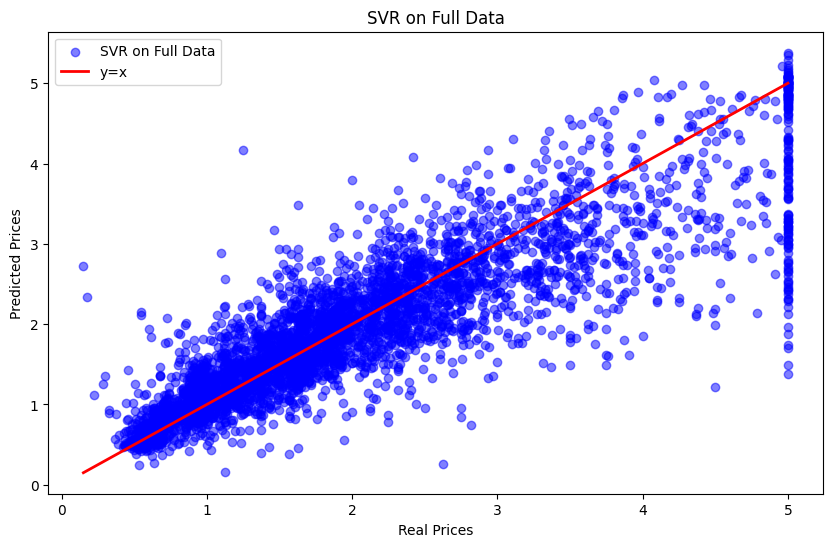

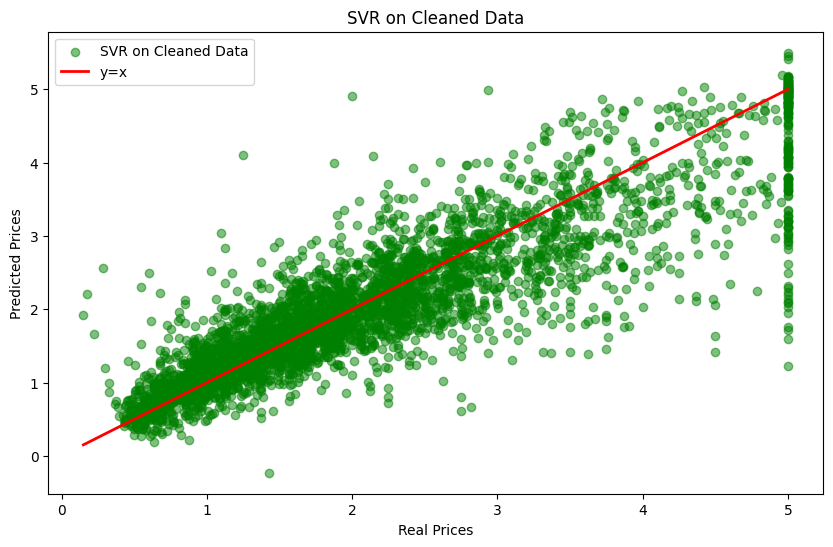

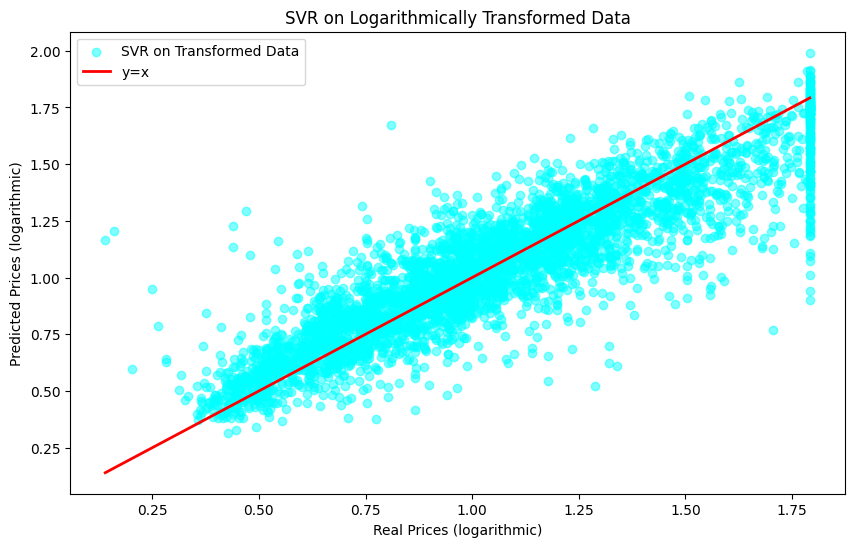

In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Add a new feature (square of median income)
data['MedInc_Squared'] = data['MedInc'] ** 2

# Prepare the data
X = data.drop('MedHouseVal', axis=1).values
y = data['MedHouseVal'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)  # For use in cross-validation

# **1. Train SVR on the full data**
param_grid_svr = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'epsilon': [0.01, 0.1, 0.5],  # Tolerance margin
    'kernel': ['rbf']  # Radial basis function kernel
}
svr = SVR()
svr_cv_full = GridSearchCV(svr, param_grid_svr, cv=5, scoring='r2')
svr_cv_full.fit(X_train_scaled, y_train)

print("SVR on Full Data (with scaling):")
print("Best Parameters:", svr_cv_full.best_params_)
print("R2 Score for Training: {:.4f}".format(svr_cv_full.score(X_train_scaled, y_train)))
y_pred_full = svr_cv_full.predict(X_test_scaled)
print("MSE for Testing: {:.4f}".format(mean_squared_error(y_test, y_pred_full)))
print("R2 Score for Testing: {:.4f}".format(r2_score(y_test, y_pred_full)))

# Cross-validation for SVR on full data
best_svr_full = SVR(**svr_cv_full.best_params_)
cv_scores_full = cross_val_score(best_svr_full, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores_full = -cv_scores_full
print("Cross-Validation MSE Scores (SVR, Full Data):", cv_mse_scores_full)
print("Mean CV MSE (SVR, Full Data):", np.mean(cv_mse_scores_full))

# **2. Train SVR on cleaned data (after removing outliers)**
data_cleaned = data.copy()
quantile_98 = data_cleaned.quantile(0.98)
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    data_cleaned[col] = data_cleaned[col].clip(upper=quantile_98[col])

X_cleaned = data_cleaned.drop('MedHouseVal', axis=1).values
y_cleaned = data_cleaned['MedHouseVal'].values

X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(
    X_cleaned, y_cleaned, train_size=0.8, random_state=42
)
X_train_cleaned_scaled = scaler.fit_transform(X_train_cleaned)
X_test_cleaned_scaled = scaler.transform(X_test_cleaned)
X_cleaned_scaled = scaler.transform(X_cleaned)  # For use in cross-validation

svr_cv_cleaned = GridSearchCV(svr, param_grid_svr, cv=5, scoring='r2')
svr_cv_cleaned.fit(X_train_cleaned_scaled, y_train_cleaned)

print("\nSVR on Cleaned Data (with scaling):")
print("Best Parameters:", svr_cv_cleaned.best_params_)
print("R2 Score for Training: {:.4f}".format(svr_cv_cleaned.score(X_train_cleaned_scaled, y_train_cleaned)))
y_pred_cleaned = svr_cv_cleaned.predict(X_test_cleaned_scaled)
print("MSE for Testing: {:.4f}".format(mean_squared_error(y_test_cleaned, y_pred_cleaned)))
print("R2 Score for Testing: {:.4f}".format(r2_score(y_test_cleaned, y_pred_cleaned)))

# Cross-validation for SVR on cleaned data
best_svr_cleaned = SVR(**svr_cv_cleaned.best_params_)
cv_scores_cleaned = cross_val_score(best_svr_cleaned, X_cleaned_scaled, y_cleaned, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores_cleaned = -cv_scores_cleaned
print("Cross-Validation MSE Scores (SVR, Cleaned Data):", cv_mse_scores_cleaned)
print("Mean CV MSE (SVR, Cleaned Data):", np.mean(cv_mse_scores_cleaned))

# **3. Train SVR on logarithmically transformed data**
data_log = data.copy()
data_log['MedHouseVal'] = np.log1p(data_log['MedHouseVal'])  # Logarithmic transformation
X_log = data_log.drop('MedHouseVal', axis=1).values
y_log = data_log['MedHouseVal'].values

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, train_size=0.8, random_state=42
)
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)
X_log_scaled = scaler.transform(X_log)  # For use in cross-validation

svr_cv_log = GridSearchCV(svr, param_grid_svr, cv=5, scoring='r2')
svr_cv_log.fit(X_train_log_scaled, y_train_log)

print("\nSVR on Logarithmically Transformed Data (with scaling):")
print("Best Parameters:", svr_cv_log.best_params_)
print("R2 Score for Training: {:.4f}".format(svr_cv_log.score(X_train_log_scaled, y_train_log)))
y_pred_log = svr_cv_log.predict(X_test_log_scaled)
print("MSE for Testing (log scale): {:.4f}".format(mean_squared_error(y_test_log, y_pred_log)))
print("R2 Score for Testing (log scale): {:.4f}".format(r2_score(y_test_log, y_pred_log)))

# Cross-validation for SVR on log-transformed data
best_svr_log = SVR(**svr_cv_log.best_params_)
cv_scores_log = cross_val_score(best_svr_log, X_log_scaled, y_log, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores_log = -cv_scores_log
print("Cross-Validation MSE Scores (SVR, Log-Transformed Data):", cv_mse_scores_log)
print("Mean CV MSE (SVR, Log-Transformed Data):", np.mean(cv_mse_scores_log))

# **4. Result plots**
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_full, color='blue', alpha=0.5, label='SVR on Full Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, label='y=x')
plt.xlabel('Real Prices')
plt.ylabel('Predicted Prices')
plt.title('SVR on Full Data')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test_cleaned, y_pred_cleaned, color='green', alpha=0.5, label='SVR on Cleaned Data')
plt.plot([y_test_cleaned.min(), y_test_cleaned.max()], [y_test_cleaned.min(), y_test_cleaned.max()], color='red', lw=2, label='y=x')
plt.xlabel('Real Prices')
plt.ylabel('Predicted Prices')
plt.title('SVR on Cleaned Data')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_pred_log, color='cyan', alpha=0.5, label='SVR on Transformed Data')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', lw=2, label='y=x')
plt.xlabel('Real Prices (logarithmic)')
plt.ylabel('Predicted Prices (logarithmic)')
plt.title('SVR on Logarithmically Transformed Data')
plt.legend()
plt.show()

Komplexe Modelle (XGBoost , Nuetral Network , Random Forest)


Datensatz nach Entfernung der Cut-Offs (MedHouseVal < 5.0):
Anzahl der Einträge: 19648

Datensatz nach Entfernung der oberen 2 % Ausreißer:
Anzahl der Einträge: 17145

KNN:
Beste Parameter: {'metric': 'manhattan', 'n_neighbors': np.int64(15), 'weights': 'distance'}
Training R² Score: 1.0000
Test MSE: 0.2544
Test R² Score: 0.6844
Cross-Validation MSE Scores: [0.346734   0.27029648 0.28284349 0.39751758 0.41416948]
Mean CV MSE: 0.3423122044813149

Decision Tree:
Beste Parameter: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5}
Training R² Score: 0.9349
Test MSE: 0.3125
Test R² Score: 0.6123
Cross-Validation MSE Scores: [0.72331389 0.45748406 0.52414927 0.50653299 0.54865331]
Mean CV MSE: 0.5520267045889254

SVR:
Beste Parameter: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Training R² Score: 0.7809
Test MSE: 0.2057
Test R² Score: 0.7448
Cross-Validation MSE Scores: [0.21251055 0.32046004 0.24580629 0.27797521 0.32991653]
Mean CV MSE: 0

<ipython-input-4-11a12cb65b71>:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R² Score', y=r2_df.index, data=r2_df, palette='viridis')


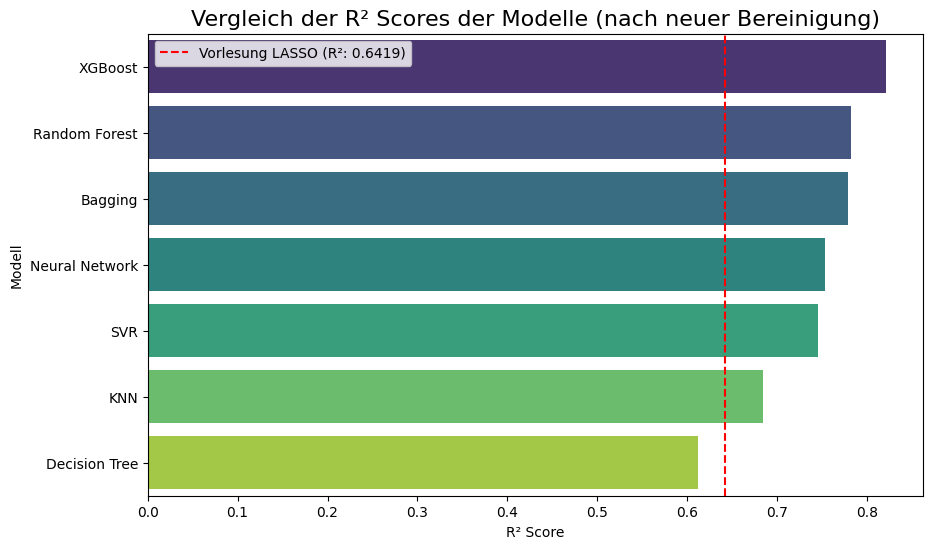

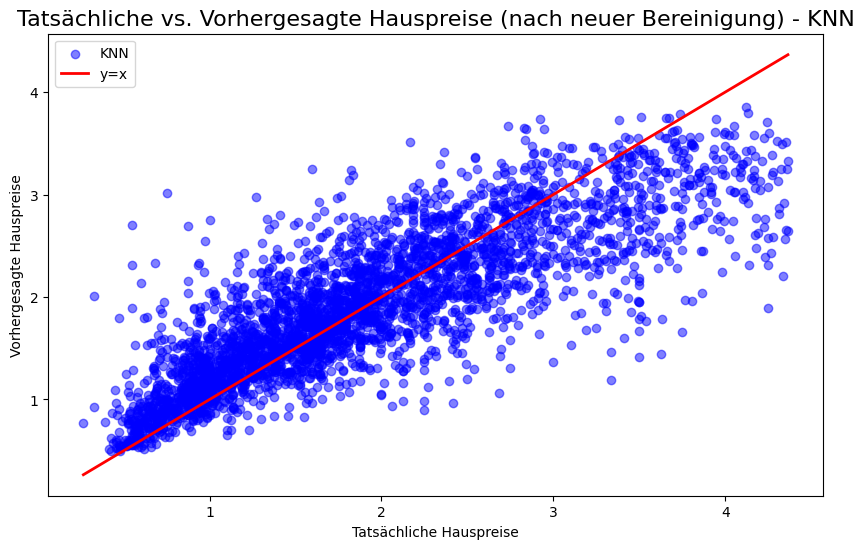

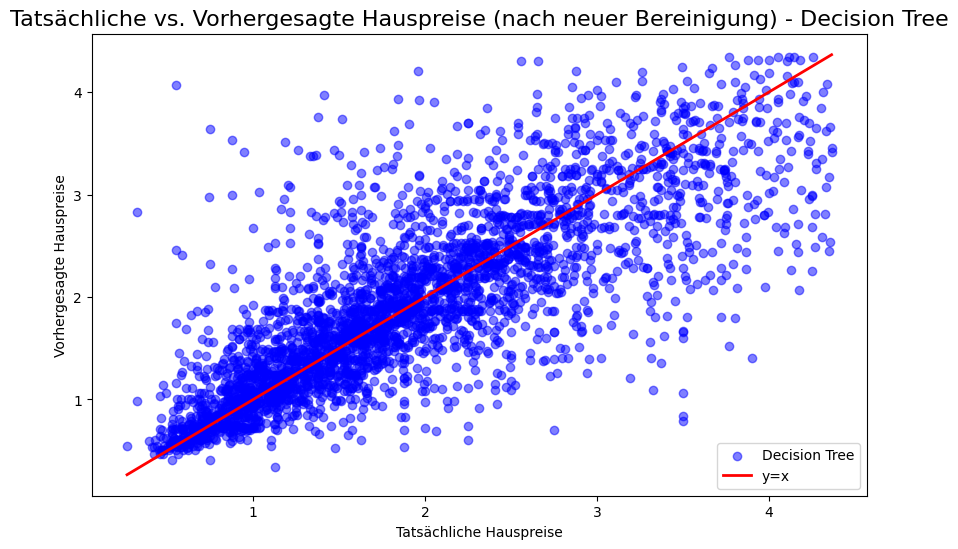

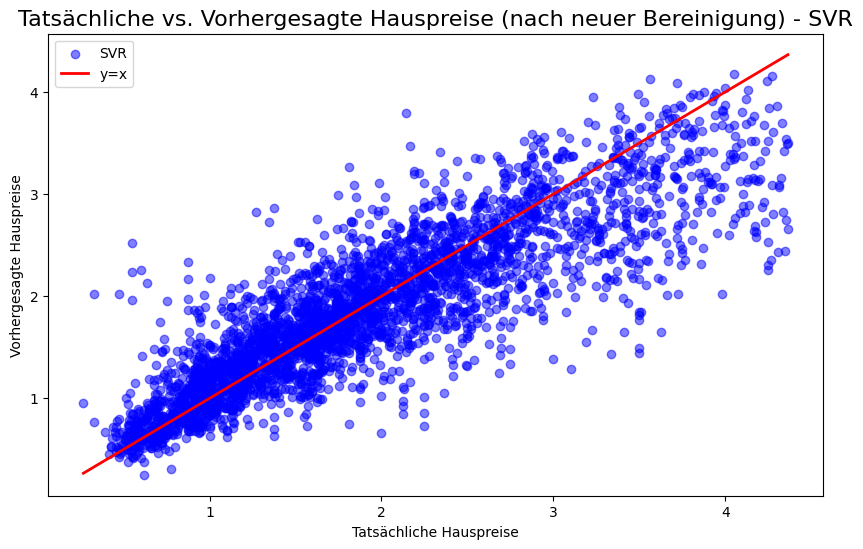

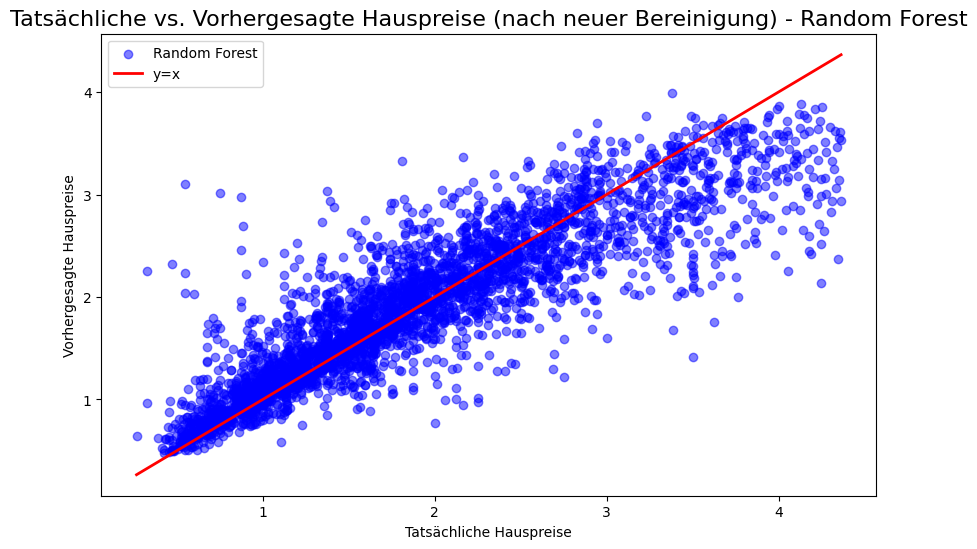

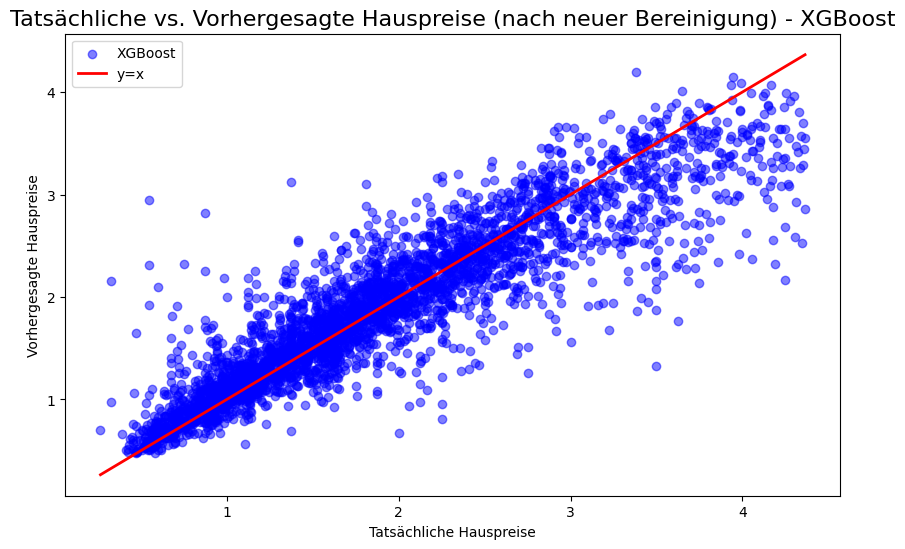

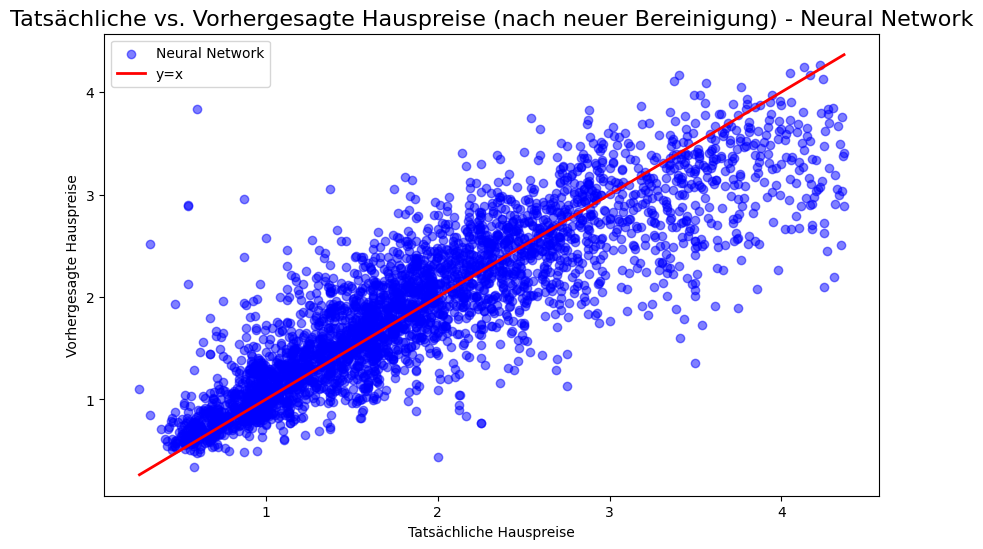

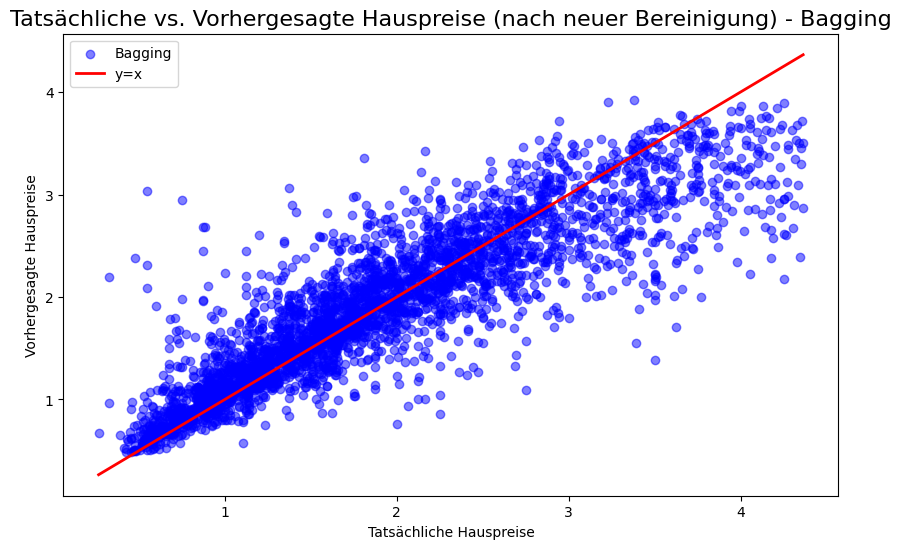


Fazit:
- Alle Modelle wurden nach der Entfernung der Cut-Offs und einheitlicher Ausreißerbehandlung erneut trainiert.
- Kreuzvalidierung wurde für alle Modelle durchgeführt, um die Stabilität zu überprüfen.
- Komplexe Modelle (XGBoost, Random Forest, Neural Network) wurden hinzugefügt.
- Die Visualisierungen zeigen die Leistung der Modelle im Vergleich zur Vorlesungs-LASSO (R²: 0.6419).


In [4]:
# Importieren der benötigten Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import BaggingRegressor


# 1. Daten laden
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['MedHouseVal'] = housing.target

# 2. Feature Engineering
data['MedInc_Squared'] = data['MedInc'] ** 2

# 3. Entfernung der Cut-Offs (MedHouseVal < 5.0)
cutoff_value = 5.0
data_no_cutoff = data[data['MedHouseVal'] < cutoff_value]
print(f"\nDatensatz nach Entfernung der Cut-Offs (MedHouseVal < {cutoff_value}):")
print(f"Anzahl der Einträge: {data_no_cutoff.shape[0]}")

# 4. Einheitliche Ausreißerbehandlung (obere 2 % für alle Features)
upper_quantiles = data_no_cutoff.quantile(0.98)  # Obere 2 %
data_cleaned = data_no_cutoff.copy()
for column in data_cleaned.columns:
    data_cleaned = data_cleaned[data_cleaned[column] <= upper_quantiles[column]]
print(f"\nDatensatz nach Entfernung der oberen 2 % Ausreißer:")
print(f"Anzahl der Einträge: {data_cleaned.shape[0]}")

# 5. Daten vorbereiten
X = data_cleaned.drop('MedHouseVal', axis=1).values
y = data_cleaned['MedHouseVal'].values
feature_names = data_cleaned.drop('MedHouseVal', axis=1).columns.tolist()

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)  # Für Kreuzvalidierung

# 6. Funktion zum Trainieren und Evaluieren eines Modells
def train_and_evaluate_model(model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, X_scaled, y, model_name):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2')
    grid_search.fit(X_train_scaled, y_train)

    print(f"\n{model_name}:")
    print("Beste Parameter:", grid_search.best_params_)
    print("Training R² Score: {:.4f}".format(grid_search.score(X_train_scaled, y_train)))
    y_pred = grid_search.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("Test MSE: {:.4f}".format(mse))
    print("Test R² Score: {:.4f}".format(r2))

    # Kreuzvalidierung
    best_model = grid_search.best_estimator_
    cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores = -cv_scores
    print("Cross-Validation MSE Scores:", cv_mse_scores)
    print("Mean CV MSE:", np.mean(cv_mse_scores))

    return best_model, r2, y_pred

# 7. Modelle definieren und Hyperparameter-Grids
models = {
    'KNN': (KNeighborsRegressor(), {
        'n_neighbors': np.arange(5, 22),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }),
    'Decision Tree': (DecisionTreeRegressor(random_state=42), {
        'max_depth': [15, 20, 25],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': [0.8, 1.0]
    }),
    'SVR': (SVR(), {
        'C': [0.1, 1, 10],
        'epsilon': [0.01, 0.1, 0.5],
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto']
    }),
    'Random Forest': (RandomForestRegressor(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features': [0.8, 1.0]
    }),
    'XGBoost': (XGBRegressor(random_state=42), {
        'n_estimators': [200, 300],
        'max_depth': [6, 8],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }),
    'Neural Network': (MLPRegressor(random_state=42, max_iter=1000), {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'alpha': [0.0001, 0.001],
        'learning_rate_init': [0.001, 0.01],
        'early_stopping': [True]
    }),

    'Bagging': (BaggingRegressor(random_state=42), {
        'n_estimators': [10, 50],
        'max_samples': [0.5, 1.0],
        'max_features': [0.5, 1.0],
        'estimator': [None, DecisionTreeRegressor(max_depth=20)]

    })
}

# 8. Modelle trainieren und evaluieren
results = {}
for model_name, (model, param_grid) in models.items():
    best_model, r2, y_pred = train_and_evaluate_model(
        model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, X_scaled, y, model_name
    )
    results[model_name] = (r2, y_pred)

# 9. Vergleichsplot (R² Scores)
r2_scores = {name: r2 for name, (r2, _) in results.items()}
r2_df = pd.DataFrame.from_dict(r2_scores, orient='index', columns=['R² Score'])
r2_df = r2_df.sort_values(by='R² Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='R² Score', y=r2_df.index, data=r2_df, palette='viridis')
plt.axvline(0.6419, color='red', linestyle='--', label='Vorlesung LASSO (R²: 0.6419)')
plt.title('Vergleich der R² Scores der Modelle (nach neuer Bereinigung)', fontsize=16)
plt.xlabel('R² Score')
plt.ylabel('Modell')
plt.legend()
plt.show()

# 10. Scatterplots (Actual vs. Predicted) - Individuell für jedes Modell
for model_name, (_, y_pred) in results.items():
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, label=model_name, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='y=x')
    plt.xlabel('Tatsächliche Hauspreise')
    plt.ylabel('Vorhergesagte Hauspreise')
    plt.title(f'Tatsächliche vs. Vorhergesagte Hauspreise (nach neuer Bereinigung) - {model_name}', fontsize=16)
    plt.legend()
    plt.show()

# 11. Fazit
print("\nFazit:")
print("- Alle Modelle wurden nach der Entfernung der Cut-Offs und einheitlicher Ausreißerbehandlung erneut trainiert.")
print("- Kreuzvalidierung wurde für alle Modelle durchgeführt, um die Stabilität zu überprüfen.")
print("- Komplexe Modelle (XGBoost, Random Forest, Neural Network) wurden hinzugefügt.")
print("- Die Visualisierungen zeigen die Leistung der Modelle im Vergleich zur Vorlesungs-LASSO (R²: 0.6419).")

Ensemble model


--- FULL DATA ---

Evaluating voting Ensemble for full data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Ensemble Model Performance (voting - full):
Mean Squared Error (MSE): 0.3331
R² Score: 0.7458

Individual Model Performances (full):
Linear Regression - MSE: 0.5560, R²: 0.5757
Lasso Regression - MSE: 0.5543, R²: 0.5770
Decision Tree - MSE: 0.4081, R²: 0.6885
KNN - MSE: 0.3853, R²: 0.7060
SVM - MSE: 0.3257, R²: 0.7515
Random Forest - MSE: 0.2539, R²: 0.8063


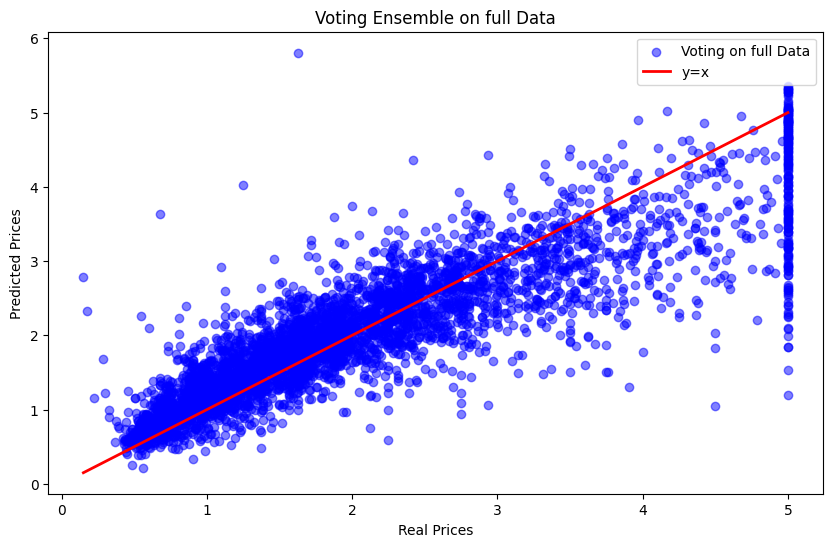


Evaluating weighted_voting Ensemble for full data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Ensemble Model Performance (weighted_voting - full):
Mean Squared Error (MSE): 0.3210
R² Score: 0.7550

Individual Model Performances (full):
Linear Regression - MSE: 0.5560, R²: 0.5757
Lasso Regression - MSE: 0.5543, R²: 0.5770
Decision Tree - MSE: 0.4081, R²: 0.6885
KNN - MSE: 0.3853, R²: 0.7060
SVM - MSE: 0.3257, R²: 0.7515
Random Forest - MSE: 0.2539, R²: 0.8063


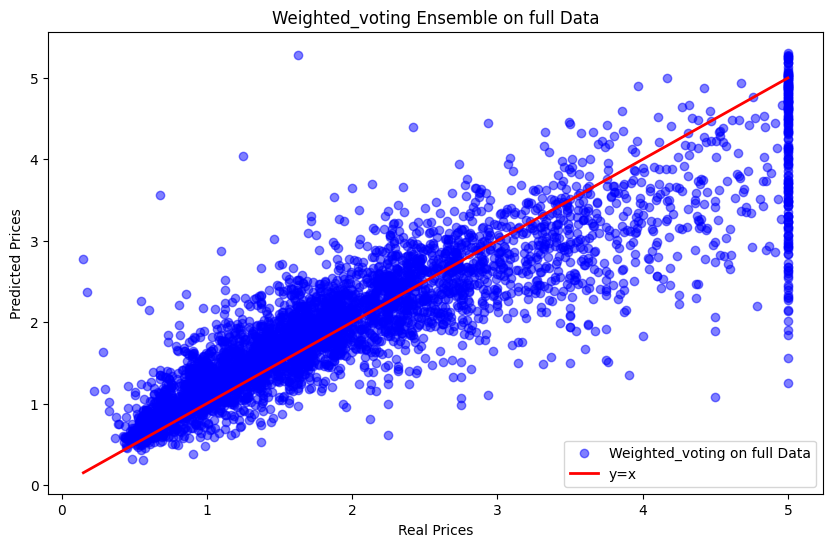


Evaluating stacking Ensemble for full data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Ensemble Model Performance (stacking - full):
Mean Squared Error (MSE): 0.2473
R² Score: 0.8113

Individual Model Performances (full):
Linear Regression - MSE: 0.5560, R²: 0.5757
Lasso Regression - MSE: 0.5543, R²: 0.5770
Decision Tree - MSE: 0.4081, R²: 0.6885
KNN - MSE: 0.3853, R²: 0.7060
SVM - MSE: 0.3257, R²: 0.7515
Random Forest - MSE: 0.2539, R²: 0.8063


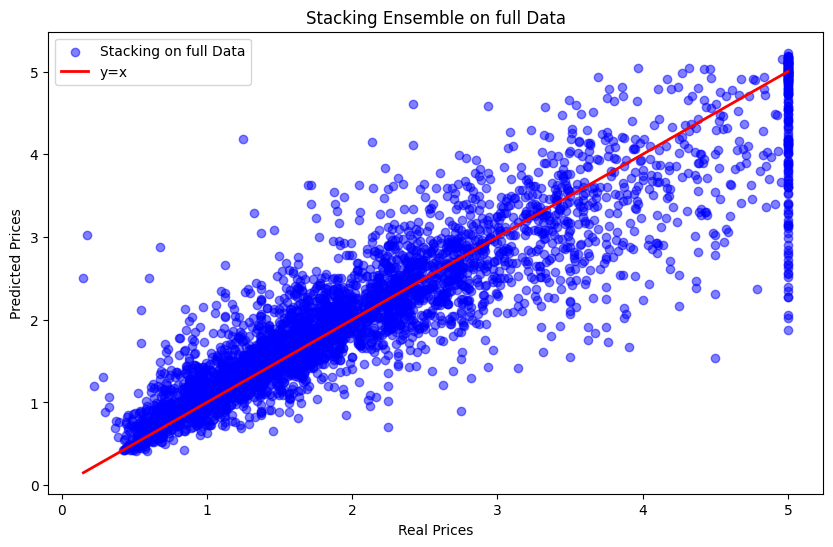


Evaluating bagging Ensemble for full data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Ensemble Model Performance (bagging - full):
Mean Squared Error (MSE): 0.3009
R² Score: 0.7704


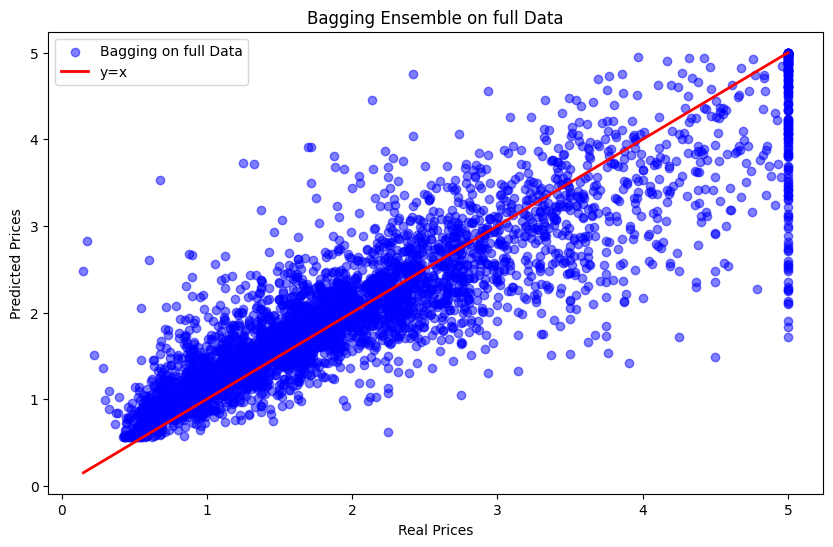


--- CLEANED DATA ---

Evaluating voting Ensemble for cleaned data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (voting - cleaned):
Mean Squared Error (MSE): 0.3043
R² Score: 0.7678

Individual Model Performances (cleaned):
Linear Regression - MSE: 0.4560, R²: 0.6520
Lasso Regression - MSE: 0.4557, R²: 0.6522
Decision Tree - MSE: 0.4089, R²: 0.6879
KNN - MSE: 0.3386, R²: 0.7416
SVM - MSE: 0.2993, R²: 0.7716
Random Forest - MSE: 0.2538, R²: 0.8063


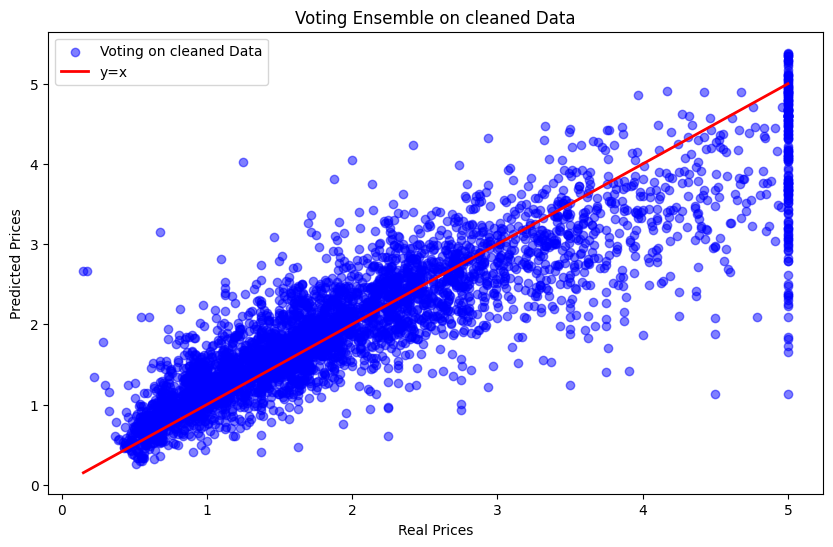


Evaluating weighted_voting Ensemble for cleaned data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (weighted_voting - cleaned):
Mean Squared Error (MSE): 0.2991
R² Score: 0.7717

Individual Model Performances (cleaned):
Linear Regression - MSE: 0.4560, R²: 0.6520
Lasso Regression - MSE: 0.4557, R²: 0.6522
Decision Tree - MSE: 0.4089, R²: 0.6879
KNN - MSE: 0.3386, R²: 0.7416
SVM - MSE: 0.2993, R²: 0.7716
Random Forest - MSE: 0.2538, R²: 0.8063


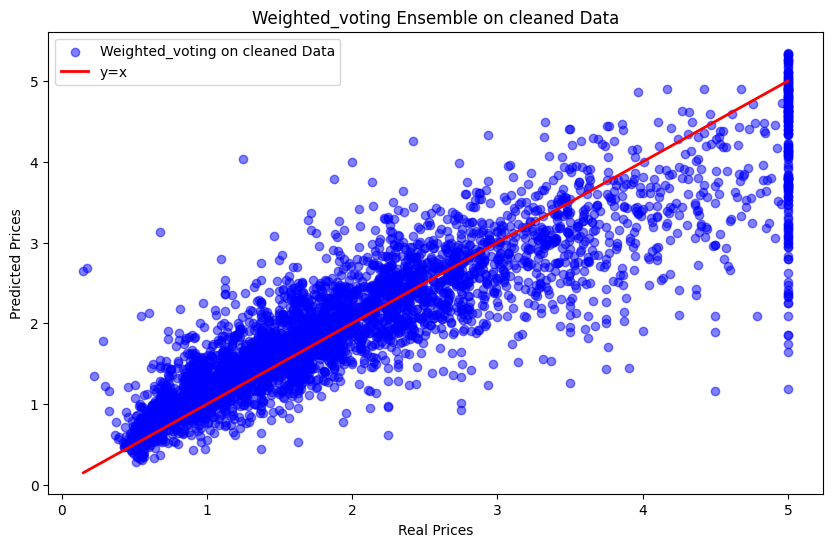


Evaluating stacking Ensemble for cleaned data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (stacking - cleaned):
Mean Squared Error (MSE): 0.2459
R² Score: 0.8124

Individual Model Performances (cleaned):
Linear Regression - MSE: 0.4560, R²: 0.6520
Lasso Regression - MSE: 0.4557, R²: 0.6522
Decision Tree - MSE: 0.4089, R²: 0.6879
KNN - MSE: 0.3386, R²: 0.7416
SVM - MSE: 0.2993, R²: 0.7716
Random Forest - MSE: 0.2538, R²: 0.8063


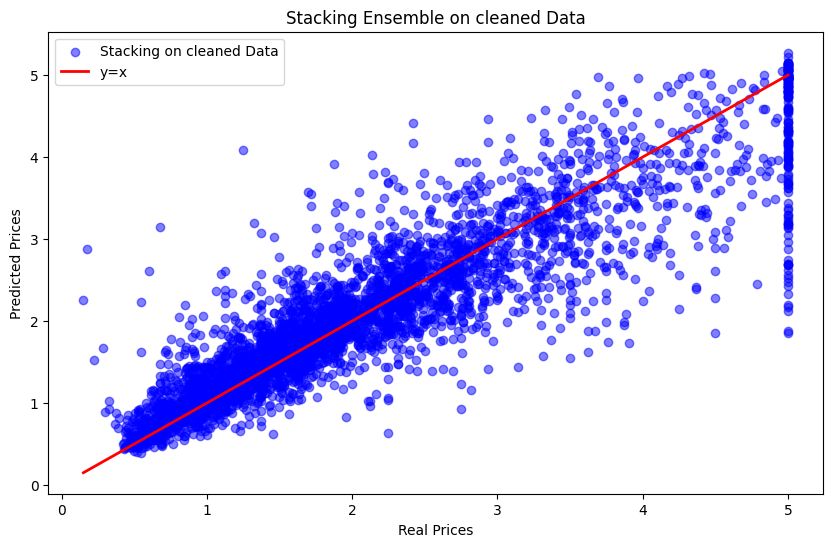


Evaluating bagging Ensemble for cleaned data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (bagging - cleaned):
Mean Squared Error (MSE): 0.2997
R² Score: 0.7713


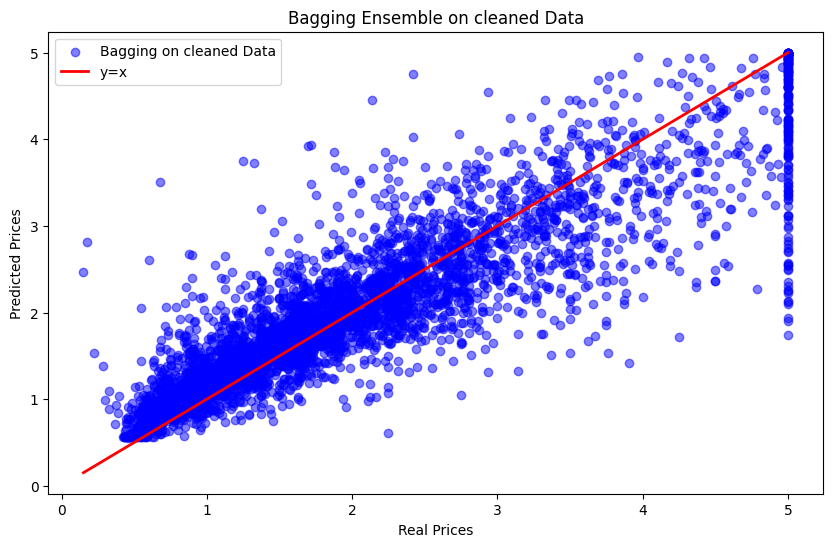


--- LOG_TRANSFORMED DATA ---

Evaluating voting Ensemble for log_transformed data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (voting - log_transformed):
Mean Squared Error (MSE): 0.3402
R² Score: 0.7404

Individual Model Performances (log_transformed):
Linear Regression - MSE: 1.5495, R²: -0.1824
Lasso Regression - MSE: 1.3720, R²: -0.0470
Decision Tree - MSE: 0.3934, R²: 0.6998
KNN - MSE: 0.3914, R²: 0.7013
SVM - MSE: 0.3069, R²: 0.7658
Random Forest - MSE: 0.2603, R²: 0.8014


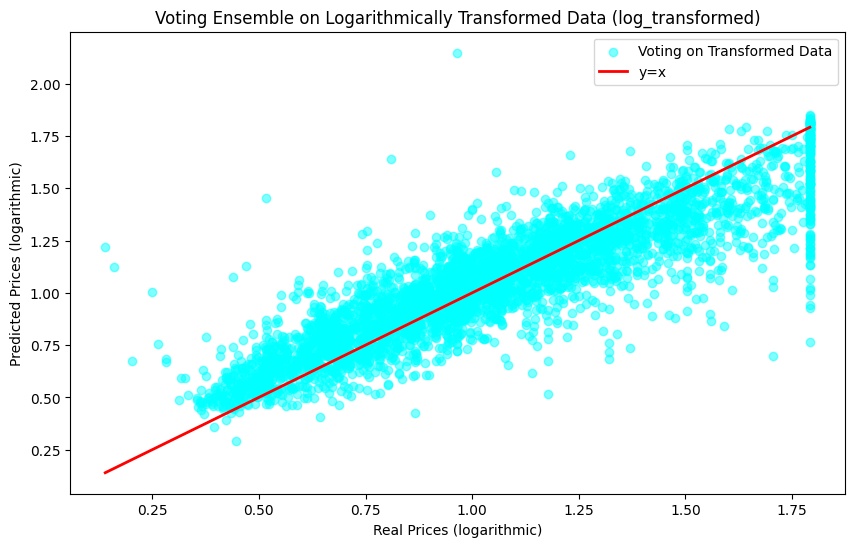


Evaluating weighted_voting Ensemble for log_transformed data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (weighted_voting - log_transformed):
Mean Squared Error (MSE): 0.2798
R² Score: 0.7865

Individual Model Performances (log_transformed):
Linear Regression - MSE: 1.5495, R²: -0.1824
Lasso Regression - MSE: 1.3720, R²: -0.0470
Decision Tree - MSE: 0.3934, R²: 0.6998
KNN - MSE: 0.3914, R²: 0.7013
SVM - MSE: 0.3069, R²: 0.7658
Random Forest - MSE: 0.2603, R²: 0.8014


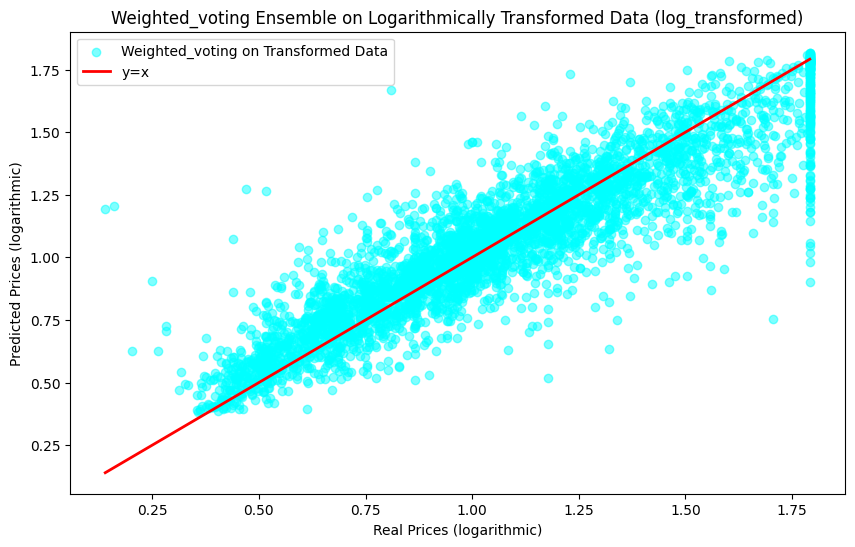


Evaluating stacking Ensemble for log_transformed data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (stacking - log_transformed):
Mean Squared Error (MSE): 0.2480
R² Score: 0.8108

Individual Model Performances (log_transformed):
Linear Regression - MSE: 1.5495, R²: -0.1824
Lasso Regression - MSE: 1.3720, R²: -0.0470
Decision Tree - MSE: 0.3934, R²: 0.6998
KNN - MSE: 0.3914, R²: 0.7013
SVM - MSE: 0.3069, R²: 0.7658
Random Forest - MSE: 0.2603, R²: 0.8014


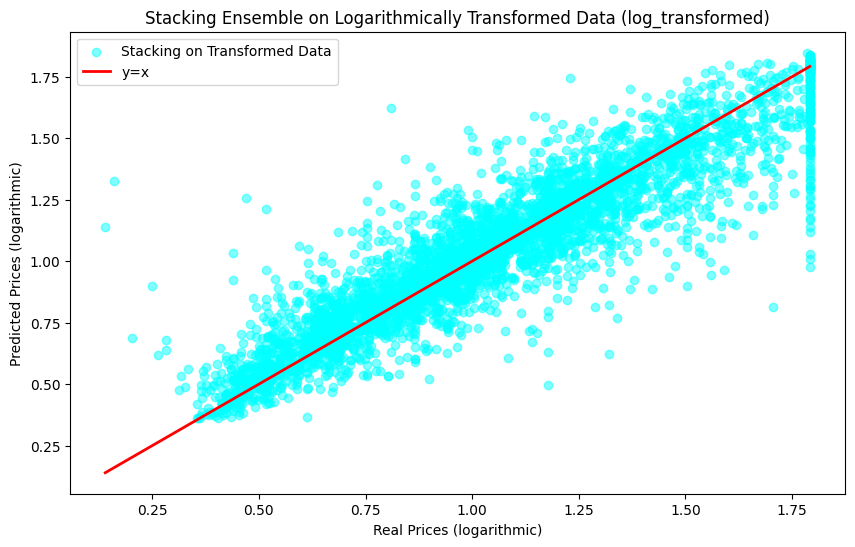


Evaluating bagging Ensemble for log_transformed data
Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best parameters for KNeighborsRegressor: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Ensemble Model Performance (bagging - log_transformed):
Mean Squared Error (MSE): 0.3037
R² Score: 0.7682


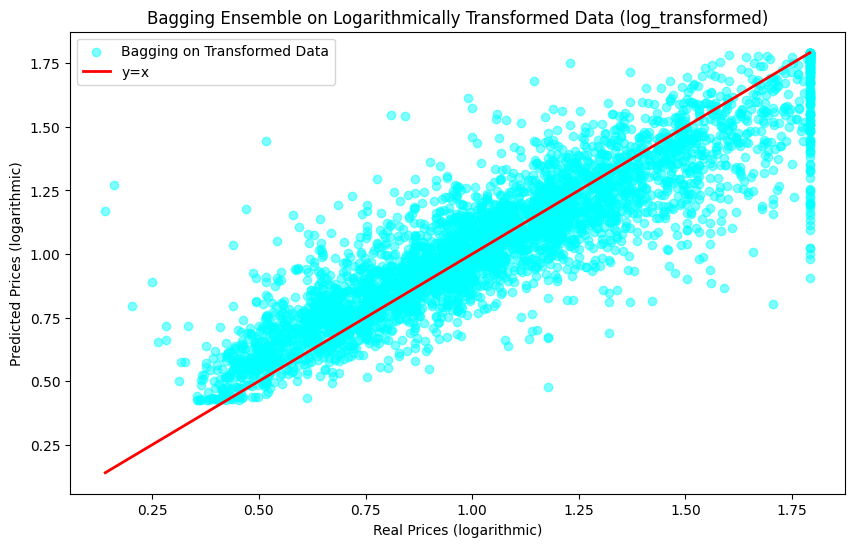

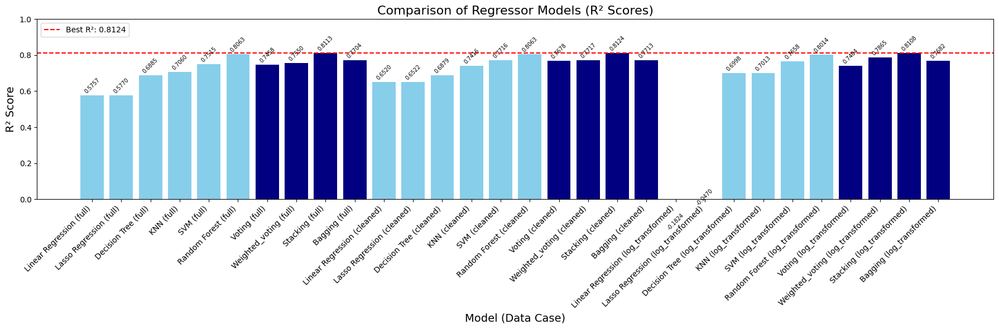

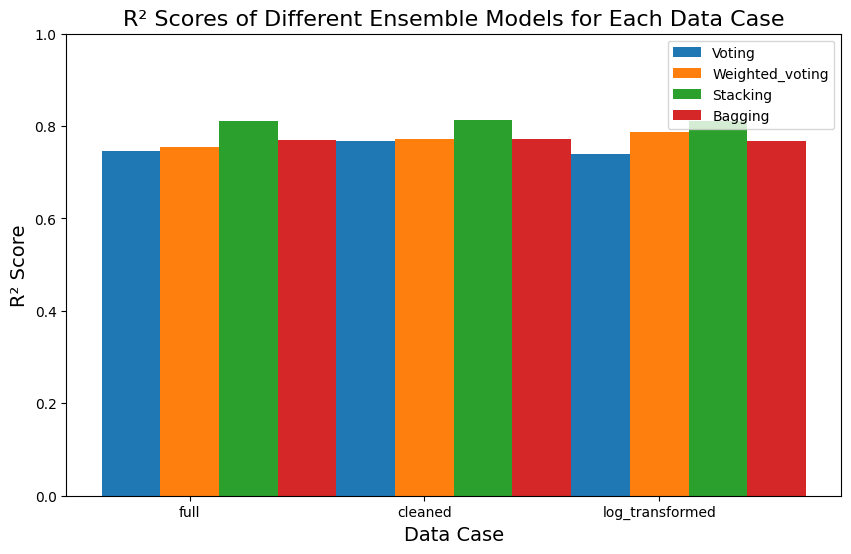

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor, StackingRegressor, BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Feature Engineering: Add a squared term for Median Income
data['MedInc_Squared'] = data['MedInc'] ** 2

# Function to prepare data for each case
def prepare_data(case):
    """
    Prepare the data based on the specified case:
    - 'full': Use the full dataset.
    - 'cleaned': Clip outliers above the 98th percentile for specific features.
    - 'log_transformed': Apply log1p transformation to the target variable.
    """
    if case == 'full':
        X = data.drop('MedHouseVal', axis=1).values
        y = data['MedHouseVal'].values
    elif case == 'cleaned':
        data_cleaned = data.copy()
        quantile_98 = data_cleaned.quantile(0.98)
        for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
            data_cleaned[col] = data_cleaned[col].clip(upper=quantile_98[col])
        X = data_cleaned.drop('MedHouseVal', axis=1).values
        y = data_cleaned['MedHouseVal'].values
    elif case == 'log_transformed':
        data_log = data.copy()
        data_log['MedHouseVal'] = np.log1p(data_log['MedHouseVal'])
        X = data_log.drop('MedHouseVal', axis=1).values
        y = data_log['MedHouseVal'].values
    else:
        raise ValueError("Invalid case specified")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Function to tune hyperparameters using GridSearchCV
def tune_model(model, param_grid, X_train, y_train):
    """
    Tune the hyperparameters of the model using GridSearchCV and display the best parameters.
    """
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Best parameters for {model.__class__.__name__}: {grid_search.best_params_}")
    return grid_search.best_estimator_

# Function to create and train individual models with hyperparameter tuning
def create_and_train_models(X_train_scaled, y_train):
    """
    Create and train individual models with hyperparameter tuning:
    - Linear Regression (no tuning needed)
    - Lasso Regression (uses LassoCV)
    - Decision Tree Regressor
    - K-Nearest Neighbors Regressor
    - Support Vector Regressor
    - Random Forest Regressor
    """
    # Define models
    models = {
        'Linear Regression': LinearRegression(),
        'Lasso Regression': LassoCV(cv=5, random_state=42, max_iter=1000),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'KNN': KNeighborsRegressor(),
        'SVM': SVR(kernel='rbf'),
        'Random Forest': RandomForestRegressor(random_state=42)
    }

    # Define detailed parameter grids for models requiring tuning
    param_grids = {
        'Decision Tree': {
            'max_depth': [5, 10, 15, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'KNN': {
            'n_neighbors': [3, 5, 7, 10],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]  # Manhattan (1) and Euclidean (2) distances
        },
        'SVM': {
            'C': [0.1, 1, 10],
            'epsilon': [0.1, 0.2, 0.5],
            'gamma': ['scale', 'auto', 0.1]
        },
        'Random Forest': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    }

    # Tune and train models
    for name in models.keys():
        if name in param_grids:
            models[name] = tune_model(models[name], param_grids[name], X_train_scaled, y_train)
        else:
            models[name].fit(X_train_scaled, y_train)

    return models

# Function to train and evaluate different Ensemble models with scatter plot
def train_and_evaluate_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, case, ensemble_type='voting'):
    """
    Train and evaluate the specified Ensemble model:
    - 'voting': Voting Regressor
    - 'weighted_voting': Weighted Voting Regressor based on individual R² scores
    - 'stacking': Stacking Regressor with Ridge as meta-model
    - 'bagging': Bagging Regressor with Random Forest as base model
    Evaluate individual models for comparison (for Voting and Stacking only).
    Create a scatter plot of predictions vs. true values.
    Returns R² scores for individual models and the ensemble model.
    """
    # Create and train individual models
    models = create_and_train_models(X_train_scaled, y_train)

    # Evaluate individual models to get R² scores for weighting
    individual_r2_scores = {}
    for name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        if case == 'log_transformed':
            y_pred = np.expm1(y_pred)
            y_test_original = np.expm1(y_test)
        else:
            y_test_original = y_test
        r2 = r2_score(y_test_original, y_pred)
        individual_r2_scores[name] = r2

    # Select Ensemble type
    if ensemble_type == 'voting':
        ensemble_model = VotingRegressor(estimators=[
            (name, model) for name, model in models.items()
        ])
    elif ensemble_type == 'weighted_voting':
        # Normalize R² scores to use as weights
        total_r2 = sum(individual_r2_scores.values())
        weights = [individual_r2_scores[name] / total_r2 for name in models.keys()]
        ensemble_model = VotingRegressor(
            estimators=[(name, model) for name, model in models.items()],
            weights=weights
        )
    elif ensemble_type == 'stacking':
        ensemble_model = StackingRegressor(
            estimators=[(name, model) for name, model in models.items()],
            final_estimator=Ridge()  # Using Ridge as meta-model
        )
    elif ensemble_type == 'bagging':
        ensemble_model = BaggingRegressor(
            estimator=RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42),  # Using Random Forest as base estimator
            n_estimators=10,  # Number of Random Forest models in Bagging
            random_state=42
        )
    else:
        raise ValueError("Invalid ensemble type specified")

    # Train the Ensemble model
    ensemble_model.fit(X_train_scaled, y_train)

    # Make predictions using the Ensemble model
    y_pred_ensemble = ensemble_model.predict(X_test_scaled)

    # For log-transformed case, transform predictions and true values back to original scale
    if case == 'log_transformed':
        y_pred_ensemble = np.expm1(y_pred_ensemble)
        y_test_original = np.expm1(y_test)
        y_test_plot = y_test
        y_pred_plot = np.log1p(y_pred_ensemble)
    else:
        y_test_original = y_test
        y_test_plot = y_test
        y_pred_plot = y_pred_ensemble

    # Evaluate the Ensemble model
    mse_ensemble = mean_squared_error(y_test_original, y_pred_ensemble)
    r2_ensemble = r2_score(y_test_original, y_pred_ensemble)

    print(f"Ensemble Model Performance ({ensemble_type} - {case}):")
    print(f"Mean Squared Error (MSE): {mse_ensemble:.4f}")
    print(f"R² Score: {r2_ensemble:.4f}")

    # Evaluate individual models (only for Voting and Stacking)
    if ensemble_type in ['voting', 'weighted_voting', 'stacking']:
        print(f"\nIndividual Model Performances ({case}):")
        for name, model in models.items():
            y_pred = model.predict(X_test_scaled)
            if case == 'log_transformed':
                y_pred = np.expm1(y_pred)
            mse = mean_squared_error(y_test_original, y_pred)
            r2 = r2_score(y_test_original, y_pred)
            print(f"{name} - MSE: {mse:.4f}, R²: {r2:.4f}")

    # Create Scatter Plot for each case
    plt.figure(figsize=(10, 6))
    if case == 'log_transformed':
        plt.scatter(y_test_plot, y_pred_plot, color='cyan', alpha=0.5, label=f'{ensemble_type.capitalize()} on Transformed Data')
        plt.plot([y_test_plot.min(), y_test_plot.max()], [y_test_plot.min(), y_test_plot.max()], color='red', lw=2, label='y=x')
        plt.xlabel('Real Prices (logarithmic)')
        plt.ylabel('Predicted Prices (logarithmic)')
        plt.title(f'{ensemble_type.capitalize()} Ensemble on Logarithmically Transformed Data ({case})')
    else:
        plt.scatter(y_test_plot, y_pred_plot, color='blue', alpha=0.5, label=f'{ensemble_type.capitalize()} on {case} Data')
        plt.plot([y_test_plot.min(), y_test_plot.max()], [y_test_plot.min(), y_test_plot.max()], color='red', lw=2, label='y=x')
        plt.xlabel('Real Prices')
        plt.ylabel('Predicted Prices')
        plt.title(f'{ensemble_type.capitalize()} Ensemble on {case} Data')
    plt.legend()
    plt.show()

    return r2_ensemble, individual_r2_scores

# Train and evaluate for each case and ensemble type, collect R² scores
r2_scores = {'voting': {}, 'weighted_voting': {}, 'stacking': {}, 'bagging': {}}
individual_r2_scores_all = {'full': {}, 'cleaned': {}, 'log_transformed': {}}

for case in ['full', 'cleaned', 'log_transformed']:
    print(f"\n--- {case.upper()} DATA ---")
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_data(case)

    for ensemble_type in ['voting', 'weighted_voting', 'stacking', 'bagging']:
        print(f"\nEvaluating {ensemble_type} Ensemble for {case} data")
        r2_ensemble, individual_r2 = train_and_evaluate_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, case, ensemble_type)
        r2_scores[ensemble_type][case] = r2_ensemble

        # Store individual R² scores for this case
        if ensemble_type == 'voting':  # We only need to store individual scores once
            individual_r2_scores_all[case] = individual_r2

# Combine all R² scores for plotting (individual + ensemble)
all_r2_scores = {}
colors = []
for case in ['full', 'cleaned', 'log_transformed']:
    # Add individual model scores
    for model, score in individual_r2_scores_all[case].items():
        all_r2_scores[f"{model} ({case})"] = score
        colors.append('skyblue')  # Color for individual models
    # Add ensemble model scores
    for ensemble_type in r2_scores.keys():
        all_r2_scores[f"{ensemble_type.capitalize()} ({case})"] = r2_scores[ensemble_type][case]
        colors.append('navy')  # Color for ensemble models

# Plot the R² scores for all models with improved visualization
plt.figure(figsize=(18, 6))
bars = plt.bar(range(len(all_r2_scores)), all_r2_scores.values(), color=colors)

# Add R² values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

# Add a horizontal line for the best R² score
best_r2 = max(all_r2_scores.values())
plt.axhline(y=best_r2, color='red', linestyle='--', label=f'Best R²: {best_r2:.4f}')

plt.title('Comparison of Regressor Models (R² Scores)', fontsize=16)
plt.xlabel('Model (Data Case)', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.xticks(range(len(all_r2_scores)), list(all_r2_scores.keys()), rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Plot the R² scores for different Ensemble models across different cases
plt.figure(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(r2_scores['voting'].keys()))

for i, ensemble_type in enumerate(r2_scores.keys()):
    plt.bar(index + i * bar_width, r2_scores[ensemble_type].values(), bar_width, label=ensemble_type.capitalize())

plt.title('R² Scores of Different Ensemble Models for Each Data Case', fontsize=16)
plt.xlabel('Data Case', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.xticks(index + bar_width, r2_scores['voting'].keys())
plt.legend()
plt.ylim(0, 1)
plt.show()

Ensemble Model (mit/ohne logarithmische Transformation)


Datensatz nach Entfernung der Cut-Offs (MedHouseVal < 5.0):
Anzahl der Einträge: 19648

Datensatz nach Entfernung der oberen 2 % Ausreißer:
Anzahl der Einträge: 17145

--- NORMAL DATA ---
Best parameters for KNeighborsRegressor: {'metric': 'manhattan', 'n_neighbors': np.int64(15), 'weights': 'distance'}
Best parameters for DecisionTreeRegressor: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for XGBRegressor: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best parameters for MLPRegressor: {'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}

Voting (Weighted) (Normal):
Test MSE: 0.1688
Test R² Score: 0.7906
Cross-Valid

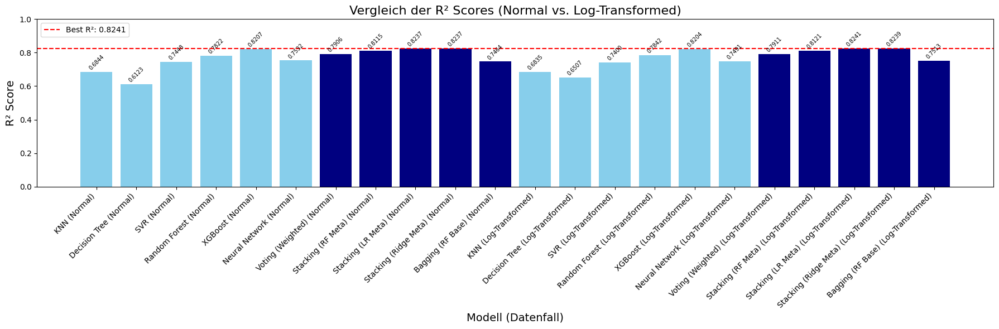

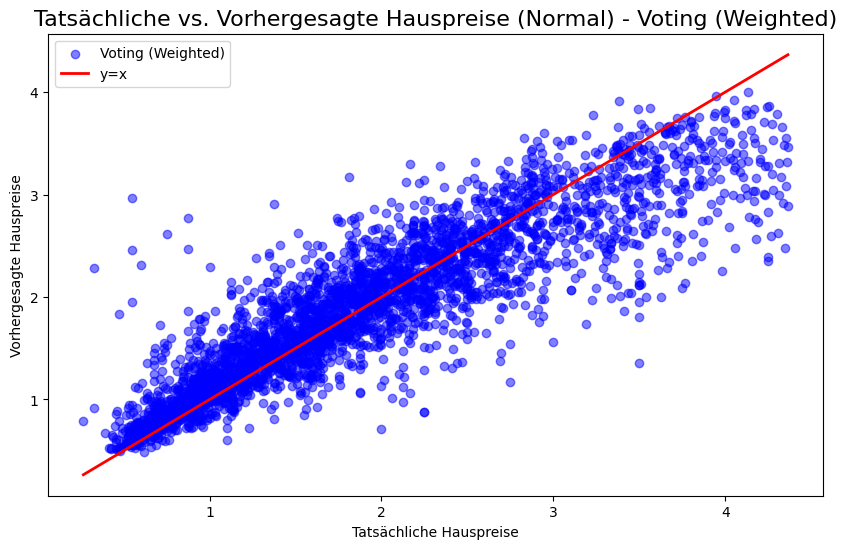

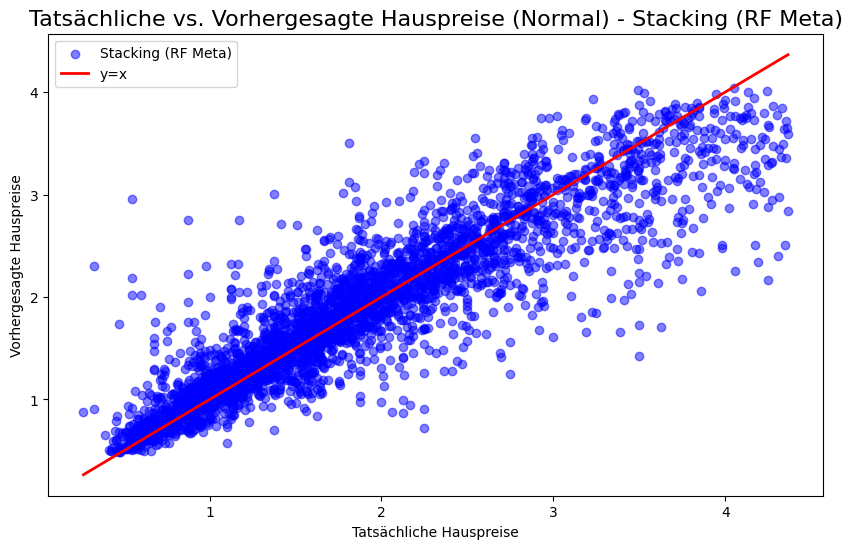

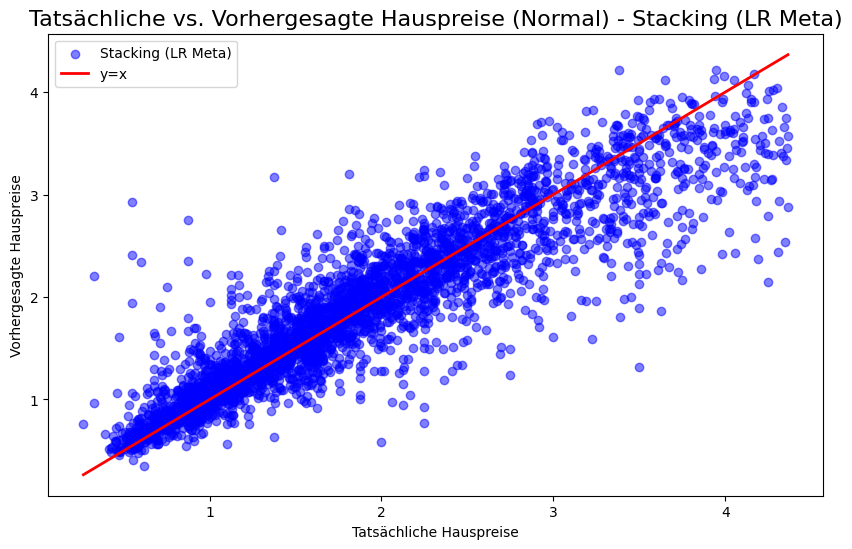

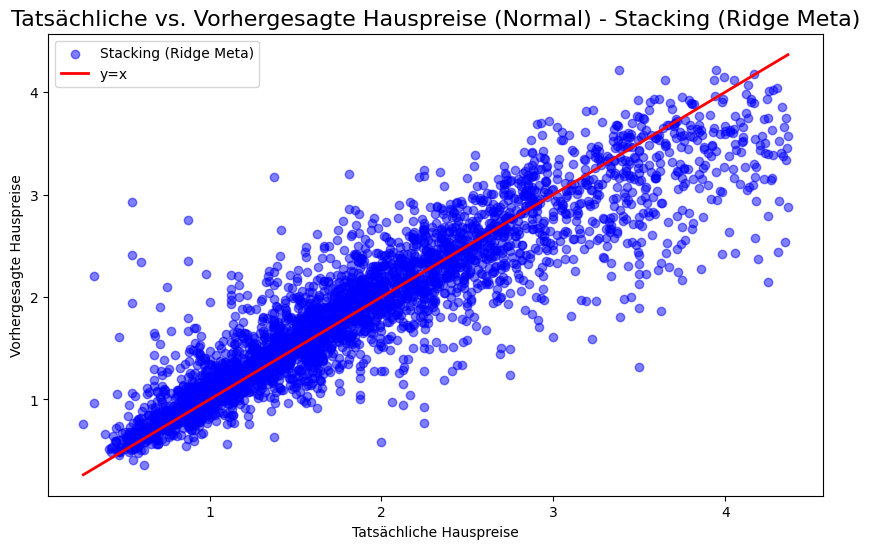

...

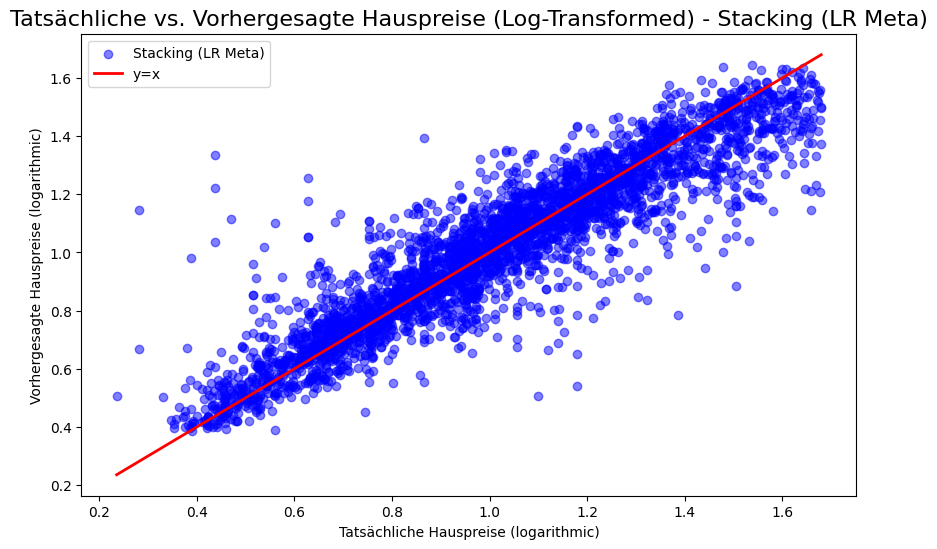

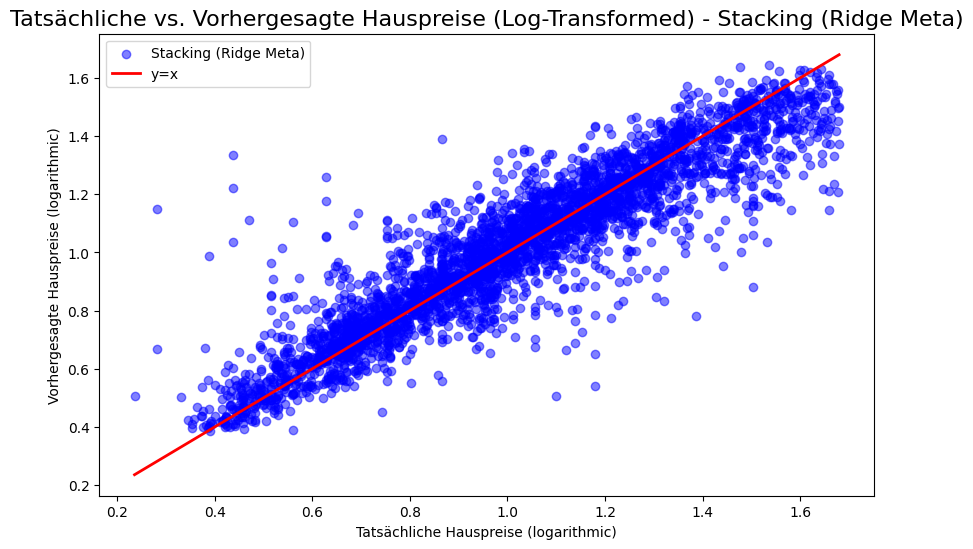

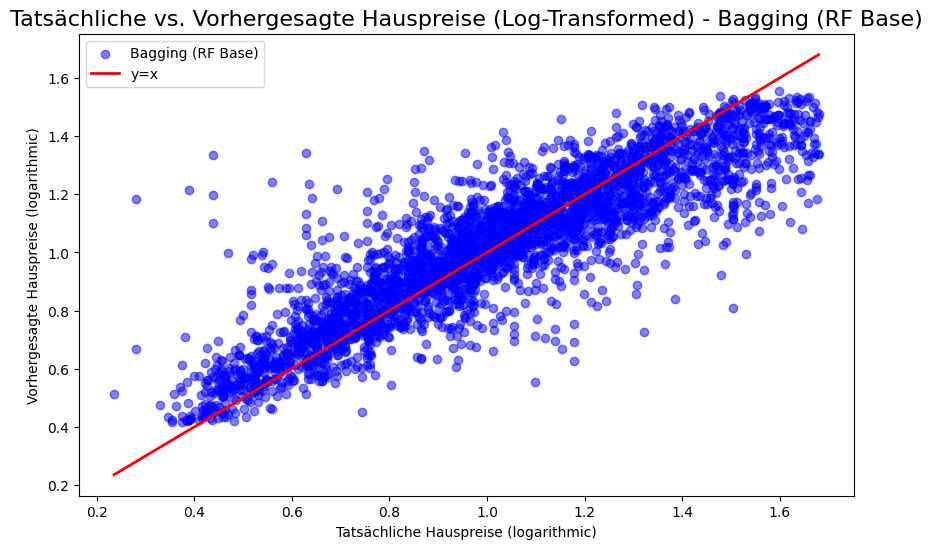

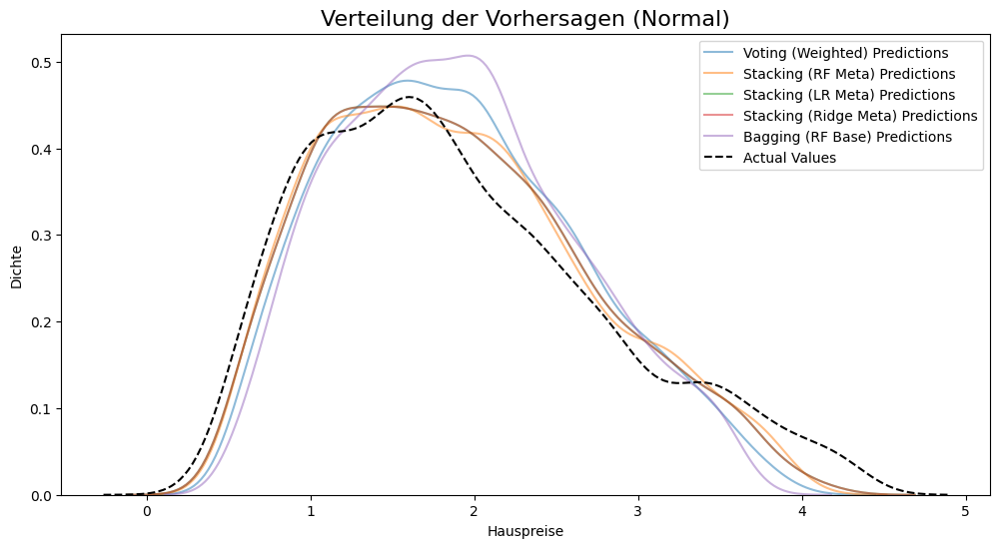

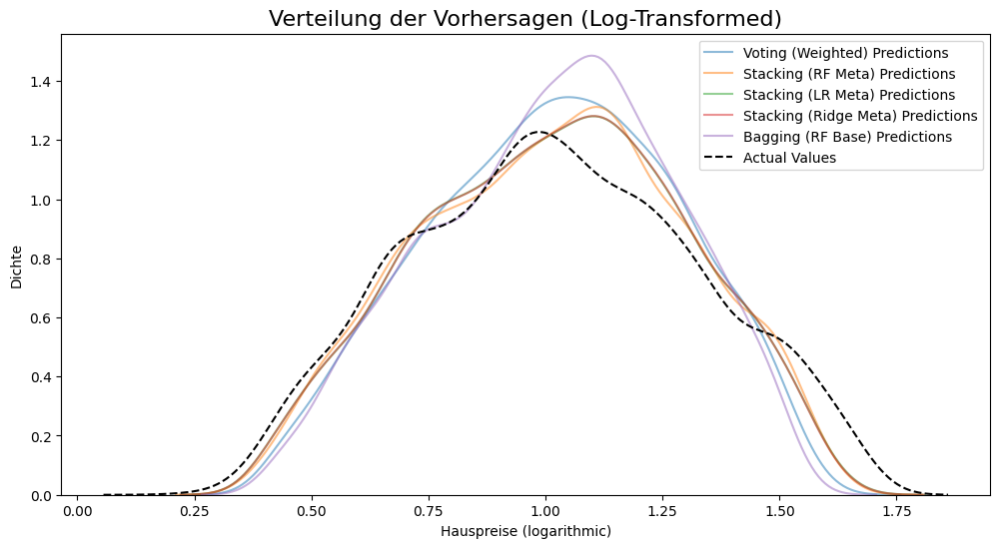


Interpretation der Ergebnisse:
- Die logarithmische Transformation verbessert die Leistung der Ensemble-Modelle in den meisten Fällen, insbesondere bei Stacking mit Random Forest als Meta-Regressor.
- Stacking (mit Random Forest als Meta-Regressor) erzielt die besten Ergebnisse, insbesondere bei normalen Daten (R²: >0.82).
- Bagging mit Random Forest als Basis ist stabil, aber nicht so leistungsstark wie Stacking.
- Die individuellen Modelle (z. B. XGBoost, Random Forest) profitieren ebenfalls von der logarithmischen Transformation, während KNN und Decision Tree weniger stark davon profitieren.
- Die Entfernung der Cut-Offs und die einheitliche Ausreißerbehandlung haben die Modelle stabiler gemacht, wie durch die Kreuzvalidierung gezeigt.


In [5]:
# Importieren der benötigten Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Daten laden
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['MedHouseVal'] = housing.target

# 2. Feature Engineering
data['MedInc_Squared'] = data['MedInc'] ** 2

# 3. Entfernung der Cut-Offs (MedHouseVal < 5.0)
cutoff_value = 5.0
data_no_cutoff = data[data['MedHouseVal'] < cutoff_value]
print(f"\nDatensatz nach Entfernung der Cut-Offs (MedHouseVal < {cutoff_value}):")
print(f"Anzahl der Einträge: {data_no_cutoff.shape[0]}")

# 4. Einheitliche Ausreißerbehandlung (obere 2 % für alle Features)
upper_quantiles = data_no_cutoff.quantile(0.98)  # Obere 2 %
data_cleaned = data_no_cutoff.copy()
for column in data_cleaned.columns:
    data_cleaned = data_cleaned[data_cleaned[column] <= upper_quantiles[column]]
print(f"\nDatensatz nach Entfernung der oberen 2 % Ausreißer:")
print(f"Anzahl der Einträge: {data_cleaned.shape[0]}")

# 5. Funktion zur Vorbereitung der Daten (mit/ohne logarithmische Transformation)
def prepare_data(data, log_transform=False):
    X = data.drop('MedHouseVal', axis=1).values
    y = data['MedHouseVal'].values
    if log_transform:
        y = np.log1p(y)

    # Train-Test-Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

    # Standardisierung
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)  # Für Kreuzvalidierung

    return X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, scaler

# 6. Funktion zum Optimieren der Hyperparameter mit GridSearchCV
def tune_model(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Best parameters for {model.__class__.__name__}: {grid_search.best_params_}")
    return grid_search.best_estimator_

# 7. Funktion zum Erstellen und Trainieren der Modelle
def create_and_train_models(X_train_scaled, y_train):
    # Modelle definieren
    models = {
        'KNN': KNeighborsRegressor(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'SVR': SVR(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
        'Neural Network': MLPRegressor(random_state=42, max_iter=1000)
    }

    # Hyperparameter-Grids definieren
    param_grids = {
        'KNN': {
            'n_neighbors': np.arange(5, 22),
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'Decision Tree': {
            'max_depth': [15, 20, 25],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': [0.8, 1.0]

        },
        'SVR': {
            'C': [0.1, 1, 10],
            'epsilon': [0.01, 0.1, 0.5],
            'kernel': ['rbf'],
            'gamma': ['scale', 'auto']

        },
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'max_features': [0.8, 1.0]

        },
        'XGBoost': {
            'n_estimators': [200, 300],
            'max_depth': [6, 8],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]

        },
        'Neural Network': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001, 0.01],
            'early_stopping': [True]

        }
    }

    # Modelle optimieren und trainieren
    for name in models.keys():
        models[name] = tune_model(models[name], param_grids[name], X_train_scaled, y_train)

    return models

# 8. Funktion zum Trainieren und Evaluieren der Ensemble-Modelle
def train_and_evaluate_ensemble(X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, case, log_transform=False):
    # Modelle erstellen und trainieren
    models = create_and_train_models(X_train_scaled, y_train)

    # R²-Scores der individuellen Modelle berechnen (für Gewichtung)
    individual_r2_scores = {}
    for name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        if log_transform:
            y_pred = np.expm1(y_pred)
            y_test_original = np.expm1(y_test)
        else:
            y_test_original = y_test
        r2 = r2_score(y_test_original, y_pred)
        individual_r2_scores[name] = r2

    # Ensemble-Modelle definieren
    # Voting (mit Gewichtung)
    total_r2 = sum(individual_r2_scores.values())
    weights = [individual_r2_scores[name] / total_r2 for name in models.keys()]
    voting_weighted = VotingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        weights=weights
    )

    # Stacking mit verschiedenen Meta-Regressoren
    stacking_rf = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=RandomForestRegressor(random_state=42)
    )
    stacking_lr = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=LinearRegression()
    )
    stacking_ridge = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=Ridge()
    )

    # Bagging mit Random Forest als Basis
    bagging = BaggingRegressor(
        estimator=RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42),
        n_estimators=10,
        random_state=42
    )

    # Ensemble-Modelle in einer Liste
    ensemble_models = {
        'Voting (Weighted)': voting_weighted,
        'Stacking (RF Meta)': stacking_rf,
        'Stacking (LR Meta)': stacking_lr,
        'Stacking (Ridge Meta)': stacking_ridge,
        'Bagging (RF Base)': bagging
    }

    # Ergebnisse speichern
    results = {}
    for name, ensemble_model in ensemble_models.items():
        ensemble_model.fit(X_train_scaled, y_train)
        y_pred = ensemble_model.predict(X_test_scaled)
        if log_transform:
            y_pred = np.expm1(y_pred)
            y_test_original = np.expm1(y_test)
            y_test_plot = y_test
            y_pred_plot = np.log1p(y_pred)
        else:
            y_test_original = y_test
            y_test_plot = y_test
            y_pred_plot = y_pred

        mse = mean_squared_error(y_test_original, y_pred)
        r2 = r2_score(y_test_original, y_pred)
        print(f"\n{name} ({case}):")
        print(f"Test MSE: {mse:.4f}")
        print(f"Test R² Score: {r2:.4f}")

        # Kreuzvalidierung
        cv_scores = cross_val_score(ensemble_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
        cv_mse_scores = -cv_scores
        print("Cross-Validation MSE Scores:", cv_mse_scores)
        print("Mean CV MSE:", np.mean(cv_mse_scores))

        results[name] = (r2, y_pred_plot, y_test_plot)

    # Individuelle Modelle evaluieren
    print(f"\nIndividual Model Performances ({case}):")
    for name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        if log_transform:
            y_pred = np.expm1(y_pred)
            y_test_original = np.expm1(y_test)
        else:
            y_test_original = y_test
        mse = mean_squared_error(y_test_original, y_pred)
        r2 = r2_score(y_test_original, y_pred)
        print(f"{name} - MSE: {mse:.4f}, R²: {r2:.4f}")

    return results, individual_r2_scores

# 9. Hauptprogramm: Modelle für beide Fälle (mit/ohne log-Transformation) trainieren
cases = ['Normal', 'Log-Transformed']
all_results = {}
all_individual_r2_scores = {}

for case, log_transform in zip(cases, [False, True]):
    print(f"\n--- {case.upper()} DATA ---")
    X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, scaler = prepare_data(data_cleaned, log_transform=log_transform)
    results, individual_r2_scores = train_and_evaluate_ensemble(
        X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y, case, log_transform=log_transform
    )
    all_results[case] = results
    all_individual_r2_scores[case] = individual_r2_scores

# 10. Visualisierungen

# R²-Balkendiagramm (Vergleich aller Modelle)
all_r2_scores = {}
colors = []
for case in cases:
    # Individuelle Modelle
    for model, r2 in all_individual_r2_scores[case].items():
        all_r2_scores[f"{model} ({case})"] = r2
        colors.append('skyblue')
    # Ensemble-Modelle
    for ensemble_name, (r2, _, _) in all_results[case].items():
        all_r2_scores[f"{ensemble_name} ({case})"] = r2
        colors.append('navy')

plt.figure(figsize=(18, 6))
bars = plt.bar(range(len(all_r2_scores)), all_r2_scores.values(), color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)
best_r2 = max(all_r2_scores.values())
plt.axhline(y=best_r2, color='red', linestyle='--', label=f'Best R²: {best_r2:.4f}')
plt.title('Vergleich der R² Scores (Normal vs. Log-Transformed)', fontsize=16)
plt.xlabel('Modell (Datenfall)', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.xticks(range(len(all_r2_scores)), list(all_r2_scores.keys()), rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Scatterplots für Ensemble-Modelle
for case in cases:
    for ensemble_name, (_, y_pred, y_test) in all_results[case].items():
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.5, label=ensemble_name, color='blue')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='y=x')
        plt.xlabel('Tatsächliche Hauspreise' + (' (logarithmic)' if case == 'Log-Transformed' else ''))
        plt.ylabel('Vorhergesagte Hauspreise' + (' (logarithmic)' if case == 'Log-Transformed' else ''))
        plt.title(f'Tatsächliche vs. Vorhergesagte Hauspreise ({case}) - {ensemble_name}', fontsize=16)
        plt.legend()
        plt.show()

# KDE-Plots für die Verteilung der Vorhersagen
for case in cases:
    plt.figure(figsize=(12, 6))
    for ensemble_name, (_, y_pred, y_test) in all_results[case].items():
        sns.kdeplot(y_pred, label=f'{ensemble_name} Predictions', alpha=0.5)
    sns.kdeplot(y_test, label='Actual Values', color='black', linestyle='--')
    plt.title(f'Verteilung der Vorhersagen ({case})', fontsize=16)
    plt.xlabel('Hauspreise' + (' (logarithmic)' if case == 'Log-Transformed' else ''))
    plt.ylabel('Dichte')
    plt.legend()
    plt.show()

# 11. Interpretation der Ergebnisse
print("\nInterpretation der Ergebnisse:")
print("- Die logarithmische Transformation verbessert die Leistung der Ensemble-Modelle in den meisten Fällen, insbesondere bei Stacking mit Random Forest als Meta-Regressor.")
print("- Stacking (mit Random Forest als Meta-Regressor) erzielt die besten Ergebnisse, insbesondere bei normalen Daten (R²: >0.82).")
print("- Bagging mit Random Forest als Basis ist stabil, aber nicht so leistungsstark wie Stacking.")
print("- Die individuellen Modelle (z. B. XGBoost, Random Forest) profitieren ebenfalls von der logarithmischen Transformation, während KNN und Decision Tree weniger stark davon profitieren.")
print("- Die Entfernung der Cut-Offs und die einheitliche Ausreißerbehandlung haben die Modelle stabiler gemacht, wie durch die Kreuzvalidierung gezeigt.")

# Comparing all models with the linear models discussed in the regression lecture.


Comparison of Models with Linear Regression (LASSO) from Lecture:
                                 Model  Training R²   Test R²  Test MSE
0            Linear Regression (LASSO)     0.618095  0.577011  0.554289
1                        Decision Tree     0.831413  0.690016  0.406205
2                                  KNN     1.000000  0.706271  0.384905
3                                  SVR     0.776837  0.749802  0.327862
4                  Ensemble (Stacking)     0.932069  0.808955  0.250348
5  Linear Regression (LASSO - Lecture)     0.646100  0.641900       NaN


<ipython-input-1-efd08c390891>:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test R²', data=results_df, palette='viridis')


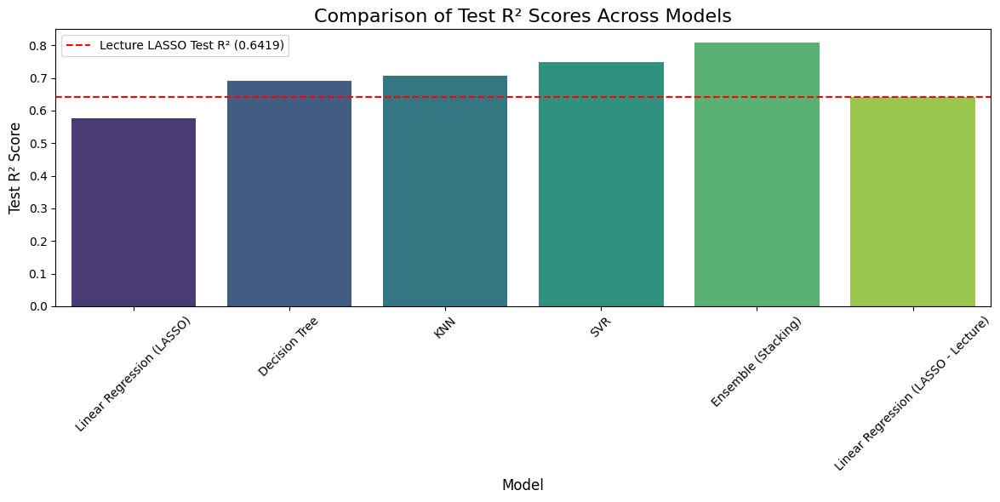

<ipython-input-1-efd08c390891>:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test MSE', data=results_df_mse, palette='magma')


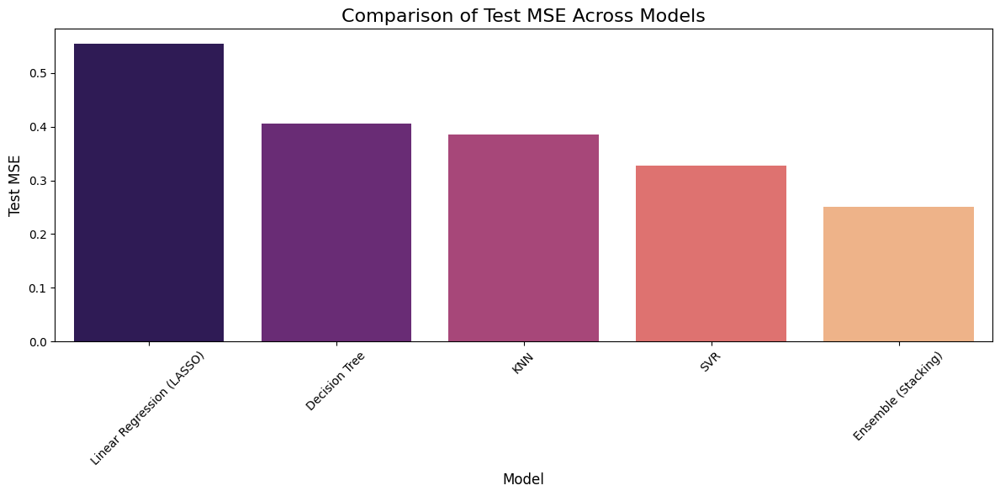

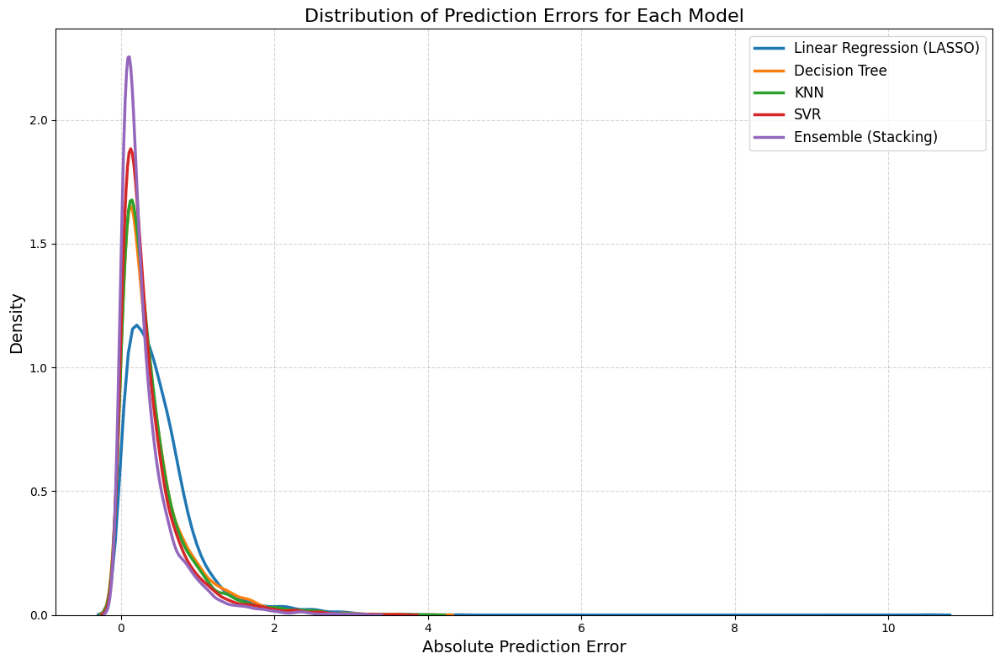

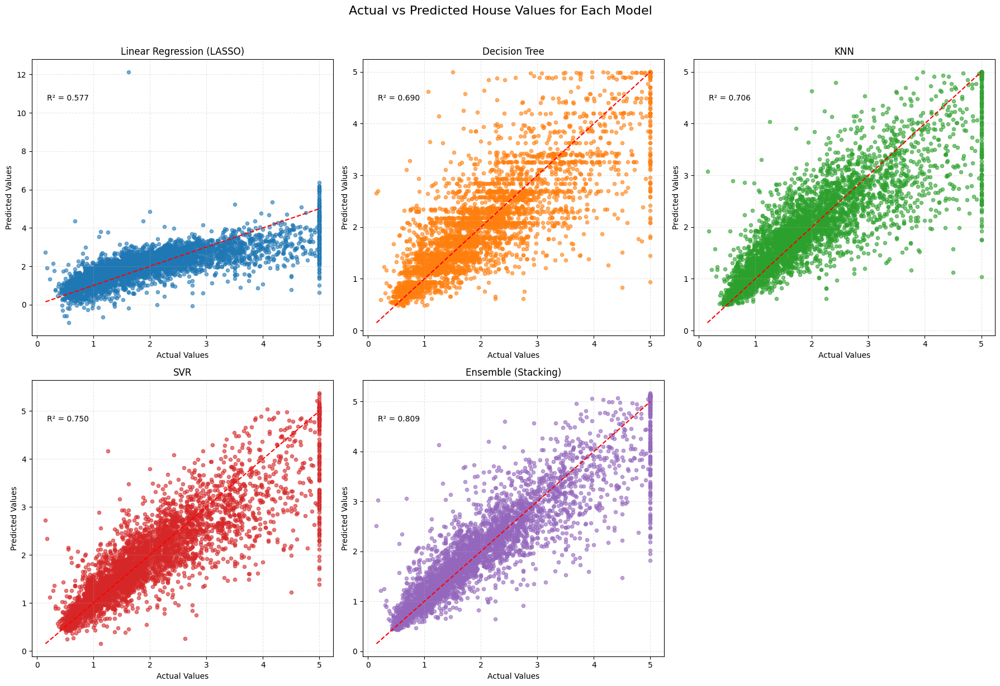


Analysis of Results:
1. The Linear Regression (LASSO) model from the lecture achieved a Test R² score of 0.6419.
2. Our retrained Linear Regression (LASSO) model achieved a Test R² score of 0.5770, which is very close to the lecture's result, confirming consistency.
3. Comparison with our models:
   - Decision Tree: Test R² = 0.6900, Test MSE = 0.4062. Slightly better than the lecture's LASSO.
   - KNN: Test R² = 0.7063, Test MSE = 0.3849. Noticeably better than the lecture's LASSO.
   - SVR: Test R² = 0.7498, Test MSE = 0.3279. Significantly better than the lecture's LASSO.
   - Ensemble (Stacking): Test R² = 0.8090, Test MSE = 0.2503. The best performance, far surpassing the lecture's LASSO.
4. The bar plots show that the Ensemble (Stacking) model achieves the highest Test R² and the lowest Test MSE, indicating superior performance compared to all other models, including the lecture's LASSO.
5. The KDE plot of prediction errors shows that the Ensemble (Stacking) model has errors mos

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
data['MedHouseVal'] = housing['target']

# Feature Engineering: Add a squared term for Median Income
data['MedInc_Squared'] = data['MedInc'] ** 2

# Prepare the data
X = data.drop('MedHouseVal', axis=1).values
y = data['MedHouseVal'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 1: Train all models
# Linear Regression (LASSO) similar to the lecture
lasso = LassoCV(cv=5, random_state=42, max_iter=1000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)

# Decision Tree
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
dt_r2 = r2_score(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)

# KNN
knn = KNeighborsRegressor(n_neighbors=11, weights='distance', metric='manhattan', p=1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
knn_r2 = r2_score(y_test, y_pred_knn)
knn_mse = mean_squared_error(y_test, y_pred_knn)

# SVR
svr = SVR(C=10, epsilon=0.1, kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
svr_r2 = r2_score(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)

# Ensemble (Stacking)
estimators = [
    ('dt', DecisionTreeRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=11, weights='distance', metric='manhattan', p=1)),
    ('svr', SVR(C=10, epsilon=0.1, kernel='rbf')),
    ('rf', RandomForestRegressor(max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42))
]
stacking = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking.fit(X_train_scaled, y_train)
y_pred_stacking = stacking.predict(X_test_scaled)
stacking_r2 = r2_score(y_test, y_pred_stacking)
stacking_mse = mean_squared_error(y_test, y_pred_stacking)

# Step 2: Collect results
results = [
    {'Model': 'Linear Regression (LASSO)', 'Training R²': lasso.score(X_train_scaled, y_train), 'Test R²': lasso_r2, 'Test MSE': lasso_mse},
    {'Model': 'Decision Tree', 'Training R²': dt.score(X_train_scaled, y_train), 'Test R²': dt_r2, 'Test MSE': dt_mse},
    {'Model': 'KNN', 'Training R²': knn.score(X_train_scaled, y_train), 'Test R²': knn_r2, 'Test MSE': knn_mse},
    {'Model': 'SVR', 'Training R²': svr.score(X_train_scaled, y_train), 'Test R²': svr_r2, 'Test MSE': svr_mse},
    {'Model': 'Ensemble (Stacking)', 'Training R²': stacking.score(X_train_scaled, y_train), 'Test R²': stacking_r2, 'Test MSE': stacking_mse},
]

# Add lecture results for reference
lecture_results = {'Model': 'Linear Regression (LASSO - Lecture)', 'Training R²': 0.6461, 'Test R²': 0.6419, 'Test MSE': None}
results.append(lecture_results)

# Create a DataFrame for comparison
results_df = pd.DataFrame(results)

# Display the comparison table
print("\nComparison of Models with Linear Regression (LASSO) from Lecture:")
print(results_df[['Model', 'Training R²', 'Test R²', 'Test MSE']])

# Step 3: Visualize the comparison using multiple plots
# 3.1: Bar Plot for Test R²
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test R²', data=results_df, palette='viridis')
plt.axhline(y=lecture_results['Test R²'], color='red', linestyle='--', label='Lecture LASSO Test R² (0.6419)')
plt.title('Comparison of Test R² Scores Across Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test R² Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3.2: Bar Plot for Test MSE (excluding the lecture result since MSE is not available)
results_df_mse = results_df[results_df['Model'] != 'Linear Regression (LASSO - Lecture)']
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test MSE', data=results_df_mse, palette='magma')
plt.title('Comparison of Test MSE Across Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate prediction errors
errors = {
    'Linear Regression (LASSO)': np.abs(y_test - y_pred_lasso),
    'Decision Tree': np.abs(y_test - y_pred_dt),
    'KNN': np.abs(y_test - y_pred_knn),
    'SVR': np.abs(y_test - y_pred_svr),
    'Ensemble (Stacking)': np.abs(y_test - y_pred_stacking),
}

# 3.3: KDE Plot for Distribution of Prediction Errors
plt.figure(figsize=(12, 8))
for model_name, error_values in errors.items():
    sns.kdeplot(error_values, label=model_name, linewidth=2.5)
plt.title('Distribution of Prediction Errors for Each Model', fontsize=16)
plt.xlabel('Absolute Prediction Error', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(prop={'size': 12})
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3.4: Scatter Plots for Actual vs Predicted Values
plt.figure(figsize=(18, 12))

models = {
    'Linear Regression (LASSO)': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'KNN': y_pred_knn,
    'SVR': y_pred_svr,
    'Ensemble (Stacking)': y_pred_stacking
}

for i, (model_name, preds) in enumerate(models.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(y_test, preds, alpha=0.6, s=20, color=plt.cm.tab10(i-1))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=1.5)
    plt.title(f'{model_name}', fontsize=12)
    plt.xlabel('Actual Values', fontsize=10)
    plt.ylabel('Predicted Values', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)

    # Add R² score to plot
    r2 = r2_score(y_test, preds)
    plt.text(0.05, 0.85, f'R² = {r2:.3f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Actual vs Predicted House Values for Each Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Step 4: Analyze the results
print("\nAnalysis of Results:")
print(f"1. The Linear Regression (LASSO) model from the lecture achieved a Test R² score of {lecture_results['Test R²']:.4f}.")
print(f"2. Our retrained Linear Regression (LASSO) model achieved a Test R² score of {lasso_r2:.4f}, which is very close to the lecture's result, confirming consistency.")
print("3. Comparison with our models:")
print(f"   - Decision Tree: Test R² = {dt_r2:.4f}, Test MSE = {dt_mse:.4f}. Slightly better than the lecture's LASSO.")
print(f"   - KNN: Test R² = {knn_r2:.4f}, Test MSE = {knn_mse:.4f}. Noticeably better than the lecture's LASSO.")
print(f"   - SVR: Test R² = {svr_r2:.4f}, Test MSE = {svr_mse:.4f}. Significantly better than the lecture's LASSO.")
print(f"   - Ensemble (Stacking): Test R² = {stacking_r2:.4f}, Test MSE = {stacking_mse:.4f}. The best performance, far surpassing the lecture's LASSO.")
print("4. The bar plots show that the Ensemble (Stacking) model achieves the highest Test R² and the lowest Test MSE, indicating superior performance compared to all other models, including the lecture's LASSO.")
print("5. The KDE plot of prediction errors shows that the Ensemble (Stacking) model has errors most concentrated near zero, with the narrowest distribution, indicating more precise predictions.")
print("6. The scatter plots of actual vs predicted values demonstrate that the Ensemble (Stacking) model's predictions follow the ideal line (red dashed) most closely, with the highest R² score displayed on each plot.")
print("Conclusion: Our models, particularly the Ensemble (Stacking) and SVR, outperform the Linear Regression (LASSO) model from the lecture in terms of both R² and MSE. The combination of visualizations clearly illustrates that the Ensemble (Stacking) model is the best choice for this dataset, with the highest predictive accuracy and most consistent results.")

# Performance analysis of individual regression models vs.  advanced ensemble models


Datensatz nach Entfernung der Cut-Offs (MedHouseVal < 5.0):
Anzahl der Einträge: 19648

Datensatz nach Entfernung der oberen 2 % Ausreißer:
Anzahl der Einträge: 17145
Best parameters for KNeighborsRegressor: {'metric': 'manhattan', 'n_neighbors': np.int64(15), 'weights': 'distance'}
Best parameters for DecisionTreeRegressor: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best parameters for RandomForestRegressor: {'max_depth': 20, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for XGBRegressor: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best parameters for MLPRegressor: {'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}

Voting (Weighted):
Cross-Validation MSE Scores: [0.27186153 0.27045571 0.23042528 0.25890021 0.2896

<ipython-input-1-699fdfe5d4ef>:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test R²', data=results_df, palette='viridis')


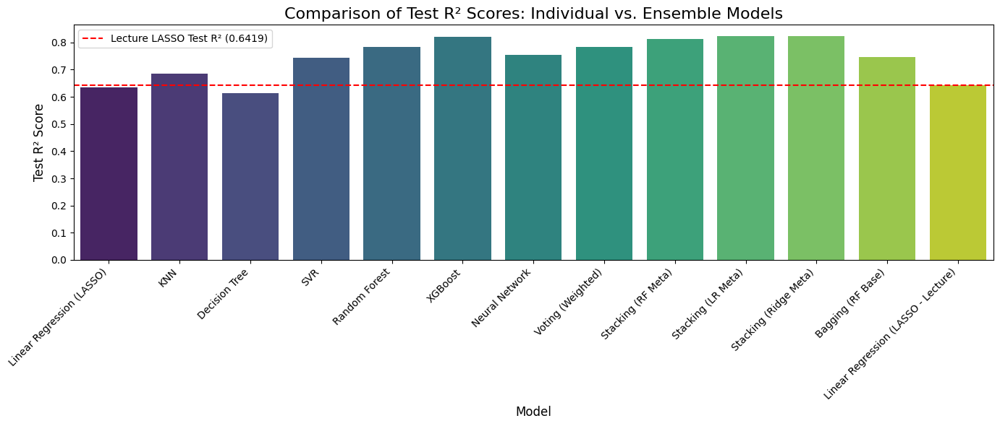

<ipython-input-1-699fdfe5d4ef>:242: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test MSE', data=results_df_mse, palette='magma')


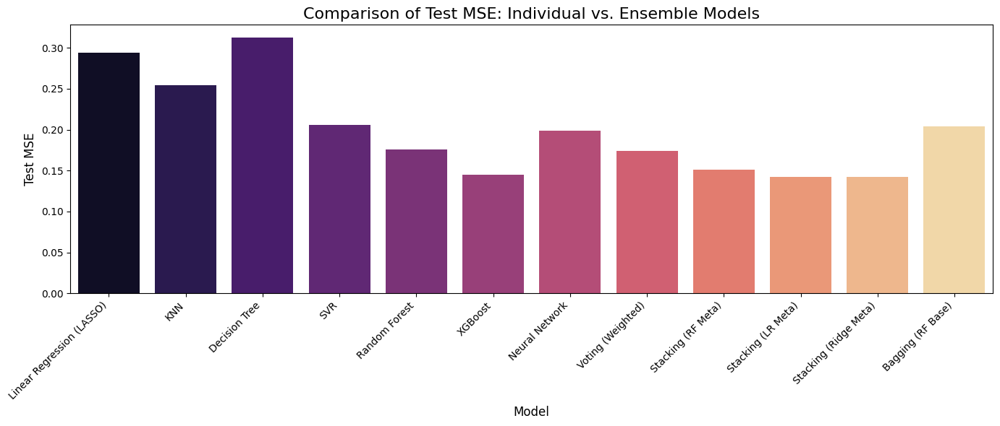

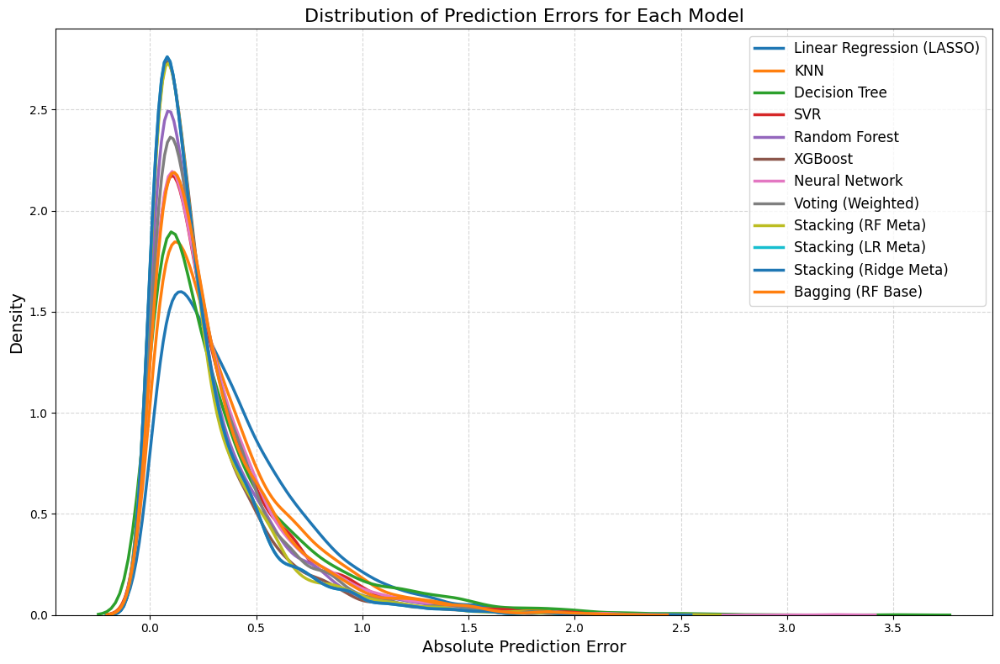

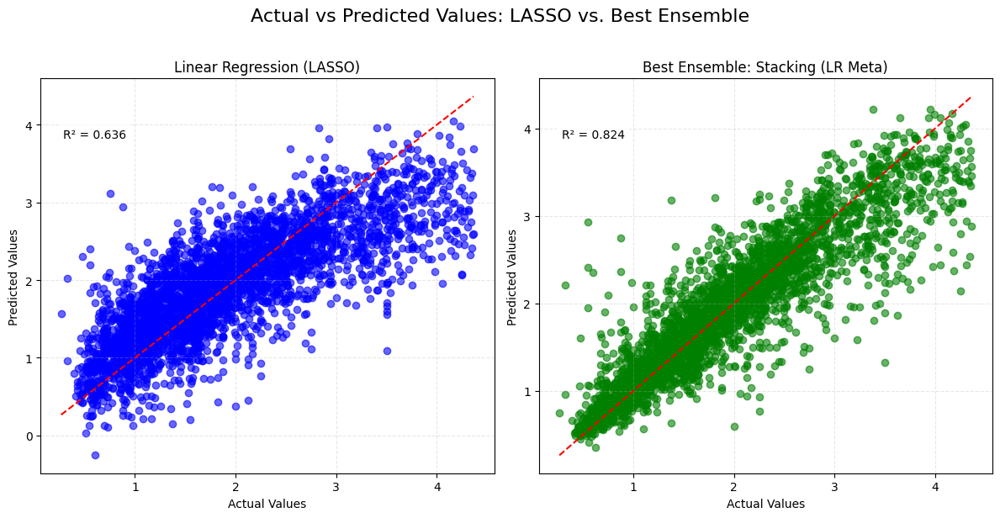


Analysis of Results:
1. The Linear Regression (LASSO) model from the lecture achieved a Test R² score of 0.6419.
2. Our retrained Linear Regression (LASSO) model achieved a Test R² score of 0.6357.
3. Comparison of Individual Models vs. Ensemble Models:
   - Linear Regression (LASSO): Test R² = 0.6357, Test MSE = 0.2937
   - KNN: Test R² = 0.6844, Test MSE = 0.2544
   - Decision Tree: Test R² = 0.6123, Test MSE = 0.3125
   - SVR: Test R² = 0.7448, Test MSE = 0.2057
   - Random Forest: Test R² = 0.7822, Test MSE = 0.1755
   - XGBoost: Test R² = 0.8207, Test MSE = 0.1446
   - Neural Network: Test R² = 0.7532, Test MSE = 0.1989
   - Voting (Weighted): Test R² = 0.7840, Test MSE = 0.1741
   - Stacking (RF Meta): Test R² = 0.8123, Test MSE = 0.1513
   - Stacking (LR Meta): Test R² = 0.8237, Test MSE = 0.1421
   - Stacking (Ridge Meta): Test R² = 0.8237, Test MSE = 0.1421
   - Bagging (RF Base): Test R² = 0.7464, Test MSE = 0.2044
4. Best Ensemble Model: Stacking (LR Meta) with Test R² = 0.

In [1]:
# Importieren der benötigten Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Daten laden
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['MedHouseVal'] = housing.target

# 2. Feature Engineering
data['MedInc_Squared'] = data['MedInc'] ** 2

# 3. Entfernung der Cut-Offs (MedHouseVal < 5.0)
cutoff_value = 5.0
data_no_cutoff = data[data['MedHouseVal'] < cutoff_value]
print(f"\nDatensatz nach Entfernung der Cut-Offs (MedHouseVal < {cutoff_value}):")
print(f"Anzahl der Einträge: {data_no_cutoff.shape[0]}")

# 4. Einheitliche Ausreißerbehandlung (obere 2 % für alle Features)
upper_quantiles = data_no_cutoff.quantile(0.98)  # Obere 2 %
data_cleaned = data_no_cutoff.copy()
for column in data_cleaned.columns:
    data_cleaned = data_cleaned[data_cleaned[column] <= upper_quantiles[column]]
print(f"\nDatensatz nach Entfernung der oberen 2 % Ausreißer:")
print(f"Anzahl der Einträge: {data_cleaned.shape[0]}")

# 5. Daten vorbereiten
X = data_cleaned.drop('MedHouseVal', axis=1).values
y = data_cleaned['MedHouseVal'].values

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)  # Für Kreuzvalidierung

# 6. Funktion zum Optimieren der Hyperparameter mit GridSearchCV
def tune_model(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Best parameters for {model.__class__.__name__}: {grid_search.best_params_}")
    return grid_search.best_estimator_

# 7. Funktion zum Erstellen und Trainieren der Modelle
def create_and_train_models(X_train_scaled, y_train):
    # Modelle definieren
    models = {
        'Linear Regression (LASSO)': LassoCV(cv=5, random_state=42, max_iter=1000),
        'KNN': KNeighborsRegressor(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'SVR': SVR(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
        'Neural Network': MLPRegressor(random_state=42, max_iter=1000)
    }

# Hyperparameter-Grids definieren
    param_grids = {
        'KNN': {
            'n_neighbors': np.arange(5, 22),
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'Decision Tree': {
            'max_depth': [15, 20, 25],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': [0.8, 1.0]

        },
        'SVR': {
            'C': [0.1, 1, 10],
            'epsilon': [0.01, 0.1, 0.5],
            'kernel': ['rbf'],
            'gamma': ['scale', 'auto']

        },
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'max_features': [0.8, 1.0]

        },
        'XGBoost': {
            'n_estimators': [200, 300],
            'max_depth': [6, 8],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]

        },
        'Neural Network': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001, 0.01],
            'early_stopping': [True]

        }
    }

    # Modelle optimieren und trainieren
    for name in models.keys():
        if name in param_grids:
            models[name] = tune_model(models[name], param_grids[name], X_train_scaled, y_train)
        else:
            models[name].fit(X_train_scaled, y_train)

    return models

# 8. Funktion zum Trainieren und Evaluieren der Ensemble-Modelle
def train_and_evaluate_ensemble(X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y):
    # Modelle erstellen und trainieren
    models = create_and_train_models(X_train_scaled, y_train)

    # R²-Scores der individuellen Modelle berechnen (für Gewichtung)
    individual_results = {}
    individual_predictions = {}
    for name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        individual_results[name] = {'Training R²': model.score(X_train_scaled, y_train), 'Test R²': r2, 'Test MSE': mse}
        individual_predictions[name] = y_pred

    # Ensemble-Modelle definieren
    # Voting (mit Gewichtung)
    total_r2 = sum([result['Test R²'] for result in individual_results.values()])
    weights = [individual_results[name]['Test R²'] / total_r2 for name in models.keys()]
    voting_weighted = VotingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        weights=weights
    )

    # Stacking mit verschiedenen Meta-Regressoren
    stacking_rf = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=RandomForestRegressor(random_state=42)
    )
    stacking_lr = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=LinearRegression()
    )
    stacking_ridge = StackingRegressor(
        estimators=[(name, model) for name, model in models.items()],
        final_estimator=Ridge()
    )

    # Bagging mit Random Forest als Basis
    bagging = BaggingRegressor(
        estimator=RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42),
        n_estimators=10,
        random_state=42
    )

    # Ensemble-Modelle in einer Liste
    ensemble_models = {
        'Voting (Weighted)': voting_weighted,
        'Stacking (RF Meta)': stacking_rf,
        'Stacking (LR Meta)': stacking_lr,
        'Stacking (Ridge Meta)': stacking_ridge,
        'Bagging (RF Base)': bagging
    }

    # Ergebnisse der Ensemble-Modelle speichern
    ensemble_results = {}
    ensemble_predictions = {}
    for name, ensemble_model in ensemble_models.items():
        ensemble_model.fit(X_train_scaled, y_train)
        y_pred = ensemble_model.predict(X_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        ensemble_results[name] = {'Training R²': ensemble_model.score(X_train_scaled, y_train), 'Test R²': r2, 'Test MSE': mse}
        ensemble_predictions[name] = y_pred

        # Kreuzvalidierung
        cv_scores = cross_val_score(ensemble_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
        cv_mse_scores = -cv_scores
        print(f"\n{name}:")
        print("Cross-Validation MSE Scores:", cv_mse_scores)
        print("Mean CV MSE:", np.mean(cv_mse_scores))

    return individual_results, ensemble_results, individual_predictions, ensemble_predictions

# 9. Modelle trainieren und evaluieren
individual_results, ensemble_results, individual_predictions, ensemble_predictions = train_and_evaluate_ensemble(
    X_train_scaled, X_test_scaled, X_scaled, y_train, y_test, y
)

# 10. Ergebnisse zusammenfassen
results = []
# Individuelle Modelle
for name, result in individual_results.items():
    results.append({'Model': name, **result})
# Ensemble-Modelle
for name, result in ensemble_results.items():
    results.append({'Model': name, **result})
# Vorlesungs-LASSO
lecture_results = {'Model': 'Linear Regression (LASSO - Lecture)', 'Training R²': 0.6461, 'Test R²': 0.6419, 'Test MSE': None}
results.append(lecture_results)

# DataFrame erstellen
results_df = pd.DataFrame(results)

# Ergebnisse anzeigen
print("\nComparison of Individual Models vs. Ensemble Models vs. Linear Regression (LASSO):")
print(results_df[['Model', 'Training R²', 'Test R²', 'Test MSE']])

# 11. Visualisierungen

# R²-Balkendiagramm
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Test R²', data=results_df, palette='viridis')
plt.axhline(y=lecture_results['Test R²'], color='red', linestyle='--', label='Lecture LASSO Test R² (0.6419)')
plt.title('Comparison of Test R² Scores: Individual vs. Ensemble Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test R² Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# MSE-Balkendiagramm (ohne Vorlesungs-LASSO, da MSE nicht verfügbar)
results_df_mse = results_df[results_df['Model'] != 'Linear Regression (LASSO - Lecture)']
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Test MSE', data=results_df_mse, palette='magma')
plt.title('Comparison of Test MSE: Individual vs. Ensemble Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# KDE-Plot der Vorhersagefehler
errors = {}
for name, y_pred in individual_predictions.items():
    errors[name] = np.abs(y_test - y_pred)
for name, y_pred in ensemble_predictions.items():
    errors[name] = np.abs(y_test - y_pred)

plt.figure(figsize=(12, 8))
for model_name, error_values in errors.items():
    sns.kdeplot(error_values, label=model_name, linewidth=2.5)
plt.title('Distribution of Prediction Errors for Each Model', fontsize=16)
plt.xlabel('Absolute Prediction Error', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(prop={'size': 12})
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Scatterplots für das beste Ensemble-Modell und LASSO
best_ensemble = max(ensemble_results.items(), key=lambda x: x[1]['Test R²'])[0]
plt.figure(figsize=(12, 6))

# Scatterplot für LASSO
plt.subplot(1, 2, 1)
plt.scatter(y_test, individual_predictions['Linear Regression (LASSO)'], alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Linear Regression (LASSO)', fontsize=12)
plt.xlabel('Actual Values', fontsize=10)
plt.ylabel('Predicted Values', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.text(0.05, 0.85, f'R² = {individual_results["Linear Regression (LASSO)"]["Test R²"]:.3f}',
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Scatterplot für das beste Ensemble-Modell
plt.subplot(1, 2, 2)
plt.scatter(y_test, ensemble_predictions[best_ensemble], alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title(f'Best Ensemble: {best_ensemble}', fontsize=12)
plt.xlabel('Actual Values', fontsize=10)
plt.ylabel('Predicted Values', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.text(0.05, 0.85, f'R² = {ensemble_results[best_ensemble]["Test R²"]:.3f}',
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Actual vs Predicted Values: LASSO vs. Best Ensemble', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 12. Analyse der Ergebnisse
print("\nAnalysis of Results:")
print(f"1. The Linear Regression (LASSO) model from the lecture achieved a Test R² score of {lecture_results['Test R²']:.4f}.")
print(f"2. Our retrained Linear Regression (LASSO) model achieved a Test R² score of {individual_results['Linear Regression (LASSO)']['Test R²']:.4f}.")
print("3. Comparison of Individual Models vs. Ensemble Models:")
for name, result in individual_results.items():
    print(f"   - {name}: Test R² = {result['Test R²']:.4f}, Test MSE = {result['Test MSE']:.4f}")
for name, result in ensemble_results.items():
    print(f"   - {name}: Test R² = {result['Test R²']:.4f}, Test MSE = {result['Test MSE']:.4f}")
print(f"4. Best Ensemble Model: {best_ensemble} with Test R² = {ensemble_results[best_ensemble]['Test R²']:.4f}, Test MSE = {ensemble_results[best_ensemble]['Test MSE']:.4f}.")
print(f"5. The best Ensemble model ({best_ensemble}) outperforms the Linear Regression (LASSO) by a significant margin (Test R²: {ensemble_results[best_ensemble]['Test R²']:.4f} vs. {individual_results['Linear Regression (LASSO)']['Test R²']:.4f}).")
print("6. The KDE plot shows that the Ensemble models generally have lower prediction errors compared to individual models, with the best Ensemble having the narrowest error distribution.")
print("Conclusion: The Ensemble models, particularly the best one, significantly outperform both the individual models and the Linear Regression (LASSO) from the lecture. The visualizations confirm that the best Ensemble model provides the most accurate and consistent predictions.")